In [ ]:
# @title R3-1 — Setup (libs, Drive, paths, config)

%pip -q install numpy pandas geopandas shapely rasterio rioxarray xarray tqdm pyyaml joblib

import os, re, glob, json, time, yaml, math, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio as rio

from tqdm.auto import tqdm
from joblib import Memory

# =========================================================
# DRIVE
# =========================================================
from google.colab import drive

try:
    drive.mount("/content/drive")
except Exception as e:
    print("Aviso ao montar Drive:", e)

# =========================================================
# PASTAS PRINCIPAIS
# =========================================================
BASE_DIR = Path(
    "/content/drive/MyDrive/Pantanal_TippingPoints/index"
)

OUT_DIR = BASE_DIR / "outputs"

# Resultados antigos — PRESERVADOS
LEGACY_REC_DIR = OUT_DIR / "recovery_nb3"
LEGACY_COMPARE_DIR = OUT_DIR / "compare_nb3"

# Resultados corrigidos — NOVOS
REC_DIR = OUT_DIR / "recovery_nb3_corrected"
COMPARE_DIR = OUT_DIR / "compare_nb3_corrected"

# Dados de entrada / caches válidos
MB30_DIR = Path(
    "/content/drive/MyDrive/"
    "Pantanal_TippingPoints_val_mb_bi_30m"
)

MB300_DIR = OUT_DIR / "mb_bi_300m_cache"

# VOD CORRIGIDO E VALIDADO
VOD_DIR = OUT_DIR / "vod_bi_300m_aligned_corrected"

# Novo cache óptico corrigido
# NÃO reutilizar o antigo porque ele contém -32768
OPT_SB_DIR = OUT_DIR / "opt_singleband_300m_cache_corrected"

# Outros diretórios
LOG_DIR = OUT_DIR / "logs"
QC_DIR = OUT_DIR / "qc"
TMP_DIR = OUT_DIR / "tmp_nb3_corrected"

for d in [
    REC_DIR,
    COMPARE_DIR,
    MB300_DIR,
    OPT_SB_DIR,
    LOG_DIR,
    QC_DIR,
    TMP_DIR
]:
    d.mkdir(parents=True, exist_ok=True)

# =========================================================
# CONFIG
# =========================================================
CONFIG_FP = BASE_DIR / "config.yaml"

assert CONFIG_FP.exists(), (
    f"config.yaml não encontrado em {CONFIG_FP}"
)

CONFIG = yaml.safe_load(
    open(CONFIG_FP)
)

CRS_EPSG = int(
    CONFIG.get("crs_epsg", 31983)
)

BOUNDARY_PATH = Path(
    CONFIG["boundary_path"]
)

assert BOUNDARY_PATH.exists()

# =========================================================
# ÓPTICOS
# =========================================================
# Fixamos explicitamente a pasta realmente usada no estudo.
OPT_FOLDER = "Pantanal_TippingPoints_optical"

OPT_ROOTS = [
    Path("/content/drive/MyDrive"),
    Path("/content/drive/My Drive")
]

OPT_DIRS = [
    r / OPT_FOLDER
    for r in OPT_ROOTS
]

MERGE_DIRS = [
    r / f"{OPT_FOLDER}_merged"
    for r in OPT_ROOTS
]

# =========================================================
# CHECKS
# =========================================================
assert MB30_DIR.exists(), f"MB30 não encontrado: {MB30_DIR}"
assert MB300_DIR.exists(), f"MB300 não encontrado: {MB300_DIR}"
assert VOD_DIR.exists(), f"VOD corrigido não encontrado: {VOD_DIR}"

print("✔ Setup carregado")
print("✔ CRS config:", CRS_EPSG)
print("✔ Saídas antigas preservadas:", LEGACY_REC_DIR)
print("✔ Novas saídas:", REC_DIR)
print("✔ VOD corrigido:", VOD_DIR)
print("✔ Cache óptico corrigido:", OPT_SB_DIR)



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.9 MB/s eta 0:00:00
Mounted at /content/drive
✔ Setup carregado
✔ CRS config: 31983
✔ Saídas antigas preservadas: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/recovery_nb3
✔ Novas saídas: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/recovery_nb3_corrected
✔ VOD corrigido: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/vod_bi_300m_aligned_corrected
✔ Cache óptico corrigido: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/opt_singleband_300m_cache_corrected


In [ ]:
# @title === R3-1b — Definir REF_FP (grade canônica 300 m) a partir de um óptico ===
import glob, re
from pathlib import Path
import rasterio as rio

# Garante que OPT_DIRS/MERGE_DIRS já existem (se você rodou o patch, já existem)
try:
    OPT_DIRS, MERGE_DIRS
except NameError:
    OPT_FOLDER  = CONFIG.get("gee_drive_folder_optical", "Pantanal_TippingPoints_optical")
    OPT_ROOTS   = [Path("/content/drive/MyDrive"), Path("/content/drive/My Drive")]
    OPT_DIRS    = [r / OPT_FOLDER for r in OPT_ROOTS]
    MERGE_DIRS  = [r / f"{OPT_FOLDER}_merged" for r in OPT_ROOTS]

EPSG_WANT = int(CONFIG.get("crs_epsg", 31983))

def _scan_opt_any():
    pats = []
    for d in OPT_DIRS:
        pats += glob.glob(str(d / "opt_??????.tif"))
    for d in MERGE_DIRS:
        pats += glob.glob(str(d / "opt_??????_merged.tif"))
    # ordena para estabilidade
    return sorted(set(pats))

candidates = _scan_opt_any()
assert candidates, (
    "Não achei nenhum raster óptico (opt_YYYYMM*.tif) nas pastas "
    f"{[str(p) for p in OPT_DIRS + MERGE_DIRS]}. Verifique os caminhos."
)

# escolhe o primeiro com CRS compatível; se não houver, cai no primeiro mesmo
def _pick_ref(cands):
    chosen = None
    for fp in cands:
        try:
            with rio.open(fp) as ds:
                if ds.crs and (str(ds.crs).endswith(str(EPSG_WANT)) or ds.crs.to_epsg()==EPSG_WANT):
                    chosen = fp
                    break
        except Exception:
            pass
    return chosen or cands[0]

REF_FP = _pick_ref(candidates)

with rio.open(REF_FP) as ref:
    REF_META = ref.meta.copy()
    res_x = abs(ref.transform.a)
    res_y = abs(ref.transform.e)
    crs   = ref.crs
    shape = (ref.height, ref.width)

print("✔ REF_FP =", Path(REF_FP).name)
print("  → CRS:", crs, "| EPSG esperado:", EPSG_WANT)
print("  → resolução (m):", (res_x, res_y), "| shape (H×W):", shape)

# guard-rails: avisa se CRS não bate e se resolução não é ~300m
try:
    epsg_ref = crs.to_epsg()
except Exception:
    epsg_ref = None

if epsg_ref and (epsg_ref != EPSG_WANT):
    print(f"⚠ Aviso: EPSG do REF ({epsg_ref}) difere do config ({EPSG_WANT}). "
          "Posso reprojetar os demais para o REF; se quiser, ajuste o config.yaml.")

if not (250 <= res_x <= 350 and 250 <= res_y <= 350):
    print("⚠ Aviso: resolução do REF não está por volta de 300 m. "
          "Confirme se este é mesmo o raster de referência desejado.")


✔ REF_FP = opt_198509.tif
  → CRS: EPSG:31983 | EPSG esperado: 31983
  → resolução (m): (300.0, 300.0) | shape (H×W): (2448, 1612)


In [ ]:
# @title R3-2b — Calendário regular 1987-09 .. 2021-11 + disponibilidade dos dados

from pathlib import Path

START_YM = "198709"
END_YM   = "202111"

# =========================================================
# CALENDÁRIO REGULAR
# =========================================================

def seq_bi(start_ym, end_ym):

    y = int(start_ym[:4])
    m = int(start_ym[4:6])

    ye = int(end_ym[:4])
    me = int(end_ym[4:6])

    out = []

    while (y < ye) or (
        y == ye and m <= me
    ):

        out.append(
            f"{y}{m:02d}"
        )

        m += 2

        if m > 12:
            y += 1
            m -= 12

    return out


TARGET_YYYYMM = seq_bi(
    START_YM,
    END_YM
)

# ESTE é o calendário analítico.
# Nunca reduzir por interseção entre sensores.
YMS = TARGET_YYYYMM.copy()

print(
    "Calendário analítico:",
    len(YMS),
    "bimestres"
)

print(
    "Primeiros:",
    YMS[:6]
)

print(
    "Últimos:",
    YMS[-6:]
)

# =========================================================
# MAPBIOMAS 30 m
# =========================================================

def _mb30_path(ym: str):

    candidates = [
        MB30_DIR / f"mb_bi_{ym}_30m.tif",
        MB30_DIR / f"mb_bi_{ym}.tif"
    ]

    for p in candidates:
        if p.exists():
            return p

    return None


YMS_MB = [
    ym
    for ym in YMS
    if _mb30_path(ym) is not None
]

MISSING_MB = [
    ym
    for ym in YMS
    if _mb30_path(ym) is None
]

print(
    "\nMapBiomas disponíveis:",
    len(YMS_MB)
)

print(
    "MapBiomas faltantes:",
    len(MISSING_MB),
    MISSING_MB[:20]
)

# =========================================================
# VOD CORRIGIDO 300 m
# =========================================================

def _vod_path(ym: str):

    p = (
        VOD_DIR /
        f"vod_{ym}_300m_aligned.tif"
    )

    return p if p.exists() else None


YMS_VOD = [
    ym
    for ym in YMS
    if _vod_path(ym) is not None
]

MISSING_VOD = [
    ym
    for ym in YMS
    if _vod_path(ym) is None
]

print(
    "\nVOD corrigidos disponíveis:",
    len(YMS_VOD)
)

print(
    "VOD faltantes:",
    len(MISSING_VOD),
    MISSING_VOD[:20]
)

# =========================================================
# IMPORTANTE
# =========================================================

print(
    "\n✔ YMS permanece regular:",
    len(YMS)
)

print(
    "✔ ausência em um sensor NÃO comprime "
    "o eixo temporal."
)




Calendário analítico: 206 bimestres
Primeiros: ['198709', '198711', '198801', '198803', '198805', '198807']
Últimos: ['202101', '202103', '202105', '202107', '202109', '202111']

MapBiomas disponíveis: 206
MapBiomas faltantes: 0 []

VOD corrigidos disponíveis: 205
VOD faltantes: 1 ['199105']

✔ YMS permanece regular: 206
✔ ausência em um sensor NÃO comprime o eixo temporal.


In [ ]:
# @title R3-3 — Cache de MB 300 m (frac e mode) a partir do 30 m
import rasterio as rio
from rasterio.warp import reproject, Resampling

with rio.open(REF_FP) as ref:
    ref_meta_float = ref.meta.copy()
    ref_meta_float.update(count=1, dtype='float32', nodata= None, compress='lzw',
                          tiled=True, blockxsize=512, blockysize=512, BIGTIFF='IF_SAFER')
    ref_meta_byte = ref.meta.copy()
    ref_meta_byte.update(count=1, dtype='uint8', nodata= None, compress='lzw',
                         tiled=True, blockxsize=512, blockysize=512, BIGTIFF='IF_SAFER')

def mb300_frac_path(ym): return MB300_DIR / f"mb_bi_{ym}_300m_frac.tif"
def mb300_mode_path(ym): return MB300_DIR / f"mb_bi_{ym}_300m_mode.tif"

def build_mb300_from_30m(ym: str, force=False):
    """Agrega 30m→300m (frac e mode) e salva em cache; retorna paths."""
    p_frac = mb300_frac_path(ym); p_mode = mb300_mode_path(ym)
    if (not force) and p_frac.exists() and p_mode.exists():
        return p_frac, p_mode

    src_fp = _mb30_path(ym)
    assert src_fp and src_fp.exists(), f"MB 30m não encontrado para {ym}"
    with rio.open(src_fp) as src:
        arr30 = src.read(1).astype("float32")  # 0/1
        src_meta = src.meta

    # FRAÇÃO (média dos 0/1) → rápido e estável
    frac = np.zeros((ref_meta_float["height"], ref_meta_float["width"]), dtype="float32")
    reproject(
        source=arr30, destination=frac,
        src_transform=src_meta['transform'], src_crs=src_meta['crs'],
        dst_transform=ref_meta_float['transform'], dst_crs=ref_meta_float['crs'],
        src_nodata=None, dst_nodata=0.0,   # << não trate 0 como NoData
        resampling=Resampling.average
    )

    # MODE (maioria estrita): empate (0.5) vira 0 (conservador)
    mode = (frac > 0.5).astype("uint8")

    if not p_frac.exists():
        with rio.open(p_frac, "w", **ref_meta_float) as dst: dst.write(frac, 1)
    if not p_mode.exists():
        with rio.open(p_mode, "w", **ref_meta_byte)  as dst: dst.write(mode, 1)
    return p_frac, p_mode

# Pré-gerar apenas metadados do que falta (lazy real ocorre na leitura tile)
PENDING_MB = [ym for ym in YMS_MB if not (mb300_frac_path(ym).exists() and mb300_mode_path(ym).exists())]
print(f"MB 300m pendentes no cache (gerados sob demanda): {len(PENDING_MB)}")


MB 300m pendentes no cache (gerados sob demanda): 0


In [ ]:
# @title P2-EVT-export — Primeiro evento de fogo (ano/yyyymm + fração do 1º evento) + mapas/figuras
import numpy as np, pandas as pd, geopandas as gpd, rasterio as rio
from rasterio.windows import Window
from rasterio.features import rasterize
import matplotlib.pyplot as plt
from pathlib import Path
from math import ceil

assert 'YMS' in globals(), "Defina YMS (R3-2b)."
assert 'build_mb300_from_30m' in globals(), "R3-3 precisa estar definida."
REC_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Parâmetros (ajuste se quiser)
# -----------------------------
FRACTION_TH = 0.25   # limiar de fração queimada na célula 300 m
USE_MODE    = True   # # mode==1 requires frac > 0.5; combined criterion effectively retains frac > 0.5
N_PRE       = 6      # baseline = mediana dos 6 bimestres anteriores ao fogo
EARLY_WIN   = 2      # early = média dos 2 bimestres imediatamente após o fogo
LATE_WIN    = 6      # late  = média dos 6 bimestres subsequentes (do 3º ao 8º pós-fogo)
EPS         = 1e-6   # proteção contra divisão por ~0
# --- Perfil/grade e máscara Pantanal ---
with rio.open(REF_FP) as ref:
    H,W   = ref.height, ref.width
    tfm   = ref.transform
    crs   = ref.crs
    profile_int = ref.meta.copy();  profile_int.update(count=1, dtype="int32",   nodata=-9999, compress="lzw", tiled=True, BIGTIFF="IF_SAFER")
    profile_f32 = ref.meta.copy();  profile_f32.update(count=1, dtype="float32", nodata=np.nan,  compress="lzw", tiled=True, BIGTIFF="IF_SAFER")

gdf  = gpd.read_file(BOUNDARY_PATH).to_crs(crs)
MASK = rasterize([(g,1) for g in gdf.geometry if g and not g.is_empty],
                 out_shape=(H,W), transform=tfm, fill=0, dtype="uint8").astype(bool)

# --- Acúmulo do primeiro evento e fração daquele bimestre ---
first_t   = np.full((H,W), -1,    dtype="int32")   # índice t do 1º fogo (no vetor YMS)
first_ym  = np.full((H,W), -9999, dtype="int32")   # yyyymm do 1º fogo
first_frac= np.full((H,W), np.nan, dtype="float32")# fração (0..1) no 1º fogo

# Varre bimestres até achar o 1º evento por pixel (FRACTION_TH + USE_MODE)
for t, ym in enumerate(YMS):
    p_frac, p_mode = build_mb300_from_30m(ym, force=False)
    with rio.open(p_frac) as df: FR = df.read(1).astype("float32")
    with rio.open(p_mode) as dm: MD = dm.read(1).astype("uint8")
    fire = (FR >= float(FRACTION_TH))
    if bool(USE_MODE): fire &= (MD == 1)
    need = (first_t < 0) & fire & MASK
    if not np.any(need):
        continue
    first_t[need]    = t
    first_ym[need]   = int(ym)
    first_frac[need] = FR[need]

# Fora do Pantanal / sem evento → NoData
first_ym[~MASK | (first_t < 0)]    = -9999
first_frac[~MASK | (first_t < 0)]  = np.nan

# --- Salva rasters finais ---
evt_ym_fp   = REC_DIR / "first_fire_yyyymm.tif"
evt_year_fp = REC_DIR / "first_fire_year.tif"
evt_frac_fp = REC_DIR / "first_fire_fraction.tif"

with rio.open(evt_ym_fp,   "w", **profile_int) as dst: dst.write(first_ym, 1)
with rio.open(evt_year_fp, "w", **profile_int) as dst:
    years = np.where(first_ym>0, first_ym//100, -9999).astype("int32")
    dst.write(years, 1)
with rio.open(evt_frac_fp, "w", **profile_f32) as dst: dst.write(first_frac, 1)

print("✔ Salvo:", evt_ym_fp.name, "|", evt_year_fp.name, "|", evt_frac_fp.name)

# --- Tabelas rápidas para artigo ---
vals_year = years[(years>0)]
vals_frac = first_frac[np.isfinite(first_frac)]
pd.DataFrame({
    "n_pixels_com_fogo":[int(vals_year.size)],
    "ano_min":[int(vals_year.min()) if vals_year.size else None],
    "ano_mediana":[int(np.median(vals_year)) if vals_year.size else None],
    "ano_max":[int(vals_year.max()) if vals_year.size else None],
    "frac_p25":[float(np.percentile(vals_frac,25)) if vals_frac.size else None],
    "frac_mediana":[float(np.median(vals_frac)) if vals_frac.size else None],
    "frac_p75":[float(np.percentile(vals_frac,75)) if vals_frac.size else None],
}).to_csv(REC_DIR/"first_fire_quick_stats.csv", index=False)
print("✔ CSV:", REC_DIR/"first_fire_quick_stats.csv")




✔ Salvo: first_fire_yyyymm.tif | first_fire_year.tif | first_fire_fraction.tif
✔ CSV: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/recovery_nb3_corrected/first_fire_quick_stats.csv


✔ Figura salva em: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/recovery_nb3_corrected/first_fire_2x2_revised.png


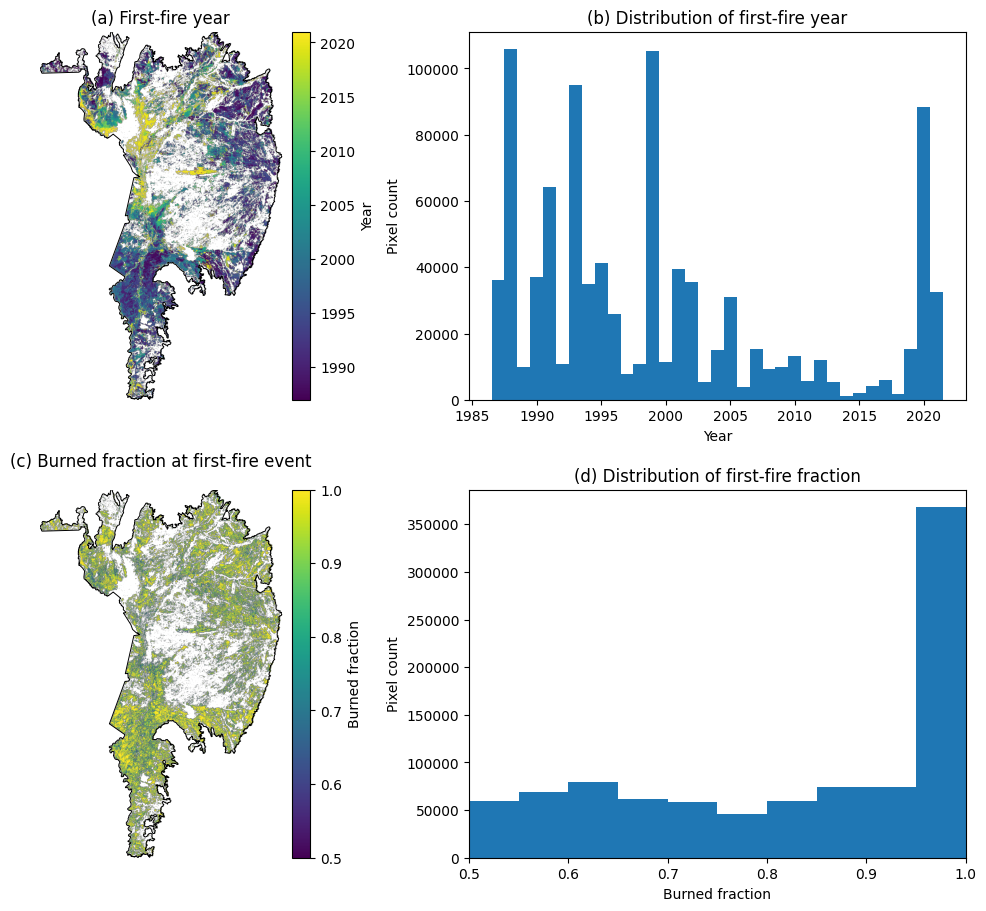

In [ ]:
# @title FIGURA 3 — First-fire year + burned fraction (versão revisada)

from pathlib import Path
import numpy as np
import rasterio as rio
import geopandas as gpd
import matplotlib.pyplot as plt
import yaml

# ----------------------------
# Caminhos
# ----------------------------
# Produtos first-fire já validados da execução original
YEAR_FP = (
    LEGACY_REC_DIR /
    "first_fire_year.tif"
)

FRAC_FP = (
    LEGACY_REC_DIR /
    "first_fire_fraction.tif"
)

CONFIG = yaml.safe_load(open(BASE_DIR / "config.yaml"))
BOUNDARY_PATH = Path(CONFIG["boundary_path"])

assert YEAR_FP.exists(), f"Não encontrei: {YEAR_FP}"
assert FRAC_FP.exists(), f"Não encontrei: {FRAC_FP}"
assert BOUNDARY_PATH.exists(), f"Não encontrei: {BOUNDARY_PATH}"

# ----------------------------
# Ler rasters
# ----------------------------
with rio.open(YEAR_FP) as ds:
    years = ds.read(1).astype("float32")
    tfm = ds.transform
    crs = ds.crs
    H, W = ds.height, ds.width

    xmin, ymax = tfm.c, tfm.f
    xmax = xmin + W * tfm.a
    ymin = ymax + H * tfm.e
    extent = (xmin, xmax, ymin, ymax)

years[years <= 0] = np.nan

with rio.open(FRAC_FP) as ds:
    first_frac = ds.read(1).astype("float32")

first_frac[~np.isfinite(first_frac)] = np.nan

# ----------------------------
# Limite do Pantanal
# ----------------------------
gdf = gpd.read_file(BOUNDARY_PATH).to_crs(crs)

# ----------------------------
# Dados válidos
# ----------------------------
vals_year = years[np.isfinite(years)]
vals_frac = first_frac[np.isfinite(first_frac)]

# ----------------------------
# Figura 2x2
# ----------------------------
fig, axs = plt.subplots(
    2, 2,
    figsize=(12, 9),
    constrained_layout=True
)

def outline(ax):
    gdf.boundary.plot(
        ax=ax,
        edgecolor="black",
        linewidth=0.7
    )

# (a) Ano do primeiro fogo
ax = axs[0, 0]

vminY, vmaxY = np.nanpercentile(vals_year, [2, 98])

im = ax.imshow(
    years,
    vmin=vminY,
    vmax=vmaxY,
    extent=extent,
    origin="upper"
)

outline(ax)

ax.set_title("(a) First-fire year")
ax.axis("off")

cb = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.02
)

cb.set_label("Year")


# (b) Distribuição do ano
ax = axs[0, 1]

binsY = np.arange(
    int(vals_year.min()) - 0.5,
    int(vals_year.max()) + 1.5,
    1
)

ax.hist(vals_year, bins=binsY)

ax.set_title("(b) Distribution of first-fire year")
ax.set_xlabel("Year")
ax.set_ylabel("Pixel count")


# (c) Fração queimada
ax = axs[1, 0]

im = ax.imshow(
    first_frac,
    vmin=0.50,
    vmax=1.00,
    extent=extent,
    origin="upper"
)

outline(ax)

ax.set_title("(c) Burned fraction at first-fire event")
ax.axis("off")

cb = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.02
)

cb.set_label("Burned fraction")


# (d) Distribuição da fração
ax = axs[1, 1]

binsF = np.arange(0.50, 1.001, 0.05)

ax.hist(
    vals_frac,
    bins=binsF
)

ax.set_xlim(0.50, 1.00)

ax.set_title("(d) Distribution of first-fire fraction")
ax.set_xlabel("Burned fraction")
ax.set_ylabel("Pixel count")


# ----------------------------
# Salvar
# ----------------------------
OUT_FIG = REC_DIR / "first_fire_2x2_revised.png"

fig.savefig(
    OUT_FIG,
    dpi=300,
    bbox_inches="tight"
)

print("✔ Figura salva em:", OUT_FIG)

plt.show()

In [ ]:
# @title R3-4 — Leitores canônicos + cache óptico corrigido + VOD corrigido

import numpy as np
import rasterio as rio
from pathlib import Path
from rasterio.features import rasterize
import geopandas as gpd

# =========================================================
# 1. GRADE CANÔNICA
# =========================================================

assert "REF_FP" in globals(), "Rode/defina R3-1b antes."

with rio.open(REF_FP) as ref:
    H = ref.height
    W = ref.width
    TF = ref.transform
    CRS = ref.crs

    PROFILE_F32 = ref.meta.copy()

PROFILE_F32.update(
    count=1,
    dtype="float32",
    nodata=np.nan,
    compress="lzw",
    tiled=True,
    blockxsize=512,
    blockysize=512,
    BIGTIFF="IF_SAFER"
)

# =========================================================
# 2. MÁSCARA DO PANTANAL
# =========================================================

gdf = gpd.read_file(
    BOUNDARY_PATH
).to_crs(CRS)

MASK = rasterize(
    [
        (geom, 1)
        for geom in gdf.geometry
        if geom is not None
        and not geom.is_empty
    ],
    out_shape=(H, W),
    transform=TF,
    fill=0,
    dtype="uint8"
).astype(bool)

print(
    "✔ Grade canônica:",
    f"{H} × {W}",
    "| CRS:",
    CRS
)

# =========================================================
# 3. ÓPTICOS ORIGINAIS
# =========================================================

BAND_IDX = {
    "NDVI": 1,
    "EVI": 2,
    "NBR": 3
}

OPT_SENTINEL = -32768.0
OPT_SCALE = 10000.0


def _opt_stack_path(ym: str):

    for d in OPT_DIRS:

        p = d / f"opt_{ym}.tif"

        if p.exists():
            return p

    for d in MERGE_DIRS:

        p = d / f"opt_{ym}_merged.tif"

        if p.exists():
            return p

    return None


# =========================================================
# 4. DECODIFICAR ÓPTICO
#
# -32768 -> NaN
# valores válidos /10000
# =========================================================

def _decode_opt(arr, nodata=None):

    a = arr.astype(
        "float32",
        copy=True
    )

    # NoData declarado
    if nodata is not None:

        try:
            if np.isfinite(nodata):
                a[a == nodata] = np.nan
        except Exception:
            pass

    # NoData oculto encontrado no QC
    a[a == OPT_SENTINEL] = np.nan

    # escala dos índices
    a = a / OPT_SCALE

    return a.astype("float32")


# =========================================================
# 5. CACHE SINGLE-BAND CORRIGIDO
# =========================================================

def _sb_path(metric: str, ym: str):

    return (
        OPT_SB_DIR /
        f"{metric.lower()}_{ym}_300m.tif"
    )


def ensure_opt_singleband(
    metric: str,
    ym: str
):

    metric = metric.upper()

    assert metric in BAND_IDX

    out_fp = _sb_path(
        metric,
        ym
    )

    # -----------------------------------------
    # já produzido anteriormente
    # -----------------------------------------
    if out_fp.exists():
        return out_fp

    # -----------------------------------------
    # localizar stack original
    # -----------------------------------------
    src_fp = _opt_stack_path(ym)

    if src_fp is None:
        return None

    # -----------------------------------------
    # ler e corrigir
    # -----------------------------------------
    with rio.open(src_fp) as src:

        # guard-rail da grade
        same_grid = (
            src.height == H
            and src.width == W
            and str(src.crs) == str(CRS)
            and np.allclose(
                np.array(src.transform)[:6],
                np.array(TF)[:6],
                atol=1e-6
            )
        )

        if not same_grid:

            raise RuntimeError(
                f"Óptico {ym} não está "
                "na grade canônica 300 m."
            )

        arr = src.read(
            BAND_IDX[metric]
        )

        arr = _decode_opt(
            arr,
            src.nodata
        )

    # -----------------------------------------
    # salvar somente produto corrigido
    # -----------------------------------------
    with rio.open(
        out_fp,
        "w",
        **PROFILE_F32
    ) as dst:

        dst.write(
            arr,
            1
        )

    return out_fp


# =========================================================
# 6. TAMANHO PARA RETORNO NaN
# =========================================================

def _window_shape(window=None):

    if window is None:
        return H, W

    return (
        int(window.height),
        int(window.width)
    )


def _nan_array(window=None):

    h, w = _window_shape(window)

    return np.full(
        (h, w),
        np.nan,
        dtype="float32"
    )


# =========================================================
# 7. LEITOR ÓPTICO CANÔNICO
# =========================================================

def read_opt(
    metric: str,
    ym: str,
    window=None
):

    fp = ensure_opt_singleband(
        metric,
        ym
    )

    # ausência real de dado:
    # mantém calendário, retorna NaN
    if fp is None:
        return _nan_array(window)

    with rio.open(fp) as ds:

        a = ds.read(
            1,
            window=window
        ).astype("float32")

        nod = ds.nodata

    if nod is not None:

        try:
            if np.isfinite(nod):
                a[a == nod] = np.nan
        except Exception:
            pass

    # proteção adicional
    a[a == OPT_SENTINEL] = np.nan

    return a


# =========================================================
# 8. LEITOR VOD CORRIGIDO
#
# IMPORTANTE:
# se um bimestre não existir (ex. lacuna),
# retorna NaN e NÃO remove o período do calendário.
# =========================================================

def read_vod(
    ym: str,
    window=None
):

    fp = (
        VOD_DIR /
        f"vod_{ym}_300m_aligned.tif"
    )

    if not fp.exists():
        return _nan_array(window)

    with rio.open(fp) as ds:

        a = ds.read(
            1,
            window=window
        ).astype("float32")

        nod = ds.nodata

    if nod is not None:

        try:
            if np.isfinite(nod):
                a[a == nod] = np.nan
        except Exception:
            pass

    # guard-rail físico
    a[
        (~np.isfinite(a))
        | (a < 0)
        | (a > 4)
    ] = np.nan

    return a


# =========================================================
# 9. LEITOR ÚNICO POR MÉTRICA
# =========================================================

def read_metric(
    metric: str,
    ym: str,
    window=None
):

    metric = metric.upper()

    if metric == "VOD":

        return read_vod(
            ym,
            window
        )

    if metric in BAND_IDX:

        return read_opt(
            metric,
            ym,
            window
        )

    raise ValueError(
        f"Métrica desconhecida: {metric}"
    )


# =========================================================
# 10. DISPONIBILIDADE
# =========================================================

YMS_OPT = [
    ym
    for ym in YMS
    if _opt_stack_path(ym) is not None
]

YMS_VOD_AVAILABLE = [
    ym
    for ym in YMS
    if (
        VOD_DIR /
        f"vod_{ym}_300m_aligned.tif"
    ).exists()
]

print(
    "\nÓpticos disponíveis:",
    len(YMS_OPT),
    "/",
    len(YMS)
)

print(
    "VOD corrigidos disponíveis:",
    len(YMS_VOD_AVAILABLE),
    "/",
    len(YMS)
)

print(
    "VOD ausentes:",
    [
        ym
        for ym in YMS
        if ym not in YMS_VOD_AVAILABLE
    ]
)

print(
    "\n✔ Leitor óptico:"
    " -32768 → NaN e ÷10000"
)

print(
    "✔ Leitor VOD:"
    " somente dados corrigidos 0–4"
)

print(
    "✔ Ausências não comprimem o calendário."
)


✔ Grade canônica: 2448 × 1612 | CRS: EPSG:31983

Ópticos disponíveis: 203 / 206
VOD corrigidos disponíveis: 205 / 206
VOD ausentes: ['199105']

✔ Leitor óptico: -32768 → NaN e ÷10000
✔ Leitor VOD: somente dados corrigidos 0–4
✔ Ausências não comprimem o calendário.


In [ ]:
# @title R3-4b — Recuperar ópticos ausentes de 2004 a partir do cache legado

import numpy as np
import rasterio as rio

LEGACY_OPT_SB_DIR = OUT_DIR / "opt_singleband_300m_cache"

MISSING_2004 = ["200401", "200403", "200405"]
METRICS_2004 = ["NDVI", "EVI", "NBR"]

for metric in METRICS_2004:

    for ym in MISSING_2004:

        src_fp = (
            LEGACY_OPT_SB_DIR /
            f"{metric.lower()}_{ym}_300m.tif"
        )

        dst_fp = (
            OPT_SB_DIR /
            f"{metric.lower()}_{ym}_300m.tif"
        )

        assert src_fp.exists(), (
            f"Cache legado não encontrado: {src_fp}"
        )

        # não sobrescrever se já corrigido
        if dst_fp.exists():
            print("✔ já existe:", dst_fp.name)
            continue

        with rio.open(src_fp) as src:

            a = src.read(1).astype("float32")
            nod = src.nodata

            # NoData declarado
            if nod is not None:
                try:
                    if np.isfinite(nod):
                        a[a == nod] = np.nan
                except Exception:
                    pass

            # sentinel oculto
            a[a == -32768] = np.nan

            # escala física dos índices
            a = a / 10000.0

            # checar grade
            assert src.height == H
            assert src.width == W
            assert str(src.crs) == str(CRS)

        with rio.open(
            dst_fp,
            "w",
            **PROFILE_F32
        ) as dst:

            dst.write(
                a.astype("float32"),
                1
            )

        v = a[np.isfinite(a)]

        print(
            f"✔ {metric} {ym}: "
            f"N={v.size:,} | "
            f"p01={np.percentile(v,1):.4f} | "
            f"median={np.median(v):.4f} | "
            f"p99={np.percentile(v,99):.4f}"
        )


# =========================================================
# QC FINAL
# =========================================================

missing_corrected = []

for metric in METRICS_2004:

    for ym in MISSING_2004:

        fp = (
            OPT_SB_DIR /
            f"{metric.lower()}_{ym}_300m.tif"
        )

        if not fp.exists():
            missing_corrected.append(
                f"{metric}-{ym}"
            )

print("\n" + "="*60)

if not missing_corrected:

    print(
        "✔ 200401, 200403 e 200405 recuperados "
        "para NDVI, EVI e NBR."
    )

else:

    print(
        "⚠ Faltantes:",
        missing_corrected
    )

✔ já existe: ndvi_200401_300m.tif
✔ já existe: ndvi_200403_300m.tif
✔ já existe: ndvi_200405_300m.tif
✔ já existe: evi_200401_300m.tif
✔ já existe: evi_200403_300m.tif
✔ já existe: evi_200405_300m.tif
✔ já existe: nbr_200401_300m.tif
✔ já existe: nbr_200403_300m.tif
✔ já existe: nbr_200405_300m.tif

✔ 200401, 200403 e 200405 recuperados para NDVI, EVI e NBR.


In [ ]:
# @title R3-4c — PATCH: alinhar automaticamente ópticos fora da grade canônica

import numpy as np
import rasterio as rio
from rasterio.warp import reproject, Resampling


def ensure_opt_singleband(metric: str, ym: str):

    metric = metric.upper()

    assert metric in BAND_IDX

    out_fp = _sb_path(
        metric,
        ym
    )

    # -----------------------------------------------------
    # Se o produto corrigido já existe, reutilizar
    # -----------------------------------------------------
    if out_fp.exists():
        return out_fp

    # -----------------------------------------------------
    # Localizar stack óptico original
    # -----------------------------------------------------
    src_fp = _opt_stack_path(ym)

    if src_fp is None:
        return None

    # -----------------------------------------------------
    # Ler e decodificar
    # -----------------------------------------------------
    with rio.open(src_fp) as src:

        arr = src.read(
            BAND_IDX[metric]
        )

        arr = _decode_opt(
            arr,
            src.nodata
        )

        same_grid = (
            src.height == H
            and src.width == W
            and str(src.crs) == str(CRS)
            and np.allclose(
                np.array(src.transform)[:6],
                np.array(TF)[:6],
                atol=1e-6
            )
        )

        # -------------------------------------------------
        # Se já está na grade canônica
        # -------------------------------------------------
        if same_grid:

            arr_out = arr.astype(
                "float32"
            )

        # -------------------------------------------------
        # Se estiver desalinhado, reprojetar para REF
        # -------------------------------------------------
        else:

            print(
                f"  ↪ {metric} {ym}: "
                "alinhando à grade canônica 300 m"
            )

            arr_out = np.full(
                (H, W),
                np.nan,
                dtype="float32"
            )

            reproject(
                source=arr,
                destination=arr_out,

                src_transform=src.transform,
                src_crs=src.crs,

                dst_transform=TF,
                dst_crs=CRS,

                src_nodata=np.nan,
                dst_nodata=np.nan,

                # índice espectral é variável contínua
                resampling=Resampling.bilinear
            )

    # -----------------------------------------------------
    # Guard-rail após alinhamento
    # -----------------------------------------------------
    assert arr_out.shape == (H, W)

    # -----------------------------------------------------
    # Salvar no NOVO cache corrigido
    # -----------------------------------------------------
    with rio.open(
        out_fp,
        "w",
        **PROFILE_F32
    ) as dst:

        dst.write(
            arr_out.astype("float32"),
            1
        )

    return out_fp


print(
    "✔ PATCH ativo: ópticos desalinhados serão "
    "reprojetados automaticamente para REF_FP."
)

✔ PATCH ativo: ópticos desalinhados serão reprojetados automaticamente para REF_FP.


In [ ]:
# @title R3-5 — Impacto pós-fogo: Δ absoluto e relativo

import gc
import numpy as np
import pandas as pd
import rasterio as rio
from rasterio.windows import Window

# =========================================================
# PARÂMETROS
# =========================================================

METRICS = ["NDVI", "EVI", "NBR", "VOD"]

N_PRE = 6
MAX_POST = 6
EPS = 1e-6

# Reduz uso de memória sem alterar a grade
TILE = 512

# =========================================================
# PRIMEIRO EVENTO DE FOGO JÁ VALIDADO
#
# Não recalcular o fogo nesta etapa.
# Usamos o produto validado da execução original.
# =========================================================

FIRST_FIRE_FP = (
    LEGACY_REC_DIR /
    "first_fire_yyyymm.tif"
)

assert FIRST_FIRE_FP.exists(), (
    f"First-fire não encontrado: {FIRST_FIRE_FP}"
)

with rio.open(FIRST_FIRE_FP) as ds:

    first_fire_ym = (
        ds.read(1)
        .astype("int32")
    )

    assert ds.height == H
    assert ds.width == W
    assert str(ds.crs) == str(CRS)

# yyyymm -> índice temporal t
YM_TO_T = {
    ym: i
    for i, ym in enumerate(YMS)
}

first_fire_t = np.full(
    (H, W),
    -1,
    dtype="int32"
)

for ym, t in YM_TO_T.items():

    m = (
        first_fire_ym ==
        int(ym)
    )

    first_fire_t[m] = t

# Fora do Pantanal não avaliar
first_fire_t[~MASK] = -1

print(
    "✔ First-fire carregado:",
    f"{np.sum(first_fire_t >= 0):,}",
    "pixels"
)

# =========================================================
# FUNÇÃO DE CÁLCULO
# =========================================================

def calculate_impact(metric: str):

    metric = metric.upper()

    impact_abs = np.full(
        (H, W),
        np.nan,
        dtype="float32"
    )

    impact_rel = np.full(
        (H, W),
        np.nan,
        dtype="float32"
    )

    print(f"\n→ {metric}")

    # -----------------------------------------------------
    # Processamento em tiles
    # -----------------------------------------------------

    for r0 in range(0, H, TILE):

        for c0 in range(0, W, TILE):

            h = min(
                TILE,
                H - r0
            )

            w = min(
                TILE,
                W - c0
            )

            win = Window(
                col_off=c0,
                row_off=r0,
                width=w,
                height=h
            )

            FF = first_fire_t[
                r0:r0+h,
                c0:c0+w
            ]

            # Só precisamos trabalhar onde existe
            # primeiro fogo e baseline potencial.
            valid_event = FF >= N_PRE

            if not np.any(valid_event):
                continue

            # =================================================
            # Carregar a série temporal da métrica neste tile
            #
            # read_metric() já:
            # - corrige -32768 e escala nos ópticos
            # - lê somente VOD corrigido
            # - retorna NaN para períodos ausentes
            # =================================================

            X = np.stack(
                [
                    read_metric(
                        metric,
                        ym,
                        window=win
                    )
                    for ym in YMS
                ],
                axis=0
            ).astype("float32")

            # -------------------------------------------------
            # Trabalhar por data de primeiro fogo.
            # Muito mais rápido que percorrer pixel por pixel.
            # -------------------------------------------------

            event_times = np.unique(
                FF[valid_event]
            )

            for t0 in event_times:

                t0 = int(t0)

                if t0 < N_PRE:
                    continue

                pixel_mask = (
                    FF == t0
                )

                # Janela pré-fogo
                pre = X[
                    t0-N_PRE:t0,
                    :,
                    :
                ]

                # Até seis bimestres pós-fogo
                t1 = t0 + 1

                t2 = min(
                    X.shape[0],
                    t0 + 1 + MAX_POST
                )

                if t1 >= t2:
                    continue

                post = X[
                    t1:t2,
                    :,
                    :
                ]

                # ---------------------------------------------
                # Baseline = mediana dos 6 bimestres pré-fogo
                # ---------------------------------------------

                with warnings.catch_warnings():

                    warnings.simplefilter(
                        "ignore",
                        category=RuntimeWarning
                    )

                    baseline = np.nanmedian(
                        pre,
                        axis=0
                    )

                    min_post = np.nanmin(
                        post,
                        axis=0
                    )

                # ---------------------------------------------
                # Pixels com informação suficiente
                # ---------------------------------------------

                has_pre = np.isfinite(
                    pre
                ).any(
                    axis=0
                )

                has_post = np.isfinite(
                    post
                ).any(
                    axis=0
                )

                ok = (
                    pixel_mask
                    & has_pre
                    & has_post
                    & np.isfinite(baseline)
                    & np.isfinite(min_post)
                )

                if not np.any(ok):
                    continue

                d_abs = (
                    baseline -
                    min_post
                )

                d_rel = (
                    d_abs /
                    (
                        np.abs(baseline)
                        + EPS
                    )
                )

                out_abs_tile = impact_abs[
                    r0:r0+h,
                    c0:c0+w
                ]

                out_rel_tile = impact_rel[
                    r0:r0+h,
                    c0:c0+w
                ]

                out_abs_tile[ok] = (
                    d_abs[ok]
                )

                out_rel_tile[ok] = (
                    d_rel[ok]
                )

            del X
            gc.collect()

    # Aplicar máscara final
    impact_abs[~MASK] = np.nan
    impact_rel[~MASK] = np.nan

    return impact_abs, impact_rel


# =========================================================
# SALVAMENTO
# =========================================================

def save_float32(fp, arr):

    with rio.open(
        fp,
        "w",
        **PROFILE_F32
    ) as dst:

        dst.write(
            arr.astype("float32"),
            1
        )


# =========================================================
# PROCESSAR AS QUATRO MÉTRICAS
# =========================================================

summary_rows = []

for metric in METRICS:

    D, DR = calculate_impact(
        metric
    )

    fp_abs = (
        REC_DIR /
        f"p2_delta_{metric}.tif"
    )

    fp_rel = (
        REC_DIR /
        f"p2_delta_rel_{metric}.tif"
    )

    save_float32(
        fp_abs,
        D
    )

    save_float32(
        fp_rel,
        DR
    )

    # -----------------------------------------------------
    # Estatísticas simples para QC
    # -----------------------------------------------------

    v_abs = D[
        np.isfinite(D)
    ]

    v_rel = DR[
        np.isfinite(DR)
    ]

    summary_rows.append({
        "metric": metric,

        "n_abs": int(
            v_abs.size
        ),

        "delta_abs_p01":
            float(np.percentile(v_abs, 1))
            if v_abs.size else np.nan,

        "delta_abs_median":
            float(np.median(v_abs))
            if v_abs.size else np.nan,

        "delta_abs_p99":
            float(np.percentile(v_abs, 99))
            if v_abs.size else np.nan,

        "delta_rel_p01":
            float(np.percentile(v_rel, 1))
            if v_rel.size else np.nan,

        "delta_rel_median":
            float(np.median(v_rel))
            if v_rel.size else np.nan,

        "delta_rel_p99":
            float(np.percentile(v_rel, 99))
            if v_rel.size else np.nan,
    })

    print(
        f"✔ {metric}: "
        f"{v_abs.size:,} pixels válidos"
    )

    del D, DR
    gc.collect()


# =========================================================
# CSV DE QC
# =========================================================

df_delta_qc = pd.DataFrame(
    summary_rows
)

QC_DELTA_FP = (
    REC_DIR /
    "qc_delta_corrected.csv"
)

df_delta_qc.to_csv(
    QC_DELTA_FP,
    index=False
)

print("\n" + "="*60)
print("Δ FINALIZADO")
print("="*60)

display(
    df_delta_qc.round(6)
)

print(
    "\n✔ Rasters salvos em:",
    REC_DIR
)

print(
    "✔ QC salvo em:",
    QC_DELTA_FP
)


✔ First-fire carregado: 949,064 pixels

→ NDVI
  ↪ NDVI 201107: alinhando à grade canônica 300 m
  ↪ NDVI 201109: alinhando à grade canônica 300 m
  ↪ NDVI 201111: alinhando à grade canônica 300 m
  ↪ NDVI 201207: alinhando à grade canônica 300 m
  ↪ NDVI 201209: alinhando à grade canônica 300 m
  ↪ NDVI 201211: alinhando à grade canônica 300 m
✔ NDVI: 887,914 pixels válidos

→ EVI
  ↪ EVI 201107: alinhando à grade canônica 300 m
  ↪ EVI 201109: alinhando à grade canônica 300 m
  ↪ EVI 201111: alinhando à grade canônica 300 m
  ↪ EVI 201207: alinhando à grade canônica 300 m
  ↪ EVI 201209: alinhando à grade canônica 300 m
  ↪ EVI 201211: alinhando à grade canônica 300 m
✔ EVI: 887,914 pixels válidos

→ NBR
  ↪ NBR 201107: alinhando à grade canônica 300 m
  ↪ NBR 201109: alinhando à grade canônica 300 m
  ↪ NBR 201111: alinhando à grade canônica 300 m
  ↪ NBR 201207: alinhando à grade canônica 300 m
  ↪ NBR 201209: alinhando à grade canônica 300 m
  ↪ NBR 201211: alinhando à grade canôn

,metric,n_abs,delta_abs_p01,delta_abs_median,delta_abs_p99,delta_rel_p01,delta_rel_median,delta_rel_p99
0,NDVI,887914,-0.08540,0.168450,0.510400,-0.169622,0.279440,0.791473
1,EVI,887914,-0.07780,0.087800,0.346250,-0.322856,0.267914,0.778862
2,NBR,887914,-0.14050,0.265050,0.752900,-0.427491,0.610595,1.698059
3,VOD,883009,-0.10478,0.098687,0.441782,-0.195455,0.147276,0.616240



✔ Rasters salvos em: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/recovery_nb3_corrected
✔ QC salvo em: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/recovery_nb3_corrected/qc_delta_corrected.csv


✔ Figura salva em: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/recovery_nb3_corrected/fig_delta_histograms_2x4.png


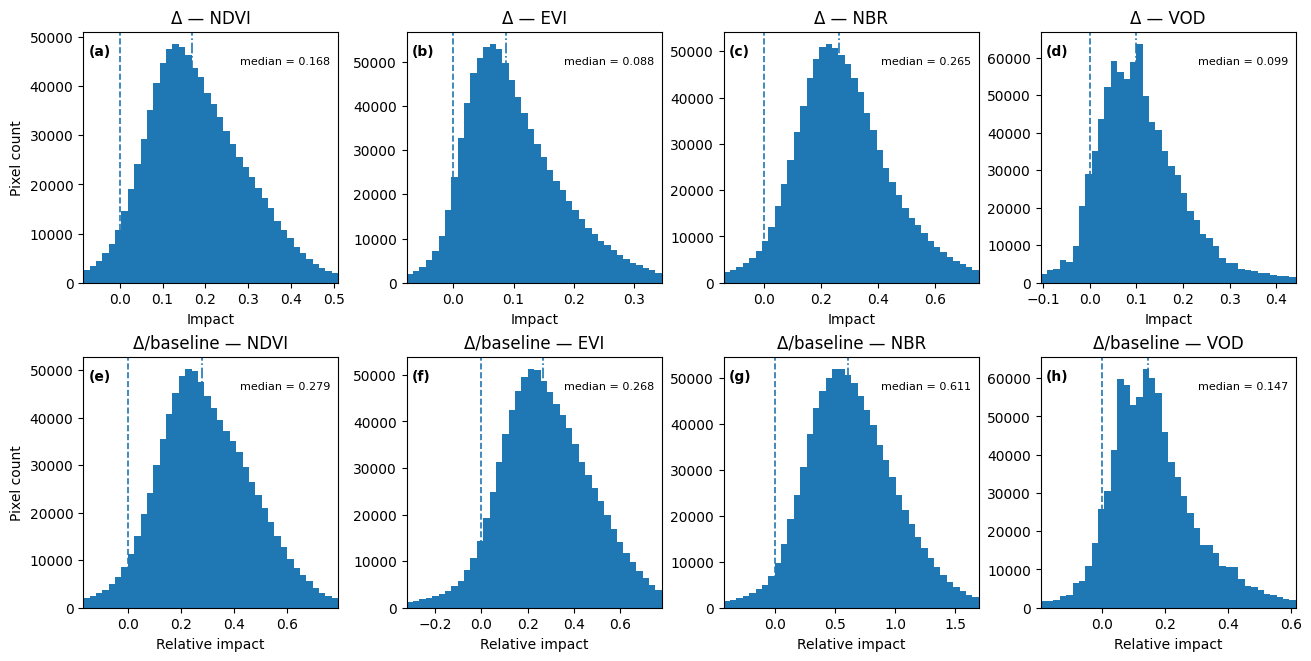

In [ ]:
# @title R3-6 — Histogramas de Δ absoluto e relativo

import numpy as np
import rasterio as rio
import matplotlib.pyplot as plt

METRICS = ["NDVI", "EVI", "NBR", "VOD"]

# =========================================================
# LEITURA
# =========================================================

def read_valid(fp):

    assert fp.exists(), f"Arquivo não encontrado: {fp}"

    with rio.open(fp) as ds:
        a = ds.read(1).astype("float32")
        nod = ds.nodata

    if nod is not None:
        try:
            if np.isfinite(nod):
                a[a == nod] = np.nan
        except Exception:
            pass

    return a[np.isfinite(a)]


vals_abs = {}
vals_rel = {}

for metric in METRICS:

    fp_abs = REC_DIR / f"p2_delta_{metric}.tif"
    fp_rel = REC_DIR / f"p2_delta_rel_{metric}.tif"

    vals_abs[metric] = read_valid(fp_abs)
    vals_rel[metric] = read_valid(fp_rel)

# =========================================================
# FIGURA
# =========================================================

fig, axes = plt.subplots(
    2,
    4,
    figsize=(13, 6.5),
    constrained_layout=True
)

letters = [f"({c})" for c in "abcdefgh"]

# ---------------------------------------------------------
# Linha 1 — Δ absoluto
# ---------------------------------------------------------

for j, metric in enumerate(METRICS):

    ax = axes[0, j]
    v = vals_abs[metric]

    if v.size:

        # faixa robusta por métrica
        lo, hi = np.percentile(v, [1, 99])

        vv = v[
            (v >= lo) &
            (v <= hi)
        ]

        ax.hist(
            vv,
            bins=40
        )

        med = float(
            np.median(v)
        )

        ax.axvline(
            0,
            linestyle="--",
            linewidth=1.2
        )

        ax.axvline(
            med,
            linestyle="-.",
            linewidth=1.2
        )

        ax.set_xlim(
            lo,
            hi
        )

        ax.text(
            0.97,
            0.90,
            f"median = {med:.3f}",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=8
        )

    ax.set_title(
        f"Δ — {metric}"
    )

    ax.set_xlabel(
        "Impact"
    )

    if j == 0:
        ax.set_ylabel(
            "Pixel count"
        )

    ax.text(
        0.02,
        0.95,
        letters[j],
        transform=ax.transAxes,
        fontweight="bold",
        va="top"
    )

# ---------------------------------------------------------
# Linha 2 — Δ relativo
# ---------------------------------------------------------

for j, metric in enumerate(METRICS):

    ax = axes[1, j]
    v = vals_rel[metric]

    if v.size:

        lo, hi = np.percentile(v, [1, 99])

        vv = v[
            (v >= lo) &
            (v <= hi)
        ]

        ax.hist(
            vv,
            bins=40
        )

        med = float(
            np.median(v)
        )

        ax.axvline(
            0,
            linestyle="--",
            linewidth=1.2
        )

        ax.axvline(
            med,
            linestyle="-.",
            linewidth=1.2
        )

        ax.set_xlim(
            lo,
            hi
        )

        ax.text(
            0.97,
            0.90,
            f"median = {med:.3f}",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=8
        )

    ax.set_title(
        f"Δ/baseline — {metric}"
    )

    ax.set_xlabel(
        "Relative impact"
    )

    if j == 0:
        ax.set_ylabel(
            "Pixel count"
        )

    ax.text(
        0.02,
        0.95,
        letters[4+j],
        transform=ax.transAxes,
        fontweight="bold",
        va="top"
    )

# =========================================================
# SALVAR
# =========================================================

OUT_FIG = (
    REC_DIR /
    "fig_delta_histograms_2x4.png"
)

fig.savefig(
    OUT_FIG,
    dpi=300,
    bbox_inches="tight"
)

print(
    "✔ Figura salva em:",
    OUT_FIG
)

plt.show()




In [ ]:
# @title QC — remover arquivos corrompidos do cache óptico corrigido

import rasterio as rio
from rasterio.windows import Window

bad_files = []

files = sorted(OPT_SB_DIR.glob("*.tif"))

print("Arquivos no cache:", len(files))

for fp in files:

    try:
        with rio.open(fp) as ds:

            # checagem básica de estrutura
            if ds.count != 1:
                raise RuntimeError("número de bandas inválido")

            if ds.height != H or ds.width != W:
                raise RuntimeError(
                    f"shape inválido: {ds.height}x{ds.width}"
                )

            if str(ds.crs) != str(CRS):
                raise RuntimeError(
                    f"CRS inválido: {ds.crs}"
                )

            # tenta realmente ler um pequeno bloco
            h = min(32, ds.height)
            w = min(32, ds.width)

            _ = ds.read(
                1,
                window=Window(0, 0, w, h)
            )

    except Exception as e:

        bad_files.append(
            (fp, str(e))
        )


print("\nArquivos problemáticos:", len(bad_files))

for fp, err in bad_files:

    print("✖", fp.name)
    print("  ", err)

    try:
        fp.unlink()
        print("  → removido; será recriado automaticamente.")
    except Exception as e:
        print("  → falha ao remover:", e)


print("\n✔ QC concluído.")

Arquivos no cache: 618

Arquivos problemáticos: 0

✔ QC concluído.


In [ ]:
# @title R3-7 — TTR corrigido: impacto → nadir → recuperação

import gc
import warnings
import numpy as np
import pandas as pd
import rasterio as rio
from rasterio.windows import Window

# =========================================================
# PARÂMETROS
# =========================================================

METRICS = ["NDVI", "EVI", "NBR", "VOD"]

ALPHA = 0.90

# baseline = mediana dos 6 bimestres anteriores
N_PRE = 6

# janela usada para detectar o impacto/nadir
# 6 bimestres = 12 meses
IMPACT_WIN = 6

# acompanhamento máximo para recuperação
# 18 bimestres = 36 meses
MAX_POST = 18

EPS = 1e-6
TILE = 512


# =========================================================
# STATUS
#
# 0 = not evaluated / outside analysis
# 1 = recovered after detectable impact
# 2 = impact detected, threshold not reached during
#     available post-nadir follow-up
# 3 = insufficient post-fire data
# 4 = no detectable threshold-level impact
# =========================================================

STATUS_NOT_EVALUATED = 0
STATUS_RECOVERED = 1
STATUS_NOT_REACHED = 2
STATUS_INSUFFICIENT = 3
STATUS_NO_IMPACT = 4


# =========================================================
# 1. PRIMEIRO EVENTO DE FOGO
# =========================================================

FIRST_FIRE_FP = (
    REC_DIR /
    "first_fire_yyyymm.tif"
)

if not FIRST_FIRE_FP.exists():

    FIRST_FIRE_FP = (
        LEGACY_REC_DIR /
        "first_fire_yyyymm.tif"
    )

assert FIRST_FIRE_FP.exists(), (
    f"First-fire não encontrado: {FIRST_FIRE_FP}"
)

with rio.open(FIRST_FIRE_FP) as ds:

    first_fire_ym = (
        ds.read(1)
        .astype("int32")
    )

    assert ds.height == H
    assert ds.width == W
    assert str(ds.crs) == str(CRS)

    assert np.allclose(
        np.array(ds.transform)[:6],
        np.array(TF)[:6],
        atol=1e-6
    )

print(
    "✔ First-fire usado:",
    FIRST_FIRE_FP
)


# =========================================================
# 2. YYYYMM → ÍNDICE TEMPORAL
# =========================================================

YM_TO_T = {
    ym: i
    for i, ym in enumerate(YMS)
}

first_fire_t = np.full(
    (H, W),
    -1,
    dtype="int32"
)

for ym, t in YM_TO_T.items():

    m = (
        first_fire_ym ==
        int(ym)
    )

    first_fire_t[m] = t

first_fire_t[~MASK] = -1

print(
    "✔ Pixels com primeiro fogo:",
    f"{np.sum(first_fire_t >= 0):,}"
)


# =========================================================
# 3. PERFIS DE SAÍDA
# =========================================================

with rio.open(REF_FP) as ref:

    PROFILE_U8 = ref.meta.copy()

PROFILE_U8.update(
    count=1,
    dtype="uint8",
    nodata=0,
    compress="lzw",
    tiled=True,
    blockxsize=512,
    blockysize=512,
    BIGTIFF="IF_SAFER"
)


# =========================================================
# 4. FUNÇÕES DE SALVAMENTO
# =========================================================

def save_f32(fp, arr):

    with rio.open(
        fp,
        "w",
        **PROFILE_F32
    ) as dst:

        dst.write(
            arr.astype("float32"),
            1
        )


def save_u8(fp, arr):

    with rio.open(
        fp,
        "w",
        **PROFILE_U8
    ) as dst:

        dst.write(
            arr.astype("uint8"),
            1
        )


# =========================================================
# 5. CÁLCULO DO TTR
# =========================================================

def calculate_ttr(metric: str):

    metric = metric.upper()

    print("\n" + "="*65)
    print("TTR:", metric)
    print("="*65)

    baseline = np.full(
        (H, W),
        np.nan,
        dtype="float32"
    )

    threshold = np.full(
        (H, W),
        np.nan,
        dtype="float32"
    )

    ttr_map = np.full(
        (H, W),
        np.nan,
        dtype="float32"
    )

    # momento do mínimo pós-fogo
    # contado desde o fogo: 1...6
    nadir_map = np.full(
        (H, W),
        np.nan,
        dtype="float32"
    )

    status = np.zeros(
        (H, W),
        dtype="uint8"
    )


    # =====================================================
    # PROCESSAMENTO EM TILES
    # =====================================================

    for r0 in range(0, H, TILE):

        for c0 in range(0, W, TILE):

            h = min(
                TILE,
                H - r0
            )

            w = min(
                TILE,
                W - c0
            )

            win = Window(
                col_off=c0,
                row_off=r0,
                width=w,
                height=h
            )

            FF = first_fire_t[
                r0:r0+h,
                c0:c0+w
            ]

            # evento precisa ter os 6 períodos pré-fogo
            if not np.any(
                FF >= N_PRE
            ):
                continue


            # =================================================
            # SÉRIE TEMPORAL
            #
            # read_metric():
            # ópticos: -32768 → NaN e /10000
            # VOD: somente produto corrigido
            # lacunas: NaN sem comprimir o calendário
            # =================================================

            X = np.stack(
                [
                    read_metric(
                        metric,
                        ym,
                        window=win
                    )
                    for ym in YMS
                ],
                axis=0
            ).astype("float32")


            event_times = np.unique(
                FF[
                    FF >= N_PRE
                ]
            )


            # =================================================
            # CADA DATA DE PRIMEIRO FOGO
            # =================================================

            for t0 in event_times:

                t0 = int(t0)

                event_mask = (
                    FF == t0
                )


                # -------------------------------------------------
                # A. BASELINE PRÉ-FOGO
                # -------------------------------------------------

                pre = X[
                    t0-N_PRE:t0
                ]

                with warnings.catch_warnings():

                    warnings.simplefilter(
                        "ignore",
                        RuntimeWarning
                    )

                    base = np.nanmedian(
                        pre,
                        axis=0
                    )


                has_pre = np.isfinite(
                    pre
                ).any(
                    axis=0
                )

                valid_base = (
                    event_mask
                    & has_pre
                    & np.isfinite(base)
                    & (
                        np.abs(base) >
                        EPS
                    )
                )

                if not np.any(
                    valid_base
                ):
                    continue


                target = (
                    ALPHA *
                    base
                )


                # -------------------------------------------------
                # guardar baseline e threshold
                # -------------------------------------------------

                base_tile = baseline[
                    r0:r0+h,
                    c0:c0+w
                ]

                thr_tile = threshold[
                    r0:r0+h,
                    c0:c0+w
                ]

                base_tile[
                    valid_base
                ] = base[
                    valid_base
                ]

                thr_tile[
                    valid_base
                ] = target[
                    valid_base
                ]


                status_tile = status[
                    r0:r0+h,
                    c0:c0+w
                ]

                ttr_tile = ttr_map[
                    r0:r0+h,
                    c0:c0+w
                ]

                nadir_tile = nadir_map[
                    r0:r0+h,
                    c0:c0+w
                ]


                # -------------------------------------------------
                # B. JANELA DE IMPACTO / NADIR
                #
                # primeiros 6 bimestres pós-fogo
                # -------------------------------------------------

                impact_start = t0 + 1

                impact_end = min(
                    len(YMS),
                    t0 + 1 + IMPACT_WIN
                )

                if impact_start >= impact_end:

                    status_tile[
                        valid_base
                    ] = STATUS_INSUFFICIENT

                    continue


                impact_post = X[
                    impact_start:impact_end
                ]


                has_impact_data = np.isfinite(
                    impact_post
                ).any(
                    axis=0
                )


                # -------------------------------------------------
                # sem qualquer observação válida na janela
                # -------------------------------------------------

                insufficient_impact = (
                    valid_base
                    & (~has_impact_data)
                )

                status_tile[
                    insufficient_impact
                ] = STATUS_INSUFFICIENT


                # -------------------------------------------------
                # C. IMPACTO DETECTÁVEL
                #
                # precisa haver pelo menos um valor:
                # V < 0.90 × baseline
                # -------------------------------------------------

                below_threshold = (
                    np.isfinite(
                        impact_post
                    )
                    &
                    (
                        impact_post <
                        target[
                            None,
                            :,
                            :
                        ]
                    )
                )


                impact_detected = (
                    valid_base
                    & has_impact_data
                    & below_threshold.any(
                        axis=0
                    )
                )


                # -------------------------------------------------
                # D. SEM IMPACTO DETECTÁVEL
                #
                # não é "recuperação instantânea"
                # -------------------------------------------------

                no_detectable_impact = (
                    valid_base
                    & has_impact_data
                    & (~impact_detected)
                )

                status_tile[
                    no_detectable_impact
                ] = STATUS_NO_IMPACT


                if not np.any(
                    impact_detected
                ):
                    continue


                # -------------------------------------------------
                # E. NADIR
                #
                # mínimo observado dentro dos primeiros
                # 6 períodos pós-fogo
                # -------------------------------------------------

                safe = np.where(
                    np.isfinite(
                        impact_post
                    ),
                    impact_post,
                    np.inf
                )


                nadir_idx = np.argmin(
                    safe,
                    axis=0
                )

                # nadir contado desde o fogo:
                # índice 0 -> t+1
                nadir_bimonth = (
                    nadir_idx +
                    1
                ).astype(
                    "float32"
                )

                nadir_tile[
                    impact_detected
                ] = nadir_bimonth[
                    impact_detected
                ]


                # -------------------------------------------------
                # F. RECUPERAÇÃO APÓS O NADIR
                #
                # Agrupamos pela posição do nadir
                # para evitar loop por pixel.
                # -------------------------------------------------

                for k in range(
                    impact_post.shape[0]
                ):

                    pixels_k = (
                        impact_detected
                        &
                        (
                            nadir_idx ==
                            k
                        )
                    )

                    if not np.any(
                        pixels_k
                    ):
                        continue


                    # nadir está em:
                    # t0 + 1 + k
                    #
                    # busca começa somente DEPOIS dele
                    recovery_start = (
                        t0 +
                        1 +
                        k +
                        1
                    )

                    recovery_end = min(
                        len(YMS),
                        t0 + 1 + MAX_POST
                    )


                    # ---------------------------------------------
                    # sem período cronológico depois do nadir
                    # ---------------------------------------------

                    if recovery_start >= recovery_end:

                        status_tile[
                            pixels_k
                        ] = STATUS_INSUFFICIENT

                        continue


                    recovery_post = X[
                        recovery_start:
                        recovery_end
                    ]


                    has_after_nadir = np.isfinite(
                        recovery_post
                    ).any(
                        axis=0
                    )


                    # ---------------------------------------------
                    # impacto conhecido, mas nenhum dado
                    # depois do nadir
                    # ---------------------------------------------

                    insufficient_after = (
                        pixels_k
                        & (~has_after_nadir)
                    )

                    status_tile[
                        insufficient_after
                    ] = STATUS_INSUFFICIENT


                    # ---------------------------------------------
                    # primeira observação >= 90% baseline
                    # APÓS o nadir
                    # ---------------------------------------------

                    hit_matrix = (
                        np.isfinite(
                            recovery_post
                        )
                        &
                        (
                            recovery_post >=
                            target[
                                None,
                                :,
                                :
                            ]
                        )
                    )


                    has_hit = (
                        pixels_k
                        & has_after_nadir
                        & hit_matrix.any(
                            axis=0
                        )
                    )


                    # ---------------------------------------------
                    # TTR contado DESDE O FOGO
                    # ---------------------------------------------

                    first_hit_rel = np.argmax(
                        hit_matrix,
                        axis=0
                    )

                    # recovery_start - t0
                    first_possible_ttr = (
                        recovery_start -
                        t0
                    )

                    ttr_value = (
                        first_possible_ttr
                        +
                        first_hit_rel
                    ).astype(
                        "float32"
                    )


                    ttr_tile[
                        has_hit
                    ] = ttr_value[
                        has_hit
                    ]

                    status_tile[
                        has_hit
                    ] = STATUS_RECOVERED


                    # ---------------------------------------------
                    # havia dados depois do nadir,
                    # mas não recuperou no follow-up disponível
                    # ---------------------------------------------

                    not_reached = (
                        pixels_k
                        & has_after_nadir
                        & (~has_hit)
                    )

                    status_tile[
                        not_reached
                    ] = STATUS_NOT_REACHED


            del X
            gc.collect()


    # =====================================================
    # MÁSCARA FINAL
    # =====================================================

    baseline[
        ~MASK
    ] = np.nan

    threshold[
        ~MASK
    ] = np.nan

    ttr_map[
        ~MASK
    ] = np.nan

    nadir_map[
        ~MASK
    ] = np.nan

    status[
        ~MASK
    ] = STATUS_NOT_EVALUATED


    return (
        baseline,
        threshold,
        nadir_map,
        ttr_map,
        status
    )


# =========================================================
# 6. PROCESSAR AS QUATRO MÉTRICAS
# =========================================================

summary_rows = []

for metric in METRICS:

    (
        baseline,
        threshold,
        nadir_map,
        ttr_map,
        status
    ) = calculate_ttr(
        metric
    )


    # -----------------------------------------------------
    # SALVAR
    # -----------------------------------------------------

    save_f32(
        REC_DIR /
        f"ttr_threshold_{metric}.tif",
        threshold
    )

    save_f32(
        REC_DIR /
        f"ttr_nadir_time_{metric}_bimestres.tif",
        nadir_map
    )

    save_f32(
        REC_DIR /
        f"ttr_time_{metric}_bimestres.tif",
        ttr_map
    )

    save_u8(
        REC_DIR /
        f"ttr_status_{metric}.tif",
        status
    )


    # =====================================================
    # QC
    # =====================================================

    n_recovered = int(
        np.sum(
            status ==
            STATUS_RECOVERED
        )
    )

    n_not_reached = int(
        np.sum(
            status ==
            STATUS_NOT_REACHED
        )
    )

    n_insufficient = int(
        np.sum(
            status ==
            STATUS_INSUFFICIENT
        )
    )

    n_no_impact = int(
        np.sum(
            status ==
            STATUS_NO_IMPACT
        )
    )

    n_evaluated = (
        n_recovered
        + n_not_reached
        + n_insufficient
        + n_no_impact
    )


    # somente pixels que realmente sofreram
    # impacto detectável
    n_impact_detected = (
        n_recovered
        + n_not_reached
        + n_insufficient
    )


    ttr_valid = ttr_map[
        np.isfinite(
            ttr_map
        )
    ]

    nadir_valid = nadir_map[
        np.isfinite(
            nadir_map
        )
    ]


    summary_rows.append({

        "metric":
            metric,

        "evaluated":
            n_evaluated,

        "detectable_impact":
            n_impact_detected,

        "detectable_impact_pct":
            (
                100 *
                n_impact_detected /
                n_evaluated
                if n_evaluated
                else np.nan
            ),

        "no_detectable_impact":
            n_no_impact,

        "no_detectable_impact_pct":
            (
                100 *
                n_no_impact /
                n_evaluated
                if n_evaluated
                else np.nan
            ),

        "recovered_after_impact":
            n_recovered,

        "recovered_after_impact_pct":
            (
                100 *
                n_recovered /
                n_impact_detected
                if n_impact_detected
                else np.nan
            ),

        "threshold_not_reached":
            n_not_reached,

        "threshold_not_reached_pct":
            (
                100 *
                n_not_reached /
                n_impact_detected
                if n_impact_detected
                else np.nan
            ),

        "insufficient_data":
            n_insufficient,

        "insufficient_data_pct":
            (
                100 *
                n_insufficient /
                n_impact_detected
                if n_impact_detected
                else np.nan
            ),

        "nadir_p25":
            (
                float(
                    np.percentile(
                        nadir_valid,
                        25
                    )
                )
                if nadir_valid.size
                else np.nan
            ),

        "nadir_median":
            (
                float(
                    np.median(
                        nadir_valid
                    )
                )
                if nadir_valid.size
                else np.nan
            ),

        "nadir_p75":
            (
                float(
                    np.percentile(
                        nadir_valid,
                        75
                    )
                )
                if nadir_valid.size
                else np.nan
            ),

        "ttr_p25":
            (
                float(
                    np.percentile(
                        ttr_valid,
                        25
                    )
                )
                if ttr_valid.size
                else np.nan
            ),

        "ttr_median":
            (
                float(
                    np.median(
                        ttr_valid
                    )
                )
                if ttr_valid.size
                else np.nan
            ),

        "ttr_p75":
            (
                float(
                    np.percentile(
                        ttr_valid,
                        75
                    )
                )
                if ttr_valid.size
                else np.nan
            ),

        "ttr_max":
            (
                float(
                    np.max(
                        ttr_valid
                    )
                )
                if ttr_valid.size
                else np.nan
            )
    })


    print(
        f"\n✔ {metric}: "
        f"evaluated={n_evaluated:,} | "
        f"impact={n_impact_detected:,} | "
        f"no-impact={n_no_impact:,} | "
        f"recovered={n_recovered:,} | "
        f"<90%={n_not_reached:,} | "
        f"insufficient={n_insufficient:,}"
    )


    del (
        baseline,
        threshold,
        nadir_map,
        ttr_map,
        status
    )

    gc.collect()


# =========================================================
# 7. QC FINAL
# =========================================================

df_ttr_qc = pd.DataFrame(
    summary_rows
)

QC_TTR_FP = (
    REC_DIR /
    "qc_ttr_corrected.csv"
)

df_ttr_qc.to_csv(
    QC_TTR_FP,
    index=False
)

print("\n" + "="*65)
print("TTR FINALIZADO — IMPACTO → NADIR → RECUPERAÇÃO")
print("="*65)

display(
    df_ttr_qc.round(3)
)

print(
    "\n✔ Produtos salvos em:",
    REC_DIR
)

print(
    "✔ QC:",
    QC_TTR_FP
)

print(
    "\nStatus:"
)

print(
    "0 = not evaluated"
)

print(
    "1 = recovered after detectable impact"
)

print(
    "2 = threshold not reached during available follow-up"
)

print(
    "3 = insufficient post-fire data"
)

print(
    "4 = no detectable threshold-level impact"
)

✔ First-fire usado: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/recovery_nb3_corrected/first_fire_yyyymm.tif
✔ Pixels com primeiro fogo: 949,064

TTR: NDVI

✔ NDVI: evaluated=896,525 | impact=780,046 | no-impact=116,479 | recovered=747,159 | <90%=19,118 | insufficient=13,769

TTR: EVI

✔ EVI: evaluated=896,525 | impact=740,460 | no-impact=156,065 | recovered=706,760 | <90%=18,849 | insufficient=14,851

TTR: NBR

✔ NBR: evaluated=896,522 | impact=838,089 | no-impact=58,433 | recovered=781,337 | <90%=37,674 | insufficient=19,078

TTR: VOD

✔ VOD: evaluated=890,594 | impact=584,370 | no-impact=306,224 | recovered=565,359 | <90%=7,957 | insufficient=11,054

TTR FINALIZADO — IMPACTO → NADIR → RECUPERAÇÃO


,metric,evaluated,detectable_impact,detectable_impact_pct,no_detectable_impact,no_detectable_impact_pct,recovered_after_impact,recovered_after_impact_pct,threshold_not_reached,threshold_not_reached_pct,insufficient_data,insufficient_data_pct,nadir_p25,nadir_median,nadir_p75,ttr_p25,ttr_median,ttr_p75,ttr_max
0,NDVI,896525,780046,87.008,116479,12.992,747159,95.784,19118,2.451,13769,1.765,1.0,5.0,6.0,3.0,7.0,7.0,18.0
1,EVI,896525,740460,82.592,156065,17.408,706760,95.449,18849,2.546,14851,2.006,1.0,5.0,5.0,3.0,6.0,7.0,18.0
2,NBR,896522,838089,93.482,58433,6.518,781337,93.228,37674,4.495,19078,2.276,1.0,4.0,6.0,3.0,6.0,8.0,18.0
3,VOD,890594,584370,65.616,306224,34.384,565359,96.747,7957,1.362,11054,1.892,2.0,3.0,4.0,3.0,4.0,6.0,18.0



✔ Produtos salvos em: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/recovery_nb3_corrected
✔ QC: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/recovery_nb3_corrected/qc_ttr_corrected.csv

Status:
0 = not evaluated
1 = recovered after detectable impact
2 = threshold not reached during available follow-up
3 = insufficient post-fire data
4 = no detectable threshold-level impact


In [ ]:
# @title DIAG — VOD: TTR=1 ocorreu antes do mínimo pós-fogo?

import numpy as np
import rasterio as rio
from rasterio.windows import Window

TILE = 512
MAX_IMPACT = 6

# TTR VOD atual
TTR_FP = REC_DIR / "ttr_time_VOD_bimestres.tif"

assert TTR_FP.exists()

with rio.open(TTR_FP) as ds:
    TTR_CURRENT = ds.read(1).astype("float32")


counts = {
    "avaliados": 0,
    "ttr1_atual": 0,
    "ttr1_mas_cai_depois": 0,
    "primeiro_acima_limiar": 0,
    "primeiro_acima_mas_cai_depois": 0,
    "primeiro_abaixo_limiar": 0,
    "nunca_cai_abaixo_90": 0,
    "cai_abaixo_90": 0
}

nadir_hist = np.zeros(6, dtype=np.int64)


for r0 in range(0, H, TILE):

    for c0 in range(0, W, TILE):

        h = min(TILE, H-r0)
        w = min(TILE, W-c0)

        win = Window(c0, r0, w, h)

        FF = first_fire_t[
            r0:r0+h,
            c0:c0+w
        ]

        if not np.any(FF >= N_PRE):
            continue

        X = np.stack(
            [
                read_metric(
                    "VOD",
                    ym,
                    window=win
                )
                for ym in YMS
            ],
            axis=0
        ).astype("float32")

        TTR_TILE = TTR_CURRENT[
            r0:r0+h,
            c0:c0+w
        ]

        for t0 in np.unique(
            FF[FF >= N_PRE]
        ):

            t0 = int(t0)

            event = (FF == t0)

            pre = X[
                t0-N_PRE:t0
            ]

            with np.errstate(all="ignore"):
                base = np.nanmedian(
                    pre,
                    axis=0
                )

            valid_base = (
                event &
                np.isfinite(base) &
                (np.abs(base) > 1e-6)
            )

            if not np.any(valid_base):
                continue

            target = 0.90 * base

            t1 = t0 + 1
            t2 = min(
                len(YMS),
                t0 + 1 + MAX_IMPACT
            )

            if t1 >= t2:
                continue

            post = X[t1:t2]

            has_post = np.isfinite(
                post
            ).any(axis=0)

            valid = (
                valid_base &
                has_post
            )

            if not np.any(valid):
                continue

            counts["avaliados"] += int(
                valid.sum()
            )

            first = post[0]

            first_above = (
                valid &
                np.isfinite(first) &
                (first >= target)
            )

            first_below = (
                valid &
                np.isfinite(first) &
                (first < target)
            )

            ever_below = (
                (
                    np.isfinite(post) &
                    (post < target[None, :, :])
                ).any(axis=0)
                &
                valid
            )

            never_below = (
                valid &
                (~ever_below)
            )

            above_then_below = (
                first_above &
                ever_below
            )

            current_ttr1 = (
                valid &
                np.isfinite(TTR_TILE) &
                (TTR_TILE == 1)
            )

            ttr1_then_below = (
                current_ttr1 &
                ever_below
            )

            counts["ttr1_atual"] += int(
                current_ttr1.sum()
            )

            counts["ttr1_mas_cai_depois"] += int(
                ttr1_then_below.sum()
            )

            counts["primeiro_acima_limiar"] += int(
                first_above.sum()
            )

            counts["primeiro_acima_mas_cai_depois"] += int(
                above_then_below.sum()
            )

            counts["primeiro_abaixo_limiar"] += int(
                first_below.sum()
            )

            counts["nunca_cai_abaixo_90"] += int(
                never_below.sum()
            )

            counts["cai_abaixo_90"] += int(
                ever_below.sum()
            )

            # posição do mínimo nos primeiros 6 bimestres
            safe = np.where(
                np.isfinite(post),
                post,
                np.inf
            )

            nadir = np.argmin(
                safe,
                axis=0
            )

            for k in range(post.shape[0]):

                nadir_hist[k] += int(
                    (
                        valid &
                        ever_below &
                        (nadir == k)
                    ).sum()
                )


print("\n" + "="*65)
print("DIAGNÓSTICO VOD")
print("="*65)

for k, v in counts.items():
    print(f"{k:32s}: {v:,}")

if counts["ttr1_atual"] > 0:

    pct = (
        100 *
        counts["ttr1_mas_cai_depois"] /
        counts["ttr1_atual"]
    )

    print(
        "\n% dos atuais TTR=1 que depois "
        f"caem abaixo de 90%: {pct:.2f}%"
    )


if counts["primeiro_acima_limiar"] > 0:

    pct = (
        100 *
        counts["primeiro_acima_mas_cai_depois"] /
        counts["primeiro_acima_limiar"]
    )

    print(
        "% primeiro pós-fogo ≥90% que "
        f"posteriormente cai <90%: {pct:.2f}%"
    )


print("\nPosição do mínimo entre os primeiros 6 pós-fogo:")

for i, n in enumerate(nadir_hist, start=1):

    print(
        f"  pós-fogo {i}: {n:,}"
    )

/tmp/ipykernel_1958/3084790883.py:80: RuntimeWarning: All-NaN slice encountered
  base = np.nanmedian(



DIAGNÓSTICO VOD
avaliados                       : 883,009
ttr1_atual                      : 744,890
ttr1_mas_cai_depois             : 439,215
primeiro_acima_limiar           : 744,890
primeiro_acima_mas_cai_depois   : 439,215
primeiro_abaixo_limiar          : 135,973
nunca_cai_abaixo_90             : 306,224
cai_abaixo_90                   : 576,785

% dos atuais TTR=1 que depois caem abaixo de 90%: 58.96%
% primeiro pós-fogo ≥90% que posteriormente cai <90%: 58.96%

Posição do mínimo entre os primeiros 6 pós-fogo:
  pós-fogo 1: 80,479
  pós-fogo 2: 178,475
  pós-fogo 3: 135,724
  pós-fogo 4: 65,809
  pós-fogo 5: 60,758
  pós-fogo 6: 55,540


NDVI: 747,159 pixels com TTR
EVI: 706,760 pixels com TTR
NBR: 781,337 pixels com TTR
VOD: 565,359 pixels com TTR

✔ Figura salva em: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/recovery_nb3_corrected/fig_ttr_maps_2x2_corrected.png


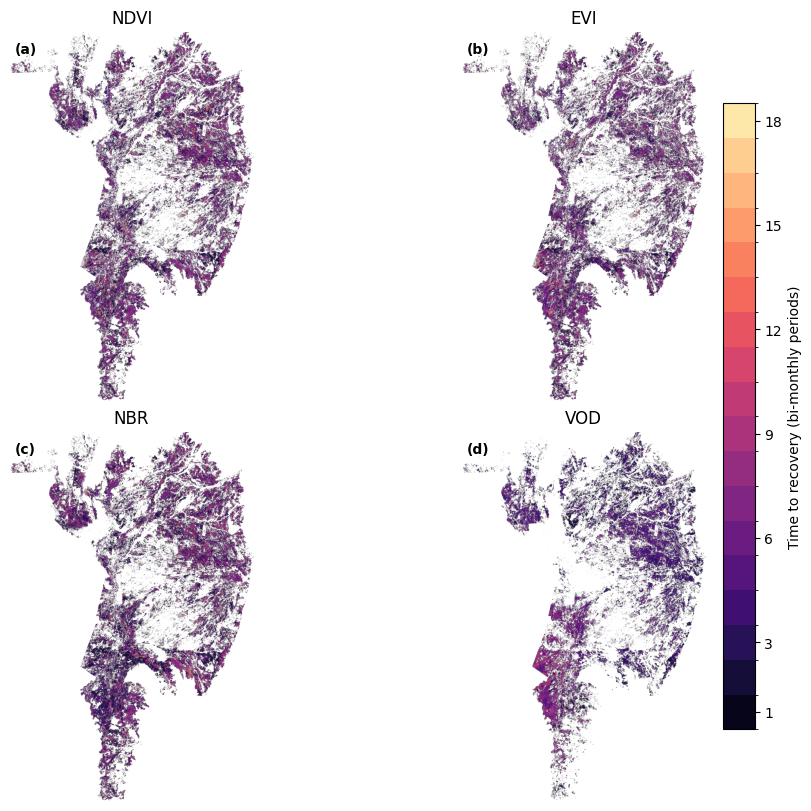

In [ ]:
# @title R3-8 — Mapas comparativos de TTR (NDVI, EVI, NBR e VOD)

import numpy as np
import rasterio as rio
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap, BoundaryNorm

# =========================================================
# MÉTRICAS E ARQUIVOS
# =========================================================

METRICS = ["NDVI", "EVI", "NBR", "VOD"]

TTR_FILES = {
    metric: (
        REC_DIR /
        f"ttr_time_{metric}_bimestres.tif"
    )
    for metric in METRICS
}

for metric, fp in TTR_FILES.items():

    assert fp.exists(), (
        f"TTR corrigido não encontrado para "
        f"{metric}: {fp}"
    )


# =========================================================
# LEITURA
# =========================================================

TTR = {}

for metric, fp in TTR_FILES.items():

    with rio.open(fp) as ds:

        a = ds.read(1).astype(
            "float32"
        )

        nod = ds.nodata

    if nod is not None:

        try:
            if np.isfinite(nod):
                a[a == nod] = np.nan
        except Exception:
            pass

    # guard-rail:
    # TTR válido somente de 1 a 18 bimestres
    a[
        (~np.isfinite(a))
        | (a < 1)
        | (a > 18)
    ] = np.nan

    TTR[metric] = a

    print(
        f"{metric}: "
        f"{np.isfinite(a).sum():,} "
        "pixels com TTR"
    )


# =========================================================
# ESCALA DISCRETA 1–18
# =========================================================

ttr_colors = plt.cm.magma(
    np.linspace(
        0.05,
        0.95,
        18
    )
)

cmap_ttr = ListedColormap(
    ttr_colors
)

norm_ttr = BoundaryNorm(
    np.arange(
        0.5,
        19.5,
        1
    ),
    cmap_ttr.N
)


# =========================================================
# FIGURA 2×2
# =========================================================

fig, axs = plt.subplots(
    2,
    2,
    figsize=(10, 8),
    constrained_layout=True
)

axs = axs.ravel()

letters = [
    "(a)",
    "(b)",
    "(c)",
    "(d)"
]

for ax, metric, letter in zip(
    axs,
    METRICS,
    letters
):

    A = TTR[metric]

    im = ax.imshow(
        A,
        cmap=cmap_ttr,
        norm=norm_ttr
    )

    ax.set_title(
        metric
    )

    ax.axis(
        "off"
    )

    ax.text(
        0.02,
        0.97,
        letter,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontweight="bold"
    )


# =========================================================
# UMA ÚNICA COLORBAR PARA TODOS OS PAINÉIS
# =========================================================

cb = fig.colorbar(
    im,
    ax=axs.tolist(),
    fraction=0.035,
    pad=0.02,
    ticks=[
        1,
        3,
        6,
        9,
        12,
        15,
        18
    ]
)

cb.set_label(
    "Time to recovery (bi-monthly periods)"
)


# =========================================================
# SALVAR
# =========================================================

OUT_FIG = (
    REC_DIR /
    "fig_ttr_maps_2x2_corrected.png"
)

fig.savefig(
    OUT_FIG,
    dpi=300,
    bbox_inches="tight"
)

print(
    "\n✔ Figura salva em:",
    OUT_FIG
)

plt.show()


NDVI: 747,159 pixels com TTR | mediana = 7.0
EVI: 706,760 pixels com TTR | mediana = 6.0
NBR: 781,337 pixels com TTR | mediana = 6.0
VOD: 565,359 pixels com TTR | mediana = 4.0

✔ Figura salva em: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/recovery_nb3_corrected/fig_ttr_maps_1x4_corrected.png


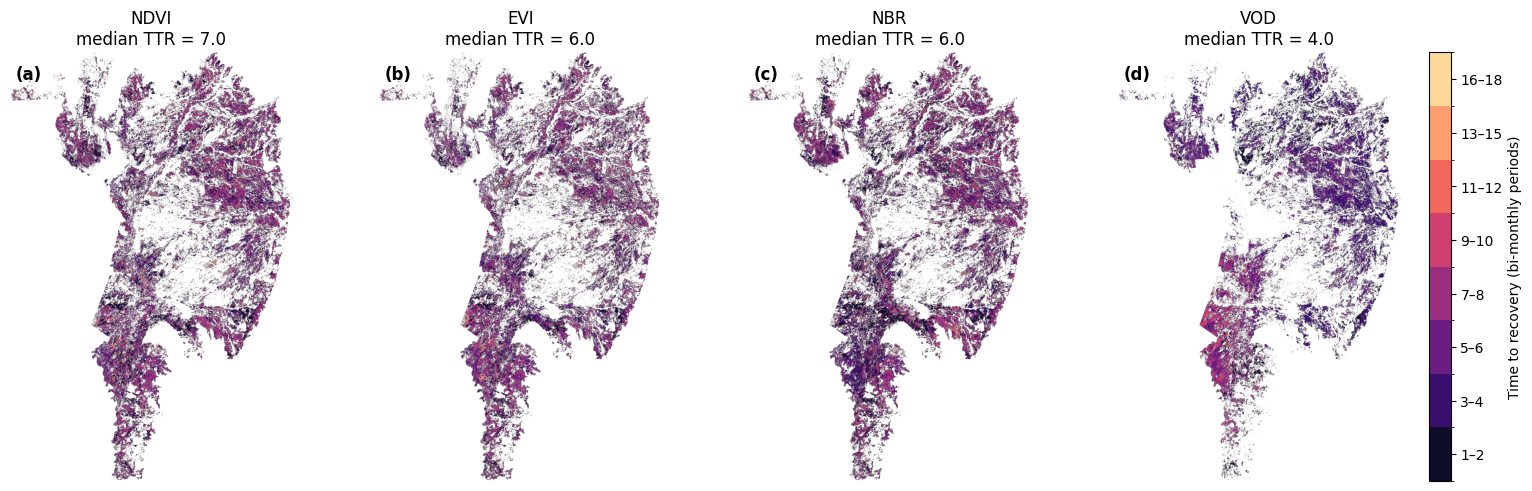

In [ ]:
# @title R3-8 — Mapas comparativos de TTR (1×4, classes discretas)

import numpy as np
import rasterio as rio
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap, BoundaryNorm

# =========================================================
# MÉTRICAS E ARQUIVOS
# =========================================================

METRICS = ["NDVI", "EVI", "NBR", "VOD"]

TTR_FILES = {
    metric: REC_DIR / f"ttr_time_{metric}_bimestres.tif"
    for metric in METRICS
}

for metric, fp in TTR_FILES.items():
    assert fp.exists(), f"TTR corrigido não encontrado para {metric}: {fp}"

# =========================================================
# LEITURA
# =========================================================

TTR = {}
summary = []

for metric, fp in TTR_FILES.items():
    with rio.open(fp) as ds:
        a = ds.read(1).astype("float32")
        nod = ds.nodata

    if nod is not None:
        try:
            if np.isfinite(nod):
                a[a == nod] = np.nan
        except Exception:
            pass

    # TTR válido somente entre 1 e 18
    a[(~np.isfinite(a)) | (a < 1) | (a > 18)] = np.nan

    TTR[metric] = a

    n = int(np.isfinite(a).sum())
    med = float(np.nanmedian(a)) if n > 0 else np.nan

    summary.append({
        "metric": metric,
        "n_recovered": n,
        "median_ttr": med
    })

    print(f"{metric}: {n:,} pixels com TTR | mediana = {med:.1f}")

# =========================================================
# ESCALA DISCRETA AGRUPADA
# =========================================================
# classes:
# 1–2 | 3–4 | 5–6 | 7–8 | 9–10 | 11–12 | 13–15 | 16–18

bounds = [0.5, 2.5, 4.5, 6.5, 8.5, 10.5, 12.5, 15.5, 18.5]
labels = ["1–2", "3–4", "5–6", "7–8", "9–10", "11–12", "13–15", "16–18"]

colors = plt.cm.magma(np.linspace(0.08, 0.92, len(labels)))
cmap_ttr = ListedColormap(colors)
norm_ttr = BoundaryNorm(bounds, cmap_ttr.N)

# =========================================================
# FIGURA 1×4
# =========================================================

fig, axs = plt.subplots(
    1, 4,
    figsize=(16, 4.8),
    constrained_layout=True
)

letters = ["(a)", "(b)", "(c)", "(d)"]

for ax, metric, letter in zip(axs, METRICS, letters):
    A = TTR[metric]

    im = ax.imshow(A, cmap=cmap_ttr, norm=norm_ttr)

    med = np.nanmedian(A) if np.isfinite(A).sum() > 0 else np.nan

    ax.set_title(f"{metric}\nmedian TTR = {med:.1f}")
    ax.axis("off")

    ax.text(
        0.02, 0.97, letter,
        transform=ax.transAxes,
        ha="left", va="top",
        fontweight="bold",
        fontsize=12
    )

# =========================================================
# COLORBAR ÚNICA
# =========================================================

cb = fig.colorbar(
    im,
    ax=axs.tolist(),
    fraction=0.03,
    pad=0.02,
    ticks=[(bounds[i] + bounds[i+1]) / 2 for i in range(len(bounds)-1)]
)

cb.ax.set_yticklabels(labels)
cb.set_label("Time to recovery (bi-monthly periods)")

# =========================================================
# SALVAR
# =========================================================

OUT_FIG = REC_DIR / "fig_ttr_maps_1x4_corrected.png"

fig.savefig(
    OUT_FIG,
    dpi=300,
    bbox_inches="tight"
)

print("\n✔ Figura salva em:", OUT_FIG)

plt.show()

VOD: N=565,359 | median=4.00 | p25=3.00 | p75=6.00
NDVI: N=747,159 | median=7.00 | p25=3.00 | p75=7.00
EVI: N=706,760 | median=6.00 | p25=3.00 | p75=7.00
NBR: N=781,337 | median=6.00 | p25=3.00 | p75=8.00

✔ Figura salva em: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/recovery_nb3_corrected/fig_ttr_distribution_cumulative_corrected.png


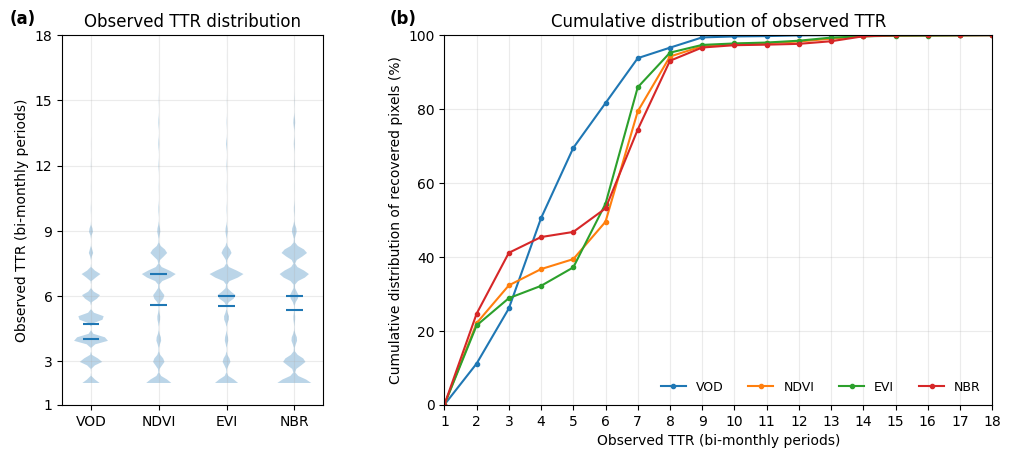

In [ ]:
# @title R3-9 — Distribuição do TTR observado e curva cumulativa

import numpy as np
import rasterio as rio
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# =========================================================
# MÉTRICAS
# =========================================================

METRICS = ["VOD", "NDVI", "EVI", "NBR"]

TTR_FILES = {
    metric: (
        REC_DIR /
        f"ttr_time_{metric}_bimestres.tif"
    )
    for metric in METRICS
}

for metric, fp in TTR_FILES.items():
    assert fp.exists(), (
        f"TTR corrigido não encontrado para {metric}: {fp}"
    )


# =========================================================
# LEITURA
#
# IMPORTANTE:
# ttr_time contém apenas pixels que atingiram o limiar.
# Status 2 e 3 permanecem fora desta distribuição.
# =========================================================

def read_ttr_values(fp):

    with rio.open(fp) as ds:
        a = ds.read(1).astype("float32")
        nod = ds.nodata

    if nod is not None:
        try:
            if np.isfinite(nod):
                a[a == nod] = np.nan
        except Exception:
            pass

    v = a[np.isfinite(a)]

    # guard-rail
    v = v[
        (v >= 1) &
        (v <= 18)
    ]

    return v


vals = {
    metric: read_ttr_values(fp)
    for metric, fp in TTR_FILES.items()
}


for metric in METRICS:

    v = vals[metric]

    print(
        f"{metric}: "
        f"N={v.size:,} | "
        f"median={np.median(v):.2f} | "
        f"p25={np.percentile(v,25):.2f} | "
        f"p75={np.percentile(v,75):.2f}"
        if v.size
        else f"{metric}: sem TTR válido"
    )


# =========================================================
# DISTRIBUIÇÃO CUMULATIVA DO TTR OBSERVADO
# =========================================================

tau = np.arange(
    1,
    19
)

cdf = {}

for metric in METRICS:

    v = vals[metric]

    if v.size == 0:

        cdf[metric] = np.full(
            18,
            np.nan
        )

        continue

    cdf[metric] = np.array(
        [
            100.0 *
            np.mean(v <= t)
            for t in tau
        ]
    )


# =========================================================
# FIGURA
# =========================================================

fig = plt.figure(
    figsize=(12, 4.8)
)

gs = GridSpec(
    nrows=1,
    ncols=2,
    width_ratios=[1, 2.1],
    wspace=0.30
)


# ---------------------------------------------------------
# (a) Distribuição do TTR entre pixels recuperados
# ---------------------------------------------------------

axA = fig.add_subplot(
    gs[0, 0]
)

data = [
    vals[m]
    for m in METRICS
]

parts = axA.violinplot(
    data,
    showmeans=True,
    showmedians=True,
    showextrema=False
)

axA.set_xticks(
    range(
        1,
        len(METRICS)+1
    )
)

axA.set_xticklabels(
    METRICS
)

axA.set_ylabel(
    "Observed TTR (bi-monthly periods)"
)

axA.set_ylim(
    1,
    18
)

axA.set_yticks(
    [1, 3, 6, 9, 12, 15, 18]
)

axA.grid(
    alpha=0.25
)

axA.set_title(
    "Observed TTR distribution"
)

axA.text(
    -0.10,
    1.02,
    "(a)",
    transform=axA.transAxes,
    ha="right",
    va="bottom",
    fontsize=12,
    fontweight="bold"
)


# ---------------------------------------------------------
# (b) Distribuição cumulativa do TTR observado
# ---------------------------------------------------------

axB = fig.add_subplot(
    gs[0, 1]
)

for metric in METRICS:

    axB.plot(
        tau,
        cdf[metric],
        marker="o",
        markersize=3,
        linewidth=1.5,
        label=metric
    )


axB.set_xlim(
    1,
    18
)

axB.set_ylim(
    0,
    100
)

axB.set_xticks(
    tau
)

axB.set_xlabel(
    "Observed TTR (bi-monthly periods)"
)

axB.set_ylabel(
    "Cumulative distribution of recovered pixels (%)"
)

axB.grid(
    alpha=0.25
)

axB.legend(
    ncol=4,
    frameon=False,
    fontsize=9,
    loc="lower right"
)

axB.set_title(
    "Cumulative distribution of observed TTR"
)

axB.text(
    -0.05,
    1.02,
    "(b)",
    transform=axB.transAxes,
    ha="right",
    va="bottom",
    fontsize=12,
    fontweight="bold"
)


# =========================================================
# SALVAR
# =========================================================

OUT_FIG = (
    REC_DIR /
    "fig_ttr_distribution_cumulative_corrected.png"
)

fig.savefig(
    OUT_FIG,
    dpi=300,
    bbox_inches="tight"
)

print(
    "\n✔ Figura salva em:",
    OUT_FIG
)

plt.show()



In [ ]:
# @title R3-10 — Setup das comparações entre TTR óptico e VOD

import numpy as np
import rasterio as rio

METRICS_ALL = ["VOD", "NDVI", "EVI", "NBR"]

# ---------------------------------------------------------
# Arquivos corrigidos
# ---------------------------------------------------------

TTR_FILES = {
    m: REC_DIR / f"ttr_time_{m}_bimestres.tif"
    for m in METRICS_ALL
}

STATUS_FILES = {
    m: REC_DIR / f"ttr_status_{m}.tif"
    for m in METRICS_ALL
}

for m in METRICS_ALL:
    assert TTR_FILES[m].exists(), f"Falta TTR {m}: {TTR_FILES[m]}"
    assert STATUS_FILES[m].exists(), f"Falta status {m}: {STATUS_FILES[m]}"

# ---------------------------------------------------------
# Leitura
# ---------------------------------------------------------

ARR_TTR = {}
ARR_STATUS = {}

for m in METRICS_ALL:

    with rio.open(TTR_FILES[m]) as ds:
        ttr = ds.read(1).astype("float32")

    with rio.open(STATUS_FILES[m]) as ds:
        status = ds.read(1).astype("uint8")

    ttr[(ttr < 1) | (ttr > 18)] = np.nan
    ttr[~MASK] = np.nan
    status[~MASK] = 0

    ARR_TTR[m] = ttr
    ARR_STATUS[m] = status

    print(
        f"{m}: "
        f"recovered={np.sum(status == 1):,} | "
        f"<90%={np.sum(status == 2):,} | "
        f"no-post={np.sum(status == 3):,}"
    )

print("\n✔ Comparações usarão exclusivamente os produtos TTR corrigidos.")


VOD: recovered=877,265 | <90%=5,744 | no-post=7,585
NDVI: recovered=876,268 | <90%=12,074 | no-post=8,183
EVI: recovered=871,927 | <90%=16,415 | no-post=8,183
NBR: recovered=857,770 | <90%=30,569 | no-post=8,183

✔ Comparações usarão exclusivamente os produtos TTR corrigidos.


In [ ]:
# @title R3-11 — Diferenças de TTR: índice óptico − VOD

import numpy as np
import pandas as pd
import rasterio as rio

OPTICAL_METRICS = ["NDVI", "EVI", "NBR"]

summary_rows = []

for metric in OPTICAL_METRICS:

    vod = ARR_TTR["VOD"]
    idx = ARR_TTR[metric]

    # comparar apenas pixels recuperados nos dois indicadores
    both_recovered = (
        (ARR_STATUS["VOD"] == 1) &
        (ARR_STATUS[metric] == 1) &
        np.isfinite(vod) &
        np.isfinite(idx)
    )

    diff = np.full(
        vod.shape,
        np.nan,
        dtype="float32"
    )

    # >0 = índice óptico recuperou depois do VOD
    # <0 = índice óptico recuperou antes do VOD
    diff[both_recovered] = (
        idx[both_recovered] -
        vod[both_recovered]
    )

    # -----------------------------------------
    # salvar raster
    # -----------------------------------------
    out_fp = (
        COMPARE_DIR /
        f"diff_{metric}_minus_VOD_bimestres.tif"
    )

    save_f32(
        out_fp,
        diff
    )

    # -----------------------------------------
    # resumo
    # -----------------------------------------
    vals = diff[
        np.isfinite(diff)
    ]

    summary_rows.append({
        "metric": metric,
        "N": int(vals.size),
        "mean": float(np.mean(vals)) if vals.size else np.nan,
        "std": float(np.std(vals)) if vals.size else np.nan,
        "p25": float(np.percentile(vals, 25)) if vals.size else np.nan,
        "median": float(np.median(vals)) if vals.size else np.nan,
        "p75": float(np.percentile(vals, 75)) if vals.size else np.nan,
        "min": float(np.min(vals)) if vals.size else np.nan,
        "max": float(np.max(vals)) if vals.size else np.nan,
        "pct_optical_faster": (
            100 * np.mean(vals < 0)
            if vals.size else np.nan
        ),
        "pct_same_ttr": (
            100 * np.mean(vals == 0)
            if vals.size else np.nan
        ),
        "pct_optical_slower": (
            100 * np.mean(vals > 0)
            if vals.size else np.nan
        )
    })

    print(
        f"✔ {metric} − VOD: "
        f"N={vals.size:,}"
    )

# -----------------------------------------
# CSV
# -----------------------------------------
df_diff = pd.DataFrame(
    summary_rows
)

OUT_CSV = (
    COMPARE_DIR /
    "summary_diffs_vs_VOD_corrected.csv"
)

df_diff.to_csv(
    OUT_CSV,
    index=False
)

display(
    df_diff.round(3)
)

print(
    "\n✔ Diferenças salvas em:",
    COMPARE_DIR
)



✔ NDVI − VOD: N=866,134
✔ EVI − VOD: N=861,780
✔ NBR − VOD: N=849,934


,metric,N,mean,std,p25,median,p75,min,max,pct_optical_faster,pct_same_ttr,pct_optical_slower
0,NDVI,866134,0.800,1.593,0.0,1.0,1.0,-7.0,17.0,6.908,39.864,53.228
1,EVI,861780,0.801,1.751,0.0,0.0,1.0,-7.0,17.0,6.391,47.817,45.791
2,NBR,849934,1.142,1.830,0.0,1.0,2.0,-8.0,17.0,6.023,25.888,68.090



✔ Diferenças salvas em: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/compare_nb3_corrected


✔ Figura salva em: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/compare_nb3_corrected/fig_ttr_difference_indices_vs_VOD_corrected.png
Negative values: optical index recovered earlier than VOD.
Positive values: optical index recovered later than VOD.


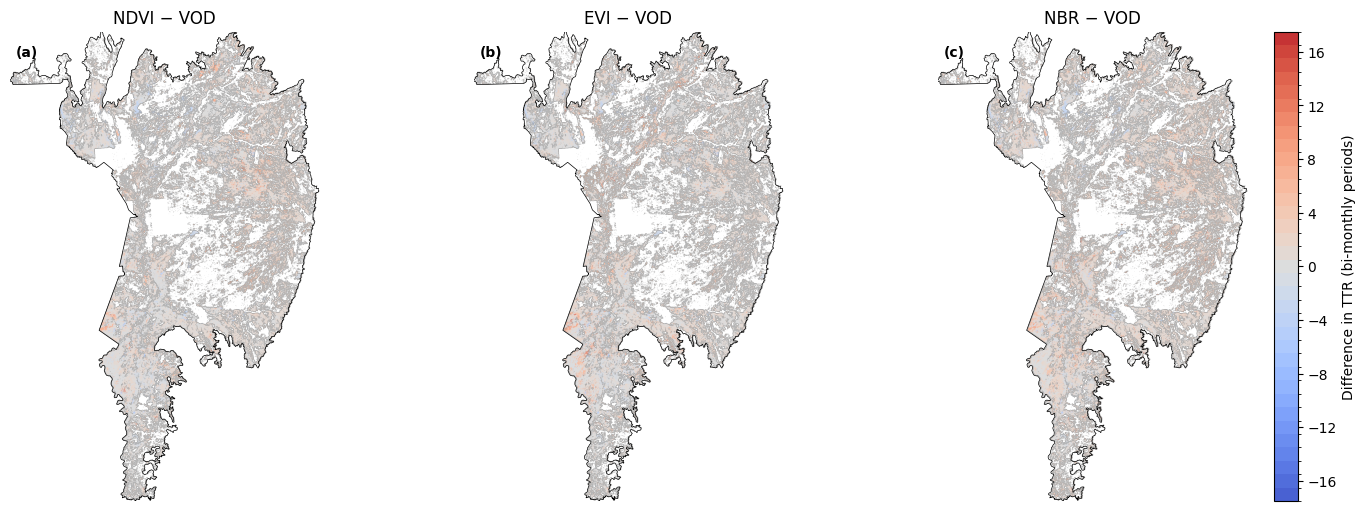

In [ ]:
# @title R3-12 — Mapas das diferenças de TTR: índice óptico − VOD

import numpy as np
import rasterio as rio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

OPTICAL_METRICS = ["NDVI", "EVI", "NBR"]

# =========================================================
# LEITURA
# =========================================================

DIFF = {}

for metric in OPTICAL_METRICS:

    fp = (
        COMPARE_DIR /
        f"diff_{metric}_minus_VOD_bimestres.tif"
    )

    assert fp.exists(), (
        f"Arquivo não encontrado: {fp}"
    )

    with rio.open(fp) as ds:
        A = ds.read(1).astype("float32")

    A[~MASK] = np.nan

    DIFF[metric] = A


# =========================================================
# ESCALA DISCRETA COMUM
#
# TTR ∈ [1,18]
# diferença ∈ [-17,+17]
#
# negativo = óptico recuperou antes do VOD
# positivo = óptico recuperou depois do VOD
# =========================================================

levels = np.arange(-17, 18, 1)

colors = plt.cm.coolwarm(
    np.linspace(0.05, 0.95, len(levels))
)

cmap = ListedColormap(colors)

norm = BoundaryNorm(
    np.arange(-17.5, 18.5, 1),
    cmap.N
)


# =========================================================
# EXTENT
# =========================================================

xmin = TF.c
ymax = TF.f
xmax = xmin + W * TF.a
ymin = ymax + H * TF.e

extent = (
    xmin,
    xmax,
    ymin,
    ymax
)


# =========================================================
# FIGURA
# =========================================================

fig, axs = plt.subplots(
    1,
    3,
    figsize=(15, 5),
    constrained_layout=True
)

letters = ["(a)", "(b)", "(c)"]

for ax, metric, letter in zip(
    axs,
    OPTICAL_METRICS,
    letters
):

    im = ax.imshow(
        DIFF[metric],
        cmap=cmap,
        norm=norm,
        extent=extent,
        origin="upper"
    )

    gdf.boundary.plot(
        ax=ax,
        edgecolor="black",
        linewidth=0.5
    )

    ax.set_title(
        f"{metric} − VOD"
    )

    ax.axis("off")

    ax.text(
        0.02,
        0.97,
        letter,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontweight="bold"
    )


# =========================================================
# COLORBAR ÚNICA
# =========================================================

cb = fig.colorbar(
    im,
    ax=axs.tolist(),
    fraction=0.035,
    pad=0.02,
    ticks=[-16, -12, -8, -4, 0, 4, 8, 12, 16]
)

cb.set_label(
    "Difference in TTR (bi-monthly periods)"
)


# =========================================================
# SALVAR
# =========================================================

OUT_FIG = (
    COMPARE_DIR /
    "fig_ttr_difference_indices_vs_VOD_corrected.png"
)

fig.savefig(
    OUT_FIG,
    dpi=300,
    bbox_inches="tight"
)

print(
    "✔ Figura salva em:",
    OUT_FIG
)

print(
    "Negative values: optical index recovered earlier than VOD."
)

print(
    "Positive values: optical index recovered later than VOD."
)

plt.show()


In [ ]:
# @title R3-13 — Classes Lead/Lag do TTR em relação ao VOD

import numpy as np
import pandas as pd
import rasterio as rio

OPTICAL_METRICS = ["NDVI", "EVI", "NBR"]

# =========================================================
# PERFIL CATEGÓRICO
# -1 = óptico mais rápido
#  0 = mesmo TTR
# +1 = óptico mais lento
# -99 = NoData
# =========================================================

with rio.open(REF_FP) as ref:
    PROFILE_I8 = ref.meta.copy()

PROFILE_I8.update(
    count=1,
    dtype="int8",
    nodata=-99,
    compress="lzw",
    tiled=True,
    blockxsize=512,
    blockysize=512,
    BIGTIFF="IF_SAFER"
)

summary_rows = []

for metric in OPTICAL_METRICS:

    diff_fp = (
        COMPARE_DIR /
        f"diff_{metric}_minus_VOD_bimestres.tif"
    )

    assert diff_fp.exists(), f"Falta: {diff_fp}"

    with rio.open(diff_fp) as ds:
        D = ds.read(1).astype("float32")

    valid = np.isfinite(D) & MASK

    # raster categórico
    C = np.full(
        D.shape,
        -99,
        dtype="int8"
    )

    C[valid & (D < 0)] = -1
    C[valid & (D == 0)] = 0
    C[valid & (D > 0)] = 1

    # salvar
    out_fp = (
        COMPARE_DIR /
        f"leadlag_{metric}_vs_VOD.tif"
    )

    with rio.open(
        out_fp,
        "w",
        **PROFILE_I8
    ) as dst:
        dst.write(C, 1)

    v = D[valid]

    summary_rows.append({
        "metric": metric,
        "N": int(v.size),
        "pct_optical_faster": (
            100 * np.mean(v < 0)
            if v.size else np.nan
        ),
        "pct_same_ttr": (
            100 * np.mean(v == 0)
            if v.size else np.nan
        ),
        "pct_optical_slower": (
            100 * np.mean(v > 0)
            if v.size else np.nan
        ),
        "median_difference": (
            float(np.median(v))
            if v.size else np.nan
        ),
        "p25": (
            float(np.percentile(v, 25))
            if v.size else np.nan
        ),
        "p75": (
            float(np.percentile(v, 75))
            if v.size else np.nan
        )
    })

    print(
        f"✔ {metric}: "
        f"{v.size:,} pixels comparáveis"
    )

# =========================================================
# CSV
# =========================================================

df_leadlag = pd.DataFrame(
    summary_rows
)

OUT_CSV = (
    COMPARE_DIR /
    "lead_lag_summary_vs_VOD_corrected.csv"
)

df_leadlag.to_csv(
    OUT_CSV,
    index=False
)

display(
    df_leadlag.round(3)
)

print(
    "\n✔ Lead/Lag salvo em:",
    COMPARE_DIR
)

✔ NDVI: 866,134 pixels comparáveis
✔ EVI: 861,780 pixels comparáveis
✔ NBR: 849,934 pixels comparáveis


,metric,N,pct_optical_faster,pct_same_ttr,pct_optical_slower,median_difference,p25,p75
0,NDVI,866134,6.908,39.864,53.228,1.0,0.0,1.0
1,EVI,861780,6.391,47.817,45.791,0.0,0.0,1.0
2,NBR,849934,6.023,25.888,68.090,1.0,0.0,2.0



✔ Lead/Lag salvo em: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/compare_nb3_corrected


✔ Figura: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/compare_nb3/lead_lag_classes_indices_vs_VOD.png


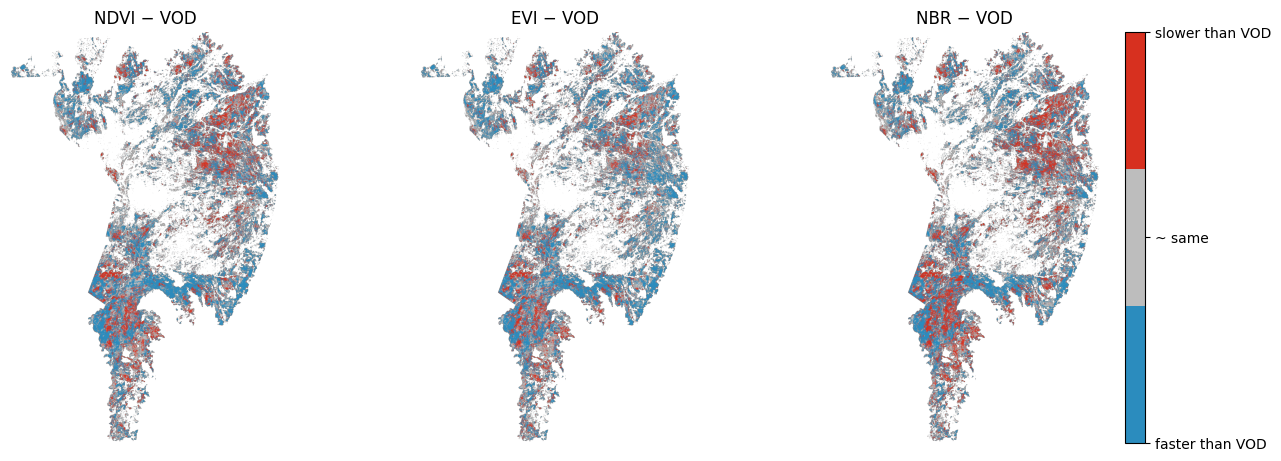

In [ ]:
# @title R3-14 — Mapa Lead/Lag em relação ao VOD

import numpy as np
import rasterio as rio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

OPTICAL_METRICS = ["NDVI", "EVI", "NBR"]

# =========================================================
# CORES E CLASSES
# =========================================================

cmap = ListedColormap([
    "#2166ac",  # -1 = optical faster
    "#bdbdbd",  #  0 = same TTR
    "#b2182b"   # +1 = optical slower
])

norm = BoundaryNorm(
    [-1.5, -0.5, 0.5, 1.5],
    cmap.N
)

# =========================================================
# FIGURA
# =========================================================

fig, axs = plt.subplots(
    1,
    3,
    figsize=(14, 4.8),
    constrained_layout=True
)

letters = ["(a)", "(b)", "(c)"]

for ax, metric, letter in zip(
    axs,
    OPTICAL_METRICS,
    letters
):

    fp = (
        COMPARE_DIR /
        f"leadlag_{metric}_vs_VOD.tif"
    )

    assert fp.exists(), f"Falta: {fp}"

    with rio.open(fp) as ds:
        C = ds.read(1).astype("float32")

    # NoData = -99
    C[C == -99] = np.nan
    C[~MASK] = np.nan

    im = ax.imshow(
        C,
        cmap=cmap,
        norm=norm
    )

    ax.set_title(
        f"{metric} vs VOD"
    )

    ax.axis("off")

    ax.text(
        0.02,
        0.97,
        letter,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontweight="bold"
    )

# =========================================================
# COLORBAR ÚNICA
# =========================================================

cb = fig.colorbar(
    im,
    ax=axs.tolist(),
    fraction=0.035,
    pad=0.02,
    ticks=[-1, 0, 1]
)

cb.ax.set_yticklabels([
    "Optical faster",
    "Same TTR",
    "Optical slower"
])

cb.set_label(
    "Recovery timing relative to VOD"
)

# =========================================================
# SALVAR
# =========================================================

OUT_FIG = (
    COMPARE_DIR /
    "fig_lead_lag_indices_vs_VOD_corrected.png"
)

fig.savefig(
    OUT_FIG,
    dpi=300,
    bbox_inches="tight"
)

print(
    "✔ Figura salva em:",
    OUT_FIG
)

plt.show()


✔ NDVI: N=881,413 | consistência=87.8%
✔ EVI: N=881,413 | consistência=86.5%
✔ NBR: N=881,413 | consistência=87.5%

✔ Figura salva em: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/compare_nb3_corrected/fig_consistency_signDelta_vs_VOD_corrected.png


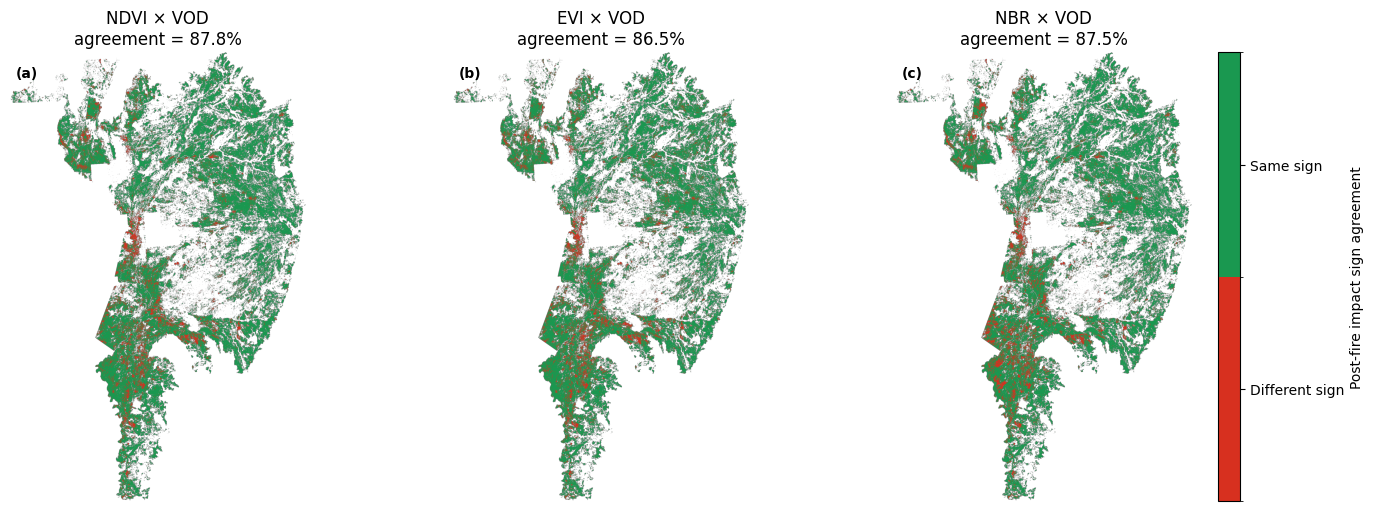

In [ ]:
# @title R3-15 — Consistência do sinal do impacto: índice óptico × VOD

import numpy as np
import pandas as pd
import rasterio as rio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

OPTICAL_METRICS = ["NDVI", "EVI", "NBR"]

# pequena tolerância apenas para evitar ruído numérico em torno de zero
EPS_SIGN = 1e-6

# =========================================================
# FUNÇÃO DE SINAL
# -1 = impacto negativo
#  0 = aproximadamente zero
# +1 = impacto positivo
# =========================================================

def impact_sign(A):

    S = np.zeros(
        A.shape,
        dtype="int8"
    )

    S[A >  EPS_SIGN] =  1
    S[A < -EPS_SIGN] = -1

    return S


# =========================================================
# VOD
# =========================================================

vod_fp = REC_DIR / "p2_delta_VOD.tif"

assert vod_fp.exists(), f"Falta: {vod_fp}"

with rio.open(vod_fp) as ds:
    D_vod = ds.read(1).astype("float32")


# =========================================================
# COMPARAÇÃO
# =========================================================

summary = []
CONSISTENCY = {}

for metric in OPTICAL_METRICS:

    idx_fp = (
        REC_DIR /
        f"p2_delta_{metric}.tif"
    )

    assert idx_fp.exists(), f"Falta: {idx_fp}"

    with rio.open(idx_fp) as ds:
        D_idx = ds.read(1).astype("float32")

    valid = (
        MASK &
        np.isfinite(D_idx) &
        np.isfinite(D_vod)
    )

    S_idx = impact_sign(D_idx)
    S_vod = impact_sign(D_vod)

    # 1 = mesmo sinal
    # 0 = sinais diferentes
    C = np.full(
        D_idx.shape,
        np.nan,
        dtype="float32"
    )

    C[valid] = (
        S_idx[valid] ==
        S_vod[valid]
    ).astype("float32")

    CONSISTENCY[metric] = C

    # salvar raster
    out_fp = (
        COMPARE_DIR /
        f"consistency_signDelta_{metric}_with_VOD.tif"
    )

    save_f32(
        out_fp,
        C
    )

    v = C[np.isfinite(C)]

    consistency_pct = (
        100 * float(np.mean(v))
        if v.size else np.nan
    )

    summary.append({
        "metric": metric,
        "N": int(v.size),
        "consistency_percent": consistency_pct
    })

    print(
        f"✔ {metric}: "
        f"N={v.size:,} | "
        f"consistência={consistency_pct:.1f}%"
    )


# =========================================================
# CSV
# =========================================================

df_consistency = pd.DataFrame(
    summary
)

df_consistency.to_csv(
    COMPARE_DIR /
    "consistency_signDelta_vs_VOD_corrected.csv",
    index=False
)


# =========================================================
# FIGURA
# =========================================================

cmap = ListedColormap([
    "#d7301f",  # 0 = diverges
    "#1a9850"   # 1 = agrees
])

norm = BoundaryNorm(
    [-0.5, 0.5, 1.5],
    cmap.N
)

fig, axs = plt.subplots(
    1,
    3,
    figsize=(15, 5),
    constrained_layout=True
)

letters = ["(a)", "(b)", "(c)"]

for ax, metric, letter in zip(
    axs,
    OPTICAL_METRICS,
    letters
):

    A = CONSISTENCY[metric]

    rate = df_consistency.loc[
        df_consistency["metric"] == metric,
        "consistency_percent"
    ].iloc[0]

    im = ax.imshow(
        A,
        cmap=cmap,
        norm=norm
    )

    ax.set_title(
        f"{metric} × VOD\nagreement = {rate:.1f}%"
    )

    ax.axis("off")

    ax.text(
        0.02,
        0.97,
        letter,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontweight="bold"
    )


cb = fig.colorbar(
    im,
    ax=axs.tolist(),
    fraction=0.035,
    pad=0.02,
    ticks=[0, 1]
)

cb.ax.set_yticklabels([
    "Different sign",
    "Same sign"
])

cb.set_label(
    "Post-fire impact sign agreement"
)


OUT_FIG = (
    COMPARE_DIR /
    "fig_consistency_signDelta_vs_VOD_corrected.png"
)

fig.savefig(
    OUT_FIG,
    dpi=300,
    bbox_inches="tight"
)

print(
    "\n✔ Figura salva em:",
    OUT_FIG
)

plt.show()



✔ Figura integrada salva em: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/compare_nb3_corrected/fig_recovery_comparison_3x3_corrected.png


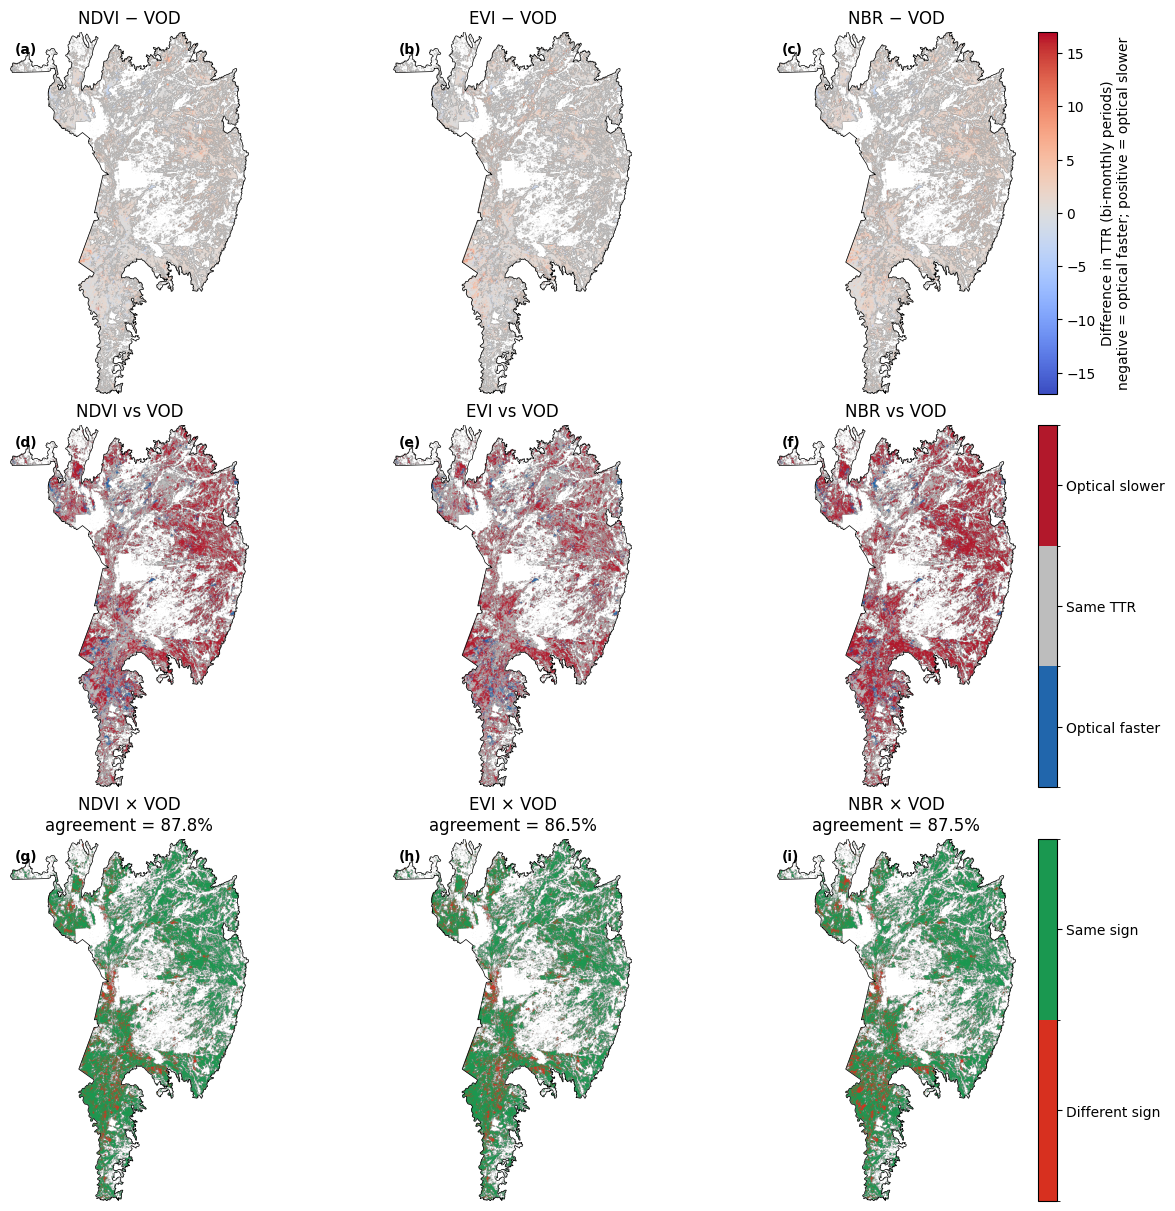

In [ ]:
# @title R3-16 — Figura integrada: diferença de TTR, Lead/Lag e sinal do impacto

import numpy as np
import rasterio as rio
import matplotlib.pyplot as plt

from matplotlib.colors import (
    TwoSlopeNorm,
    ListedColormap,
    BoundaryNorm
)
from matplotlib.cm import ScalarMappable

OPTICAL_METRICS = ["NDVI", "EVI", "NBR"]

# =========================================================
# EXTENT
# =========================================================

xmin = TF.c
ymax = TF.f
xmax = xmin + W * TF.a
ymin = ymax + H * TF.e

extent = (xmin, xmax, ymin, ymax)

# =========================================================
# LEITURA
# =========================================================

DIFF = {}
LEADLAG = {}
CONSIST = {}
CONSIST_PCT = {}

for metric in OPTICAL_METRICS:

    # -------------------------
    # diferença de TTR
    # -------------------------
    fp = (
        COMPARE_DIR /
        f"diff_{metric}_minus_VOD_bimestres.tif"
    )

    assert fp.exists(), f"Falta: {fp}"

    with rio.open(fp) as ds:
        A = ds.read(1).astype("float32")

    A[~MASK] = np.nan
    DIFF[metric] = A

    # -------------------------
    # lead/lag
    # -------------------------
    fp = (
        COMPARE_DIR /
        f"leadlag_{metric}_vs_VOD.tif"
    )

    assert fp.exists(), f"Falta: {fp}"

    with rio.open(fp) as ds:
        A = ds.read(1).astype("float32")

    A[A == -99] = np.nan
    A[~MASK] = np.nan
    LEADLAG[metric] = A

    # -------------------------
    # consistência do sinal Δ
    # -------------------------
    fp = (
        COMPARE_DIR /
        f"consistency_signDelta_{metric}_with_VOD.tif"
    )

    assert fp.exists(), f"Falta: {fp}"

    with rio.open(fp) as ds:
        A = ds.read(1).astype("float32")

    A[~MASK] = np.nan
    CONSIST[metric] = A

    v = A[np.isfinite(A)]

    CONSIST_PCT[metric] = (
        100 * np.mean(v)
        if v.size
        else np.nan
    )

# =========================================================
# ESCALAS
# =========================================================

# Diferença de TTR
norm_diff = TwoSlopeNorm(
    vmin=-17,
    vcenter=0,
    vmax=17
)

cmap_diff = "coolwarm"

# Lead/Lag
cmap_ll = ListedColormap([
    "#2166ac",   # faster
    "#bdbdbd",   # same
    "#b2182b"    # slower
])

norm_ll = BoundaryNorm(
    [-1.5, -0.5, 0.5, 1.5],
    cmap_ll.N
)

# Consistência do sinal
cmap_cs = ListedColormap([
    "#d7301f",   # different
    "#1a9850"    # same
])

norm_cs = BoundaryNorm(
    [-0.5, 0.5, 1.5],
    cmap_cs.N
)

# =========================================================
# FIGURA 3×3
# =========================================================

fig, axes = plt.subplots(
    3,
    3,
    figsize=(13, 12),
    constrained_layout=True
)

letters = [
    "(a)", "(b)", "(c)",
    "(d)", "(e)", "(f)",
    "(g)", "(h)", "(i)"
]

# ---------------------------------------------------------
# Linha 1 — diferença de TTR
# ---------------------------------------------------------

for j, metric in enumerate(OPTICAL_METRICS):

    ax = axes[0, j]

    ax.imshow(
        DIFF[metric],
        norm=norm_diff,
        cmap=cmap_diff,
        extent=extent,
        origin="upper"
    )

    gdf.boundary.plot(
        ax=ax,
        edgecolor="black",
        linewidth=0.5
    )

    ax.set_title(
        f"{metric} − VOD"
    )

    ax.axis("off")

    ax.text(
        0.02,
        0.97,
        letters[j],
        transform=ax.transAxes,
        fontweight="bold",
        va="top"
    )

# ---------------------------------------------------------
# Linha 2 — Lead/Lag
# ---------------------------------------------------------

for j, metric in enumerate(OPTICAL_METRICS):

    ax = axes[1, j]

    ax.imshow(
        LEADLAG[metric],
        cmap=cmap_ll,
        norm=norm_ll,
        extent=extent,
        origin="upper"
    )

    gdf.boundary.plot(
        ax=ax,
        edgecolor="black",
        linewidth=0.5
    )

    ax.set_title(
        f"{metric} vs VOD"
    )

    ax.axis("off")

    ax.text(
        0.02,
        0.97,
        letters[3+j],
        transform=ax.transAxes,
        fontweight="bold",
        va="top"
    )

# ---------------------------------------------------------
# Linha 3 — consistência do sinal do impacto
# ---------------------------------------------------------

for j, metric in enumerate(OPTICAL_METRICS):

    ax = axes[2, j]

    ax.imshow(
        CONSIST[metric],
        cmap=cmap_cs,
        norm=norm_cs,
        extent=extent,
        origin="upper"
    )

    gdf.boundary.plot(
        ax=ax,
        edgecolor="black",
        linewidth=0.5
    )

    ax.set_title(
        f"{metric} × VOD\n"
        f"agreement = {CONSIST_PCT[metric]:.1f}%"
    )

    ax.axis("off")

    ax.text(
        0.02,
        0.97,
        letters[6+j],
        transform=ax.transAxes,
        fontweight="bold",
        va="top"
    )

# =========================================================
# COLORBARS
# =========================================================

cb1 = fig.colorbar(
    ScalarMappable(
        norm=norm_diff,
        cmap=cmap_diff
    ),
    ax=axes[0, :].tolist(),
    fraction=0.035,
    pad=0.02
)

cb1.set_label(
    "Difference in TTR (bi-monthly periods)\n"
    "negative = optical faster; positive = optical slower"
)

cb2 = fig.colorbar(
    ScalarMappable(
        norm=norm_ll,
        cmap=cmap_ll
    ),
    ax=axes[1, :].tolist(),
    fraction=0.035,
    pad=0.02,
    ticks=[-1, 0, 1]
)

cb2.ax.set_yticklabels([
    "Optical faster",
    "Same TTR",
    "Optical slower"
])

cb3 = fig.colorbar(
    ScalarMappable(
        norm=norm_cs,
        cmap=cmap_cs
    ),
    ax=axes[2, :].tolist(),
    fraction=0.035,
    pad=0.02,
    ticks=[0, 1]
)

cb3.ax.set_yticklabels([
    "Different sign",
    "Same sign"
])

# =========================================================
# SALVAR
# =========================================================

OUT_FIG = (
    COMPARE_DIR /
    "fig_recovery_comparison_3x3_corrected.png"
)

fig.savefig(
    OUT_FIG,
    dpi=300,
    bbox_inches="tight"
)

print(
    "✔ Figura integrada salva em:",
    OUT_FIG
)

plt.show()



In [ ]:
# @title R3-17 — Correlação espacial do TTR: índices ópticos × VOD

import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

OPTICAL_METRICS = ["NDVI", "EVI", "NBR"]

rows = []

for metric in OPTICAL_METRICS:

    vod = ARR_TTR["VOD"]
    idx = ARR_TTR[metric]

    # Somente pixels que atingiram o limiar nos dois indicadores
    valid = (
        (ARR_STATUS["VOD"] == 1) &
        (ARR_STATUS[metric] == 1) &
        np.isfinite(vod) &
        np.isfinite(idx)
    )

    x = vod[valid]
    y = idx[valid]

    if x.size < 10:

        pearson_r = np.nan
        spearman_r = np.nan

    else:

        pearson_r = float(
            pearsonr(x, y).statistic
        )

        spearman_r = float(
            spearmanr(x, y).statistic
        )

    rows.append({
        "pair": f"{metric} vs VOD",
        "N": int(x.size),
        "pearson_r": pearson_r,
        "spearman_r": spearman_r
    })


df_corr = pd.DataFrame(rows)

OUT_CSV = (
    COMPARE_DIR /
    "ttr_correlations_vs_VOD_corrected.csv"
)

df_corr.to_csv(
    OUT_CSV,
    index=False
)

display(
    df_corr.round(3)
)

print(
    "✔ Correlações salvas em:",
    OUT_CSV
)


,pair,N,pearson_r,spearman_r
0,NDVI vs VOD,866134,-0.045,-0.007
1,EVI vs VOD,861780,0.051,0.090
2,NBR vs VOD,849934,-0.077,-0.077


✔ Correlações salvas em: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/compare_nb3_corrected/ttr_correlations_vs_VOD_corrected.csv


In [ ]:
# @title R3-18 — Concordância de recuperação óptico × VOD em τ = 6, 12 e 18 bimestres

import math
import numpy as np
import pandas as pd

OPTICAL_METRICS = ["NDVI", "EVI", "NBR"]
TAUS = [6, 12, 18]

# =========================================================
# MÉTRICAS
# =========================================================

def confusion_metrics(TN, FP, FN, TP):

    total = TN + FP + FN + TP

    accuracy = (
        (TP + TN) / total
        if total else np.nan
    )

    precision = (
        TP / (TP + FP)
        if (TP + FP) else np.nan
    )

    recall = (
        TP / (TP + FN)
        if (TP + FN) else np.nan
    )

    f1 = (
        2 * precision * recall / (precision + recall)
        if (
            np.isfinite(precision)
            and np.isfinite(recall)
            and (precision + recall) > 0
        )
        else np.nan
    )

    denom = (
        (TP + FP) *
        (TP + FN) *
        (TN + FP) *
        (TN + FN)
    )

    mcc = (
        ((TP * TN) - (FP * FN)) /
        math.sqrt(denom)
        if denom > 0
        else np.nan
    )

    return accuracy, precision, recall, f1, mcc


# =========================================================
# CLASSIFICAÇÃO EM UM LIMIAR τ
#
# 1 = atingiu 90% do baseline até τ
# 0 = não atingiu até τ
#
# IMPORTANTE:
# só entram pixels com pelo menos τ bimestres de acompanhamento
# disponíveis no calendário após o primeiro fogo.
# =========================================================

def recovery_by_tau(metric, tau):

    ttr = ARR_TTR[metric]
    status = ARR_STATUS[metric]

    # pixel precisa ter tempo cronológico suficiente
    # até o limiar τ após o primeiro fogo
    enough_followup = (
        (first_fire_t >= N_PRE) &
        ((first_fire_t + tau) < len(YMS)) &
        MASK
    )

    out = np.full(
        ttr.shape,
        np.nan,
        dtype="float32"
    )

    # Recuperou e TTR observado <= tau
    recovered_by_tau = (
        enough_followup &
        (status == 1) &
        np.isfinite(ttr) &
        (ttr <= tau)
    )

    # Casos classificáveis como "não recuperou até tau":
    # - recuperou, mas somente depois de tau
    # - não atingiu 90% durante o acompanhamento disponível
    not_recovered_by_tau = (
        enough_followup &
        (
            (
                (status == 1) &
                np.isfinite(ttr) &
                (ttr > tau)
            )
            |
            (status == 2)
        )
    )

    out[recovered_by_tau] = 1
    out[not_recovered_by_tau] = 0

    # status 3 permanece NaN: sem dados pós-fogo válidos

    return out


# =========================================================
# COMPARAÇÕES
# =========================================================

rows = []

for tau in TAUS:

    ref = recovery_by_tau(
        "VOD",
        tau
    )

    for metric in OPTICAL_METRICS:

        pred = recovery_by_tau(
            metric,
            tau
        )

        valid = (
            np.isfinite(ref) &
            np.isfinite(pred)
        )

        r = ref[valid].astype(bool)
        p = pred[valid].astype(bool)

        TP = int(np.sum( r &  p))
        TN = int(np.sum(~r & ~p))
        FP = int(np.sum(~r &  p))
        FN = int(np.sum( r & ~p))

        accuracy, precision, recall, f1, mcc = (
            confusion_metrics(
                TN, FP, FN, TP
            )
        )

        rows.append({
            "index": metric,
            "tau_bimonths": tau,
            "N": int(valid.sum()),
            "TN": TN,
            "FP": FP,
            "FN": FN,
            "TP": TP,
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "F1": f1,
            "MCC": mcc
        })


# =========================================================
# SALVAR
# =========================================================

df_agreement = pd.DataFrame(
    rows
)

OUT_CSV = (
    COMPARE_DIR /
    "agreement_recovery_thresholds_vs_VOD_corrected.csv"
)

df_agreement.to_csv(
    OUT_CSV,
    index=False
)

display(
    df_agreement.round(3)
)

print(
    "✔ Tabela salva em:",
    OUT_CSV
)


,index,tau_bimonths,N,TN,FP,FN,TP,accuracy,precision,recall,F1,MCC
0,NDVI,6,859140,15,579,30950,827596,0.963,0.999,0.964,0.981,-0.002
1,EVI,6,859140,103,491,42664,815882,0.950,0.999,0.950,0.974,0.015
2,NBR,6,859137,4,590,56674,801869,0.933,0.999,0.934,0.966,-0.006
3,NDVI,12,771710,0,0,1999,769711,0.997,1.000,0.997,0.999,NaN
4,EVI,12,771710,0,0,4029,767681,0.995,1.000,0.995,0.997,NaN
5,NBR,12,771707,0,0,6775,764932,0.991,1.000,0.991,0.996,NaN
6,NDVI,18,756551,0,0,594,755957,0.999,1.000,0.999,1.000,NaN
7,EVI,18,756551,0,0,1456,755095,0.998,1.000,0.998,0.999,NaN
8,NBR,18,756548,0,0,2218,754330,0.997,1.000,0.997,0.999,NaN


✔ Tabela salva em: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/compare_nb3_corrected/agreement_recovery_thresholds_vs_VOD_corrected.csv


✔ RdNBR no primeiro evento: 896,312 pixels
RdNBR quartis: Q25=0.0000 | Q50=0.0001 | Q75=0.0001
✔ Figura: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/compare_nb3_corrected/fig_recovery_by_severity_corrected.png
✔ CSV: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/compare_nb3_corrected/severity_recovery_curves_corrected.csv


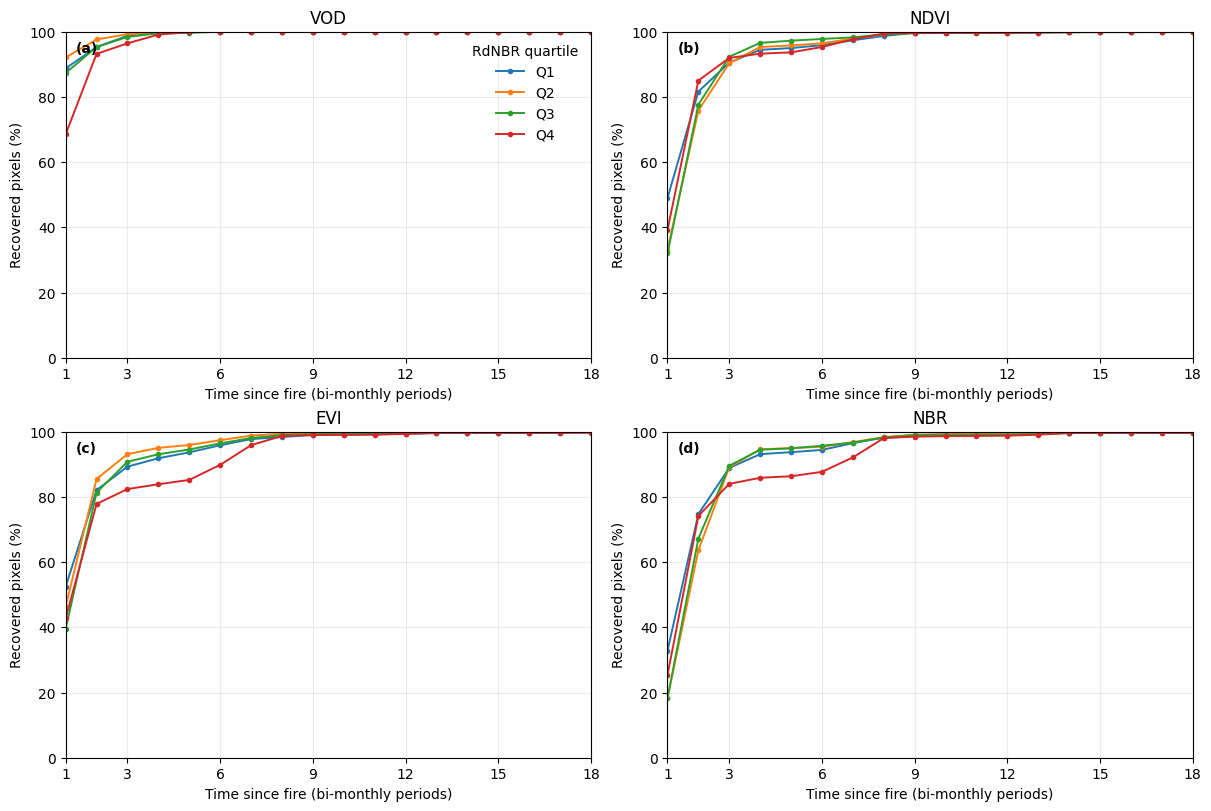

In [ ]:
# @title R3-19 — Severidade por RdNBR no primeiro evento + curvas de recuperação

import numpy as np
import pandas as pd
import rasterio as rio
import matplotlib.pyplot as plt

from pathlib import Path
from rasterio.warp import reproject, Resampling

# =========================================================
# PASTA RdNBR
# =========================================================

F1_DIR = OUT_DIR / "fase1_events_300m"

assert F1_DIR.exists(), (
    f"Pasta RdNBR não encontrada: {F1_DIR}"
)

# =========================================================
# PRIMEIRO FOGO
# =========================================================

FIRST_FIRE_FP = REC_DIR / "first_fire_yyyymm.tif"

if not FIRST_FIRE_FP.exists():
    FIRST_FIRE_FP = LEGACY_REC_DIR / "first_fire_yyyymm.tif"

assert FIRST_FIRE_FP.exists()

with rio.open(FIRST_FIRE_FP) as ds:
    first_fire_ym = ds.read(1).astype("int32")

# =========================================================
# LEITOR RdNBR
#
# Produtos ópticos foram exportados:
# - NoData = -32768
# - escala = ×10000
# =========================================================

RDNBR_SENTINEL = -32768.0
RDNBR_SCALE = 10000.0

def read_rdnbr(ym):

    fp = F1_DIR / f"rdnbr_{ym}.tif"

    if not fp.exists():
        return None

    with rio.open(fp) as src:

        a = src.read(1).astype("float32")

        nod = src.nodata

        if nod is not None:
            try:
                if np.isfinite(nod):
                    a[a == nod] = np.nan
            except Exception:
                pass

        a[a == RDNBR_SENTINEL] = np.nan

        # voltar à escala física
        a = a / RDNBR_SCALE

        same_grid = (
            src.height == H
            and src.width == W
            and str(src.crs) == str(CRS)
            and np.allclose(
                np.array(src.transform)[:6],
                np.array(TF)[:6],
                atol=1e-6
            )
        )

        if same_grid:
            return a

        dst = np.full(
            (H, W),
            np.nan,
            dtype="float32"
        )

        reproject(
            source=a,
            destination=dst,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=TF,
            dst_crs=CRS,
            src_nodata=np.nan,
            dst_nodata=np.nan,
            resampling=Resampling.bilinear
        )

        return dst

# =========================================================
# RdNBR NO PRIMEIRO EVENTO
# =========================================================

R_evt = np.full(
    (H, W),
    np.nan,
    dtype="float32"
)

event_yms = sorted(
    {
        str(int(v))
        for v in first_fire_ym[
            first_fire_ym > 0
        ]
    }
)

for ym in event_yms:

    rdn = read_rdnbr(ym)

    if rdn is None:
        continue

    m = (
        (first_fire_ym == int(ym))
        & MASK
        & np.isfinite(rdn)
    )

    R_evt[m] = rdn[m]

# salvar
RDNBR_EVT_FP = (
    COMPARE_DIR /
    "RDNBR_first_fire_corrected.tif"
)

save_f32(
    RDNBR_EVT_FP,
    R_evt
)

print(
    "✔ RdNBR no primeiro evento:",
    f"{np.isfinite(R_evt).sum():,}",
    "pixels"
)

# =========================================================
# QUARTIS DE SEVERIDADE
#
# IMPORTANTE:
# classes calculadas independentemente do resultado de TTR.
# =========================================================

valid_severity = (
    MASK &
    (first_fire_ym > 0) &
    np.isfinite(R_evt)
)

vals = R_evt[
    valid_severity
]

assert vals.size > 0, (
    "Nenhum RdNBR válido no primeiro evento."
)

q25, q50, q75 = np.percentile(
    vals,
    [25, 50, 75]
)

print(
    f"RdNBR quartis: "
    f"Q25={q25:.4f} | "
    f"Q50={q50:.4f} | "
    f"Q75={q75:.4f}"
)

SEVERITY = {
    "Q1": (
        valid_severity &
        (R_evt <= q25)
    ),
    "Q2": (
        valid_severity &
        (R_evt > q25) &
        (R_evt <= q50)
    ),
    "Q3": (
        valid_severity &
        (R_evt > q50) &
        (R_evt <= q75)
    ),
    "Q4": (
        valid_severity &
        (R_evt > q75)
    )
}

# =========================================================
# CURVAS DE RECUPERAÇÃO
#
# denominador:
# pixels da classe com follow-up cronológico suficiente
# e status avaliável (1 ou 2).
# status 3 = sem dados pós-fogo -> excluído.
# =========================================================

TAUS = np.arange(1, 19)

curve_rows = []

for metric in ["VOD", "NDVI", "EVI", "NBR"]:

    ttr = ARR_TTR[metric]
    status = ARR_STATUS[metric]

    for sev_name, sev_mask in SEVERITY.items():

        for tau in TAUS:

            enough_followup = (
                (first_fire_t >= N_PRE) &
                ((first_fire_t + tau) < len(YMS))
            )

            evaluable = (
                sev_mask &
                enough_followup &
                (
                    (status == 1) |
                    (status == 2)
                )
            )

            n = int(
                evaluable.sum()
            )

            recovered = (
                evaluable &
                (status == 1) &
                np.isfinite(ttr) &
                (ttr <= tau)
            )

            pct = (
                100.0 *
                recovered.sum() /
                n
                if n > 0
                else np.nan
            )

            curve_rows.append({
                "metric": metric,
                "severity_class": sev_name,
                "tau_bimonths": int(tau),
                "N_evaluable": n,
                "recovered_pct": pct
            })

df_severity = pd.DataFrame(
    curve_rows
)

OUT_CSV = (
    COMPARE_DIR /
    "severity_recovery_curves_corrected.csv"
)

df_severity.to_csv(
    OUT_CSV,
    index=False
)

# =========================================================
# FIGURA 2×2
# =========================================================

fig, axs = plt.subplots(
    2,
    2,
    figsize=(12, 8),
    constrained_layout=True
)

axs = axs.ravel()

metrics = ["VOD", "NDVI", "EVI", "NBR"]

letters = ["(a)", "(b)", "(c)", "(d)"]

for ax, metric, letter in zip(
    axs,
    metrics,
    letters
):

    for sev_name in ["Q1", "Q2", "Q3", "Q4"]:

        sub = df_severity[
            (df_severity["metric"] == metric) &
            (df_severity["severity_class"] == sev_name)
        ]

        ax.plot(
            sub["tau_bimonths"],
            sub["recovered_pct"],
            marker="o",
            markersize=3,
            linewidth=1.4,
            label=sev_name
        )

    ax.set_xlim(1, 18)
    ax.set_ylim(0, 100)

    ax.set_xticks(
        [1, 3, 6, 9, 12, 15, 18]
    )

    ax.set_xlabel(
        "Time since fire (bi-monthly periods)"
    )

    ax.set_ylabel(
        "Recovered pixels (%)"
    )

    ax.set_title(metric)

    ax.grid(alpha=0.25)

    ax.text(
        0.02,
        0.97,
        letter,
        transform=ax.transAxes,
        fontweight="bold",
        va="top"
    )

axs[0].legend(
    title="RdNBR quartile",
    frameon=False
)

OUT_FIG = (
    COMPARE_DIR /
    "fig_recovery_by_severity_corrected.png"
)

fig.savefig(
    OUT_FIG,
    dpi=300,
    bbox_inches="tight"
)

print(
    "✔ Figura:",
    OUT_FIG
)

print(
    "✔ CSV:",
    OUT_CSV
)

plt.show()




✔ Grade: 2448 × 1612 | EPSG:31983
✔ VOD status=1: 565,359

NDVI × VOD
Comparable pixels: 488,389
ΔTTR median: 1.00
Optical faster: 32.45%
Same TTR: 15.13%
Optical slower: 52.42%
Pearson: 0.014
Spearman: -0.020

EVI × VOD
Comparable pixels: 461,178
ΔTTR median: 1.00
Optical faster: 29.70%
Same TTR: 19.21%
Optical slower: 51.10%
Pearson: 0.082
Spearman: 0.049

NBR × VOD
Comparable pixels: 506,972
ΔTTR median: 0.00
Optical faster: 40.31%
Same TTR: 10.68%
Optical slower: 49.01%
Pearson: -0.125
Spearman: -0.122

=== SUMMARY ===


,optical_index,n_comparable,delta_ttr_mean,delta_ttr_median,delta_ttr_q25,delta_ttr_q75,delta_ttr_min,delta_ttr_max,optical_faster_n,optical_faster_pct,same_ttr_n,same_ttr_pct,optical_slower_n,optical_slower_pct,pearson_r,spearman_rho
0,NDVI,488389,0.967235,1.0,-1.0,4.0,-14.0,16.0,158471,32.447701,73905,15.132405,256013,52.419895,0.013776,-0.020323
1,EVI,461178,0.829693,1.0,-1.0,3.0,-14.0,16.0,136954,29.696560,88577,19.206684,235647,51.096757,0.082041,0.049346
2,NBR,506972,0.689565,0.0,-2.0,4.0,-12.0,16.0,204348,40.307552,54139,10.678894,248485,49.013555,-0.125017,-0.122335



=== SIGN CONSISTENCY ===


,pixels_comparable_all_three,same_sign_n,same_sign_pct,different_sign_n,different_sign_pct
0,400185,267832,66.927046,132353,33.072954


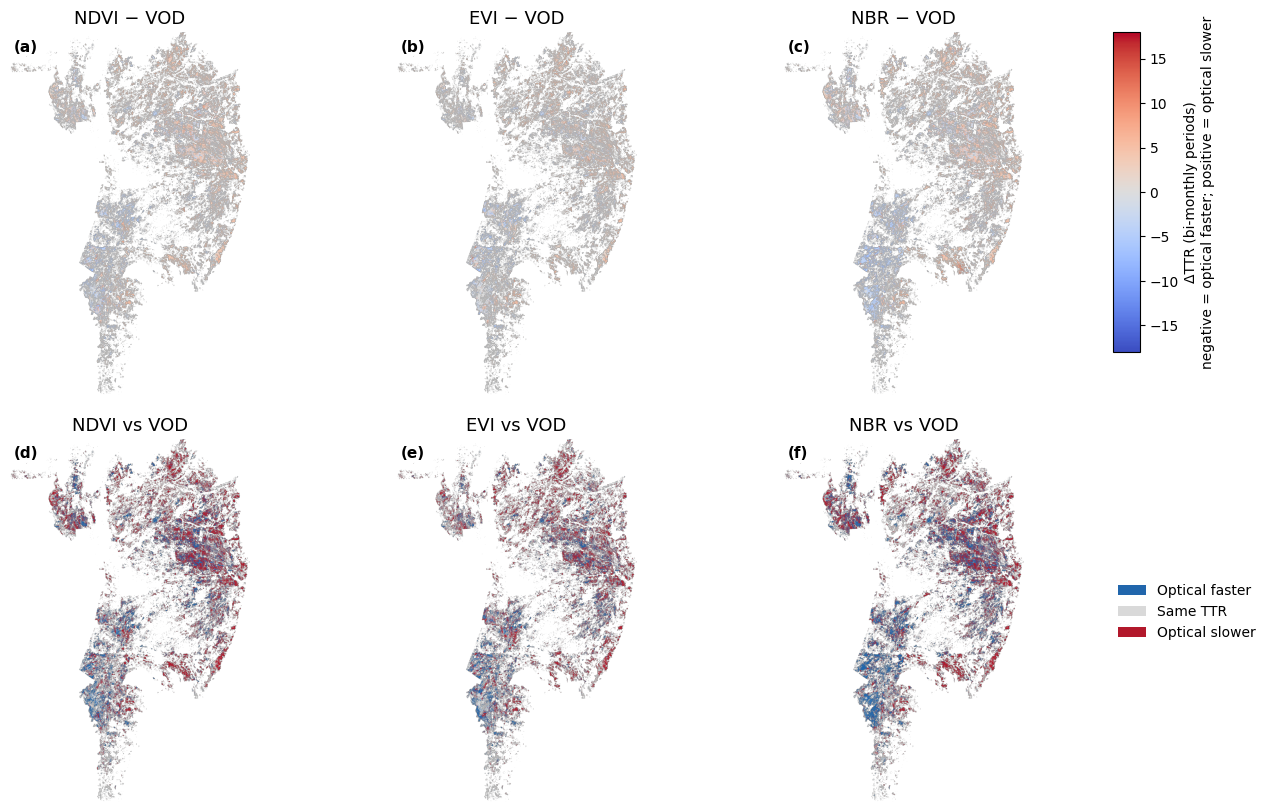

✔ Figura: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/compare_ttr_corrected/figures/TTR_optical_vs_VOD_corrected.png


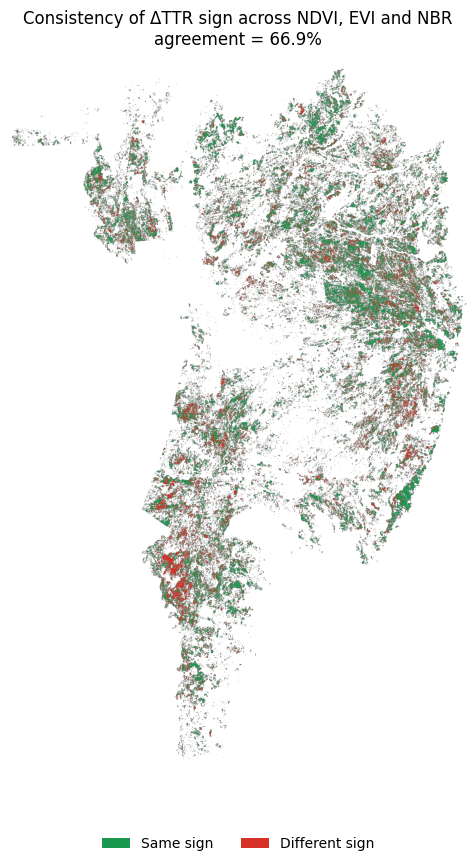


COMPARAÇÃO TTR OPTICAL × VOD CORRIGIDA FINALIZADA
✔ Summary: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/compare_ttr_corrected/tables/optical_vs_VOD_TTR_summary.csv
✔ Sign consistency: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/compare_ttr_corrected/tables/optical_TTR_sign_consistency.csv
✔ Figura Optical × VOD: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/compare_ttr_corrected/figures/TTR_optical_vs_VOD_corrected.png
✔ Figura sign consistency: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/compare_ttr_corrected/figures/TTR_optical_sign_consistency_corrected.png
✔ Rasters: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/compare_ttr_corrected/rasters


In [ ]:
# @title TTR-COMP — Optical × VOD com TTR corrigido

from pathlib import Path

import gc
import numpy as np
import pandas as pd
import rasterio as rio
import matplotlib.pyplot as plt

from rasterio.transform import array_bounds
from matplotlib.colors import ListedColormap, BoundaryNorm

# =========================================================
# CAMINHOS
# =========================================================

ROOT = Path(
    "/content/drive/MyDrive/Pantanal_TippingPoints"
).resolve()

REC_DIR = (
    ROOT /
    "index" /
    "outputs" /
    "recovery_nb3_corrected"
)

OUT_DIR = (
    ROOT /
    "index" /
    "outputs" /
    "compare_ttr_corrected"
)

RASTER_DIR = (
    OUT_DIR /
    "rasters"
)

TABLE_DIR = (
    OUT_DIR /
    "tables"
)

FIG_DIR = (
    OUT_DIR /
    "figures"
)

for d in [
    OUT_DIR,
    RASTER_DIR,
    TABLE_DIR,
    FIG_DIR
]:
    d.mkdir(
        parents=True,
        exist_ok=True
    )

# =========================================================
# CONFIGURAÇÃO
# =========================================================

OPTICAL = [
    "NDVI",
    "EVI",
    "NBR"
]

VOD = "VOD"

# status corrigido:
#
# 1 = recovered after detectable impact
# 2 = impact detected, threshold not reached
# 3 = insufficient post-fire data
# 4 = no detectable threshold-level impact
#
RECOVERED_STATUS = 1

NODATA_FLOAT = -32768.0
NODATA_CLASS = 255

# =========================================================
# HELPERS
# =========================================================

def ttr_fp(idx):

    return (
        REC_DIR /
        f"ttr_time_{idx}_bimestres.tif"
    )


def status_fp(idx):

    return (
        REC_DIR /
        f"ttr_status_{idx}.tif"
    )


def read_float(fp):

    assert fp.exists(), (
        f"Arquivo não encontrado: {fp}"
    )

    with rio.open(fp) as ds:

        a = ds.read(
            1
        ).astype(
            "float32"
        )

        profile = ds.profile.copy()
        transform = ds.transform
        crs = ds.crs

        nod = ds.nodata

    if nod is not None:

        try:

            if np.isfinite(nod):
                a[a == nod] = np.nan

        except Exception:
            pass

    a[
        ~np.isfinite(a)
    ] = np.nan

    return (
        a,
        profile,
        transform,
        crs
    )


def read_status(fp):

    assert fp.exists(), (
        f"Arquivo não encontrado: {fp}"
    )

    with rio.open(fp) as ds:

        a = ds.read(
            1
        ).astype(
            "uint8"
        )

        transform = ds.transform
        crs = ds.crs

    return (
        a,
        transform,
        crs
    )


def check_grid(
    transform,
    crs,
    ref_transform,
    ref_crs
):

    assert str(crs) == str(ref_crs)

    assert np.allclose(
        np.array(transform)[:6],
        np.array(ref_transform)[:6],
        atol=1e-6
    )


def save_float_raster(
    fp,
    arr,
    ref_profile
):

    out = np.where(
        np.isfinite(arr),
        arr,
        NODATA_FLOAT
    ).astype(
        "float32"
    )

    profile = (
        ref_profile.copy()
    )

    profile.update(
        dtype="float32",
        count=1,
        nodata=NODATA_FLOAT,
        compress="deflate"
    )

    tmp = fp.with_name(
        "tmp_" +
        fp.name
    )

    with rio.open(
        tmp,
        "w",
        **profile
    ) as ds:

        ds.write(
            out,
            1
        )

    tmp.replace(fp)


def save_class_raster(
    fp,
    arr,
    ref_profile
):

    profile = (
        ref_profile.copy()
    )

    profile.update(
        dtype="uint8",
        count=1,
        nodata=NODATA_CLASS,
        compress="deflate"
    )

    tmp = fp.with_name(
        "tmp_" +
        fp.name
    )

    with rio.open(
        tmp,
        "w",
        **profile
    ) as ds:

        ds.write(
            arr.astype(
                "uint8"
            ),
            1
        )

    tmp.replace(fp)


# =========================================================
# 1. VOD CORRIGIDO
# =========================================================

vod_ttr, ref_profile, REF_TF, REF_CRS = (
    read_float(
        ttr_fp(
            VOD
        )
    )
)

vod_status, tf, crs = (
    read_status(
        status_fp(
            VOD
        )
    )
)

check_grid(
    tf,
    crs,
    REF_TF,
    REF_CRS
)

H, W = (
    vod_ttr.shape
)

print(
    "✔ Grade:",
    H,
    "×",
    W,
    "|",
    REF_CRS
)

print(
    "✔ VOD status=1:",
    f"{np.sum(vod_status == 1):,}"
)

# =========================================================
# 2. COMPARAÇÃO OPTICAL × VOD
# =========================================================

summary_rows = []

# Guardar classes para sign consistency
class_maps = {}

# Para figura
delta_maps = {}

for idx in OPTICAL:

    print(
        "\n" +
        "="*65
    )

    print(
        idx,
        "× VOD"
    )

    print(
        "="*65
    )

    opt_ttr, _, tf, crs = (
        read_float(
            ttr_fp(
                idx
            )
        )
    )

    opt_status, tf_s, crs_s = (
        read_status(
            status_fp(
                idx
            )
        )
    )

    check_grid(
        tf,
        crs,
        REF_TF,
        REF_CRS
    )

    check_grid(
        tf_s,
        crs_s,
        REF_TF,
        REF_CRS
    )

    # =====================================================
    # PIXELS ESTRITAMENTE COMPARÁVEIS
    #
    # Ambos:
    # impacto detectável + recuperação observada
    # =====================================================

    valid = (
        (opt_status == RECOVERED_STATUS)
        &
        (vod_status == RECOVERED_STATUS)
        &
        np.isfinite(
            opt_ttr
        )
        &
        np.isfinite(
            vod_ttr
        )
    )

    n = int(
        valid.sum()
    )

    assert n > 0

    opt = opt_ttr[
        valid
    ].astype(
        "float64"
    )

    vod = vod_ttr[
        valid
    ].astype(
        "float64"
    )

    # =====================================================
    # DELTA TTR
    #
    # negativo = optical faster
    # zero     = same TTR
    # positivo = optical slower
    # =====================================================

    delta = (
        opt -
        vod
    )

    faster = (
        delta < 0
    )

    same = (
        delta == 0
    )

    slower = (
        delta > 0
    )

    # =====================================================
    # CORRELAÇÕES DESCRITIVAS
    # =====================================================

    if (
        np.nanstd(opt) > 0
        and
        np.nanstd(vod) > 0
    ):

        pearson = float(
            np.corrcoef(
                opt,
                vod
            )[0, 1]
        )

    else:

        pearson = np.nan

    spearman = float(
        pd.Series(opt)
        .corr(
            pd.Series(vod),
            method="spearman"
        )
    )

    # =====================================================
    # RESUMO
    # =====================================================

    q25, median, q75 = (
        np.percentile(
            delta,
            [25, 50, 75]
        )
    )

    summary_rows.append({

        "optical_index":
            idx,

        "n_comparable":
            n,

        "delta_ttr_mean":
            float(
                np.mean(delta)
            ),

        "delta_ttr_median":
            float(
                median
            ),

        "delta_ttr_q25":
            float(
                q25
            ),

        "delta_ttr_q75":
            float(
                q75
            ),

        "delta_ttr_min":
            float(
                np.min(delta)
            ),

        "delta_ttr_max":
            float(
                np.max(delta)
            ),

        "optical_faster_n":
            int(
                faster.sum()
            ),

        "optical_faster_pct":
            float(
                100 *
                faster.mean()
            ),

        "same_ttr_n":
            int(
                same.sum()
            ),

        "same_ttr_pct":
            float(
                100 *
                same.mean()
            ),

        "optical_slower_n":
            int(
                slower.sum()
            ),

        "optical_slower_pct":
            float(
                100 *
                slower.mean()
            ),

        "pearson_r":
            pearson,

        "spearman_rho":
            spearman
    })

    print(
        "Comparable pixels:",
        f"{n:,}"
    )

    print(
        "ΔTTR median:",
        f"{median:.2f}"
    )

    print(
        "Optical faster:",
        f"{100*faster.mean():.2f}%"
    )

    print(
        "Same TTR:",
        f"{100*same.mean():.2f}%"
    )

    print(
        "Optical slower:",
        f"{100*slower.mean():.2f}%"
    )

    print(
        "Pearson:",
        f"{pearson:.3f}"
    )

    print(
        "Spearman:",
        f"{spearman:.3f}"
    )

    # =====================================================
    # RASTER ΔTTR
    # =====================================================

    delta_map = np.full(
        (
            H,
            W
        ),
        np.nan,
        dtype="float32"
    )

    delta_map[
        valid
    ] = delta.astype(
        "float32"
    )

    DELTA_FP = (
        RASTER_DIR /
        f"delta_TTR_{idx}_minus_VOD.tif"
    )

    save_float_raster(
        DELTA_FP,
        delta_map,
        ref_profile
    )

    delta_maps[
        idx
    ] = delta_map

    # =====================================================
    # RASTER CLASSES
    #
    # 0 = optical faster
    # 1 = same TTR
    # 2 = optical slower
    # 255 = NoData
    # =====================================================

    cls = np.full(
        (
            H,
            W
        ),
        NODATA_CLASS,
        dtype="uint8"
    )

    cls[
        valid &
        (
            opt_ttr <
            vod_ttr
        )
    ] = 0

    cls[
        valid &
        (
            opt_ttr ==
            vod_ttr
        )
    ] = 1

    cls[
        valid &
        (
            opt_ttr >
            vod_ttr
        )
    ] = 2

    CLASS_FP = (
        RASTER_DIR /
        f"TTR_class_{idx}_vs_VOD.tif"
    )

    save_class_raster(
        CLASS_FP,
        cls,
        ref_profile
    )

    class_maps[
        idx
    ] = cls

    del (
        opt_ttr,
        opt_status,
        opt,
        vod,
        delta,
        valid
    )

    gc.collect()


# =========================================================
# 3. TABELA COMPARATIVA
# =========================================================

summary = pd.DataFrame(
    summary_rows
)

SUMMARY_FP = (
    TABLE_DIR /
    "optical_vs_VOD_TTR_summary.csv"
)

summary.to_csv(
    SUMMARY_FP,
    index=False
)

print(
    "\n=== SUMMARY ==="
)

display(
    summary
)

# =========================================================
# 4. SIGN-CONSISTENCY ENTRE NDVI/EVI/NBR
#
# Apenas pixels comparáveis nos TRÊS optical × VOD.
#
# Consistente =
# ΔTTR tem o mesmo sinal em NDVI, EVI e NBR:
#
# todos <0
# todos =0
# todos >0
# =========================================================

ndvi_cls = class_maps[
    "NDVI"
]

evi_cls = class_maps[
    "EVI"
]

nbr_cls = class_maps[
    "NBR"
]

all_valid = (
    (ndvi_cls != NODATA_CLASS)
    &
    (evi_cls != NODATA_CLASS)
    &
    (nbr_cls != NODATA_CLASS)
)

same_sign = (
    all_valid
    &
    (
        ndvi_cls ==
        evi_cls
    )
    &
    (
        evi_cls ==
        nbr_cls
    )
)

different_sign = (
    all_valid
    &
    ~same_sign
)

n_all = int(
    all_valid.sum()
)

n_agree = int(
    same_sign.sum()
)

n_diff = int(
    different_sign.sum()
)

agreement_pct = (
    100.0 *
    n_agree /
    n_all
    if n_all
    else np.nan
)

sign_summary = pd.DataFrame([{

    "pixels_comparable_all_three":
        n_all,

    "same_sign_n":
        n_agree,

    "same_sign_pct":
        agreement_pct,

    "different_sign_n":
        n_diff,

    "different_sign_pct":
        (
            100.0 *
            n_diff /
            n_all
            if n_all
            else np.nan
        )
}])

SIGN_TABLE_FP = (
    TABLE_DIR /
    "optical_TTR_sign_consistency.csv"
)

sign_summary.to_csv(
    SIGN_TABLE_FP,
    index=False
)

# =========================================================
# RASTER SIGN CONSISTENCY
#
# 0 = different
# 1 = same sign
# 255 = NoData
# =========================================================

sign_map = np.full(
    (
        H,
        W
    ),
    NODATA_CLASS,
    dtype="uint8"
)

sign_map[
    different_sign
] = 0

sign_map[
    same_sign
] = 1

SIGN_RASTER_FP = (
    RASTER_DIR /
    "TTR_sign_consistency_optical_vs_VOD.tif"
)

save_class_raster(
    SIGN_RASTER_FP,
    sign_map,
    ref_profile
)

print(
    "\n=== SIGN CONSISTENCY ==="
)

display(
    sign_summary
)

# =========================================================
# 5. FIGURA CORRIGIDA
#
# Linha 1 = ΔTTR
# Linha 2 = faster / same / slower
# Legendas à direita
# =========================================================

from matplotlib.patches import Patch

west, south, east, north = array_bounds(
    H,
    W,
    REF_TF
)

extent = [
    west,
    east,
    south,
    north
]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 10)
)

fig.subplots_adjust(
    right=0.88,
    wspace=0.08,
    hspace=0.12
)

MAX_ABS = 18

# =========================================================
# CORES DAS CLASSES
# =========================================================

cmap_cls = ListedColormap(
    [
        "#2166ac",  # optical faster
        "#d9d9d9",  # same
        "#b2182b"   # optical slower
    ]
)

norm_cls = BoundaryNorm(
    [
        -0.5,
        0.5,
        1.5,
        2.5
    ],
    cmap_cls.N
)

# =========================================================
# MAPAS
# =========================================================

for j, idx in enumerate(OPTICAL):

    # -----------------------------------------------------
    # ΔTTR
    # -----------------------------------------------------

    im = axes[0, j].imshow(
        delta_maps[idx],
        extent=extent,
        origin="upper",
        cmap="coolwarm",
        vmin=-MAX_ABS,
        vmax=MAX_ABS
    )

    axes[0, j].set_title(
        f"{idx} − VOD",
        fontsize=13
    )

    axes[0, j].set_axis_off()

    # -----------------------------------------------------
    # FASTER / SAME / SLOWER
    # -----------------------------------------------------

    masked_cls = np.ma.masked_where(
        class_maps[idx] == NODATA_CLASS,
        class_maps[idx]
    )

    axes[1, j].imshow(
        masked_cls,
        extent=extent,
        origin="upper",
        cmap=cmap_cls,
        norm=norm_cls
    )

    axes[1, j].set_title(
        f"{idx} vs VOD",
        fontsize=13
    )

    axes[1, j].set_axis_off()


# =========================================================
# COLORBAR ΔTTR À DIREITA — PARTE SUPERIOR
# =========================================================

cax1 = fig.add_axes(
    [
        0.90,   # left
        0.56,   # bottom
        0.018,  # width
        0.32    # height
    ]
)

cbar = fig.colorbar(
    im,
    cax=cax1
)

cbar.set_label(
    "ΔTTR (bi-monthly periods)\n"
    "negative = optical faster; positive = optical slower",
    fontsize=10
)

# =========================================================
# LEGENDA CATEGÓRICA À DIREITA — PARTE INFERIOR
# =========================================================

legend_elements = [

    Patch(
        facecolor="#2166ac",
        edgecolor="none",
        label="Optical faster"
    ),

    Patch(
        facecolor="#d9d9d9",
        edgecolor="none",
        label="Same TTR"
    ),

    Patch(
        facecolor="#b2182b",
        edgecolor="none",
        label="Optical slower"
    )
]

fig.legend(
    handles=legend_elements,
    loc="center left",
    bbox_to_anchor=(
        0.895,
        0.30
    ),
    frameon=False,
    fontsize=10
)

# =========================================================
# RÓTULOS DOS PAINÉIS
# =========================================================

panel_letters = [
    "(a)", "(b)", "(c)",
    "(d)", "(e)", "(f)"
]

k = 0

for r in range(2):

    for c in range(3):

        axes[r, c].text(
            0.015,
            0.98,
            panel_letters[k],
            transform=axes[r, c].transAxes,
            ha="left",
            va="top",
            fontsize=11,
            fontweight="bold"
        )

        k += 1

# =========================================================
# SALVAR
# =========================================================

FIG_FP = (
    FIG_DIR /
    "TTR_optical_vs_VOD_corrected.png"
)

fig.savefig(
    FIG_FP,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "✔ Figura:",
    FIG_FP
)

# =========================================================
# 6. FIGURA SIGN CONSISTENCY
# =========================================================

fig2, ax = plt.subplots(
    figsize=(
        7,
        9
    )
)

cmap_sign = ListedColormap(
    [
        "#d73027",
        "#1a9850"
    ]
)

norm_sign = BoundaryNorm(
    [
        -0.5,
        0.5,
        1.5
    ],
    cmap_sign.N
)

masked_sign = np.ma.masked_where(
    sign_map ==
    NODATA_CLASS,
    sign_map
)

ax.imshow(
    masked_sign,
    extent=extent,
    origin="upper",
    cmap=cmap_sign,
    norm=norm_sign
)

ax.set_title(
    "Consistency of ΔTTR sign across NDVI, EVI and NBR\n"
    f"agreement = {agreement_pct:.1f}%"
)

ax.set_axis_off()

fig2.legend(
    handles=[
        Patch(
            facecolor="#1a9850",
            label="Same sign"
        ),
        Patch(
            facecolor="#d73027",
            label="Different sign"
        )
    ],
    loc="lower center",
    ncol=2,
    frameon=False
)

SIGN_FIG_FP = (
    FIG_DIR /
    "TTR_optical_sign_consistency_corrected.png"
)

fig2.savefig(
    SIGN_FIG_FP,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =========================================================
# FINAL
# =========================================================

print(
    "\n" +
    "="*72
)

print(
    "COMPARAÇÃO TTR OPTICAL × VOD CORRIGIDA FINALIZADA"
)

print(
    "="*72
)

print(
    "✔ Summary:",
    SUMMARY_FP
)

print(
    "✔ Sign consistency:",
    SIGN_TABLE_FP
)

print(
    "✔ Figura Optical × VOD:",
    FIG_FP
)

print(
    "✔ Figura sign consistency:",
    SIGN_FIG_FP
)

print(
    "✔ Rasters:",
    RASTER_DIR
)

✔ REC_DIR encontrada: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/recovery_nb3_corrected
NDVI: 747,159 pixels com TTR válido
EVI: 706,760 pixels com TTR válido
NBR: 781,337 pixels com TTR válido
VOD: 565,359 pixels com TTR válido

=== SIGN CONSISTENCY ===
pixels comparable all three: 400,185
same sign               : 267,832 (66.93%)
different sign          : 132,353 (33.07%)

✔ Figura salva em: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/recovery_nb3_corrected/fig_cross_sensor_ttr_compact_aligned.png


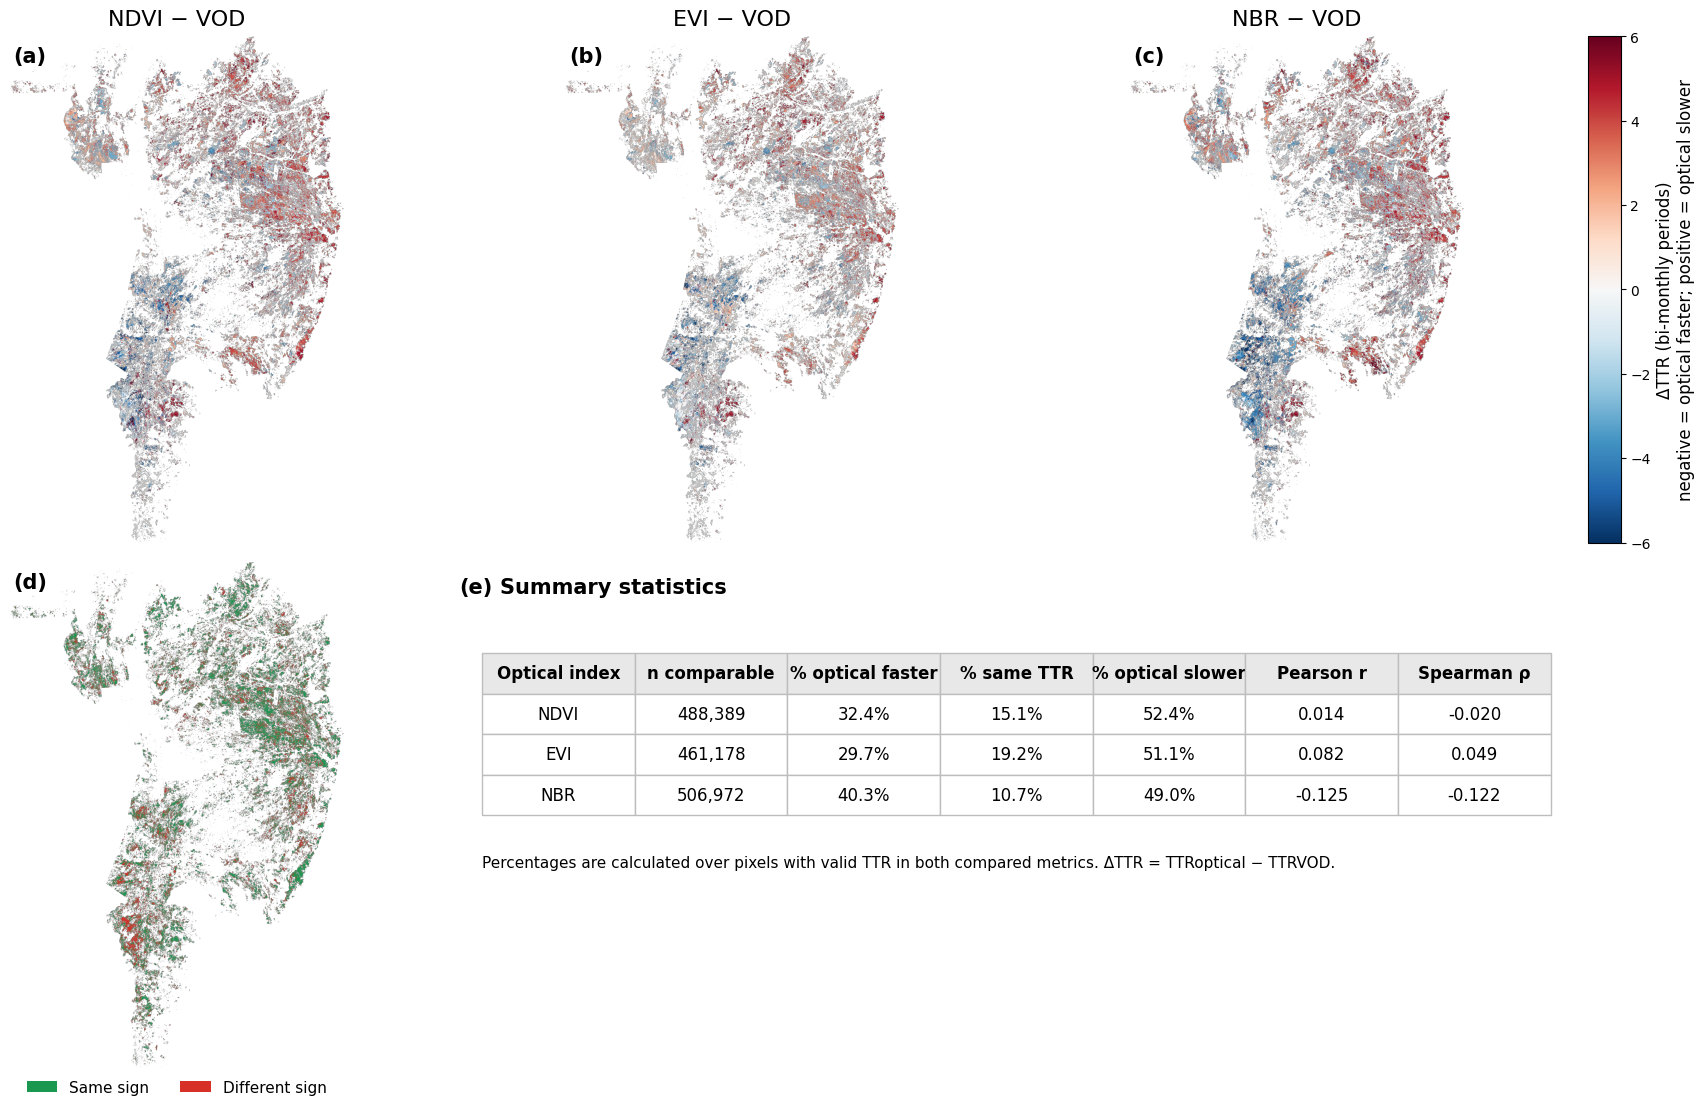

In [ ]:
# @title FIGURA — Comparação cross-sensor de TTR (ΔTTR + consistência + tabela-resumo) — versão ajustada

import numpy as np
import rasterio as rio
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import spearmanr
from matplotlib.colors import TwoSlopeNorm, ListedColormap
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch

# =========================================================
# PARÂMETROS DE VISUALIZAÇÃO
# =========================================================

# Quanto menor o percentil, maior o contraste visual
CONTRAST_PCTL = 95

# Paleta mais contrastante
CMAP_DELTA = "RdBu_r"

# =========================================================
# 1) LOCALIZAR AUTOMATICAMENTE A PASTA COM OS TTRs
# =========================================================

ROOT = Path("/content/drive/MyDrive/Pantanal_TippingPoints/index/outputs")

def find_ttr_dir(root):
    candidates = []
    for fp in root.rglob("ttr_time_NDVI_bimestres.tif"):
        d = fp.parent
        ok = all((d / f"ttr_time_{m}_bimestres.tif").exists() for m in ["NDVI","EVI","NBR","VOD"])
        if ok:
            candidates.append(d)
    if not candidates:
        raise FileNotFoundError("Não encontrei uma pasta com os 4 arquivos ttr_time_*_bimestres.tif.")
    candidates = sorted(
        candidates,
        key=lambda p: (
            "corrected" not in str(p).lower(),
            -p.stat().st_mtime
        )
    )
    return candidates[0]

REC_DIR = find_ttr_dir(ROOT)
print("✔ REC_DIR encontrada:", REC_DIR)

# =========================================================
# 2) LEITURA DOS RASTERS TTR
# =========================================================

METRICS = ["NDVI", "EVI", "NBR", "VOD"]

TTR = {}
profile_ref = None

for metric in METRICS:
    fp = REC_DIR / f"ttr_time_{metric}_bimestres.tif"
    assert fp.exists(), f"Arquivo não encontrado: {fp}"

    with rio.open(fp) as ds:
        arr = ds.read(1).astype("float32")
        nod = ds.nodata
        if profile_ref is None:
            profile_ref = ds.profile.copy()

    if nod is not None:
        try:
            if np.isfinite(nod):
                arr[arr == nod] = np.nan
        except Exception:
            pass

    arr[(~np.isfinite(arr)) | (arr < 1) | (arr > 18)] = np.nan
    TTR[metric] = arr

    print(f"{metric}: {np.isfinite(arr).sum():,} pixels com TTR válido")

# =========================================================
# 3) ΔTTR (óptico - VOD)
# =========================================================

delta_maps = {}
summary_rows = []

for opt in ["NDVI", "EVI", "NBR"]:
    A = TTR[opt]
    B = TTR["VOD"]

    m = np.isfinite(A) & np.isfinite(B)
    d = np.full(A.shape, np.nan, dtype="float32")
    d[m] = A[m] - B[m]
    delta_maps[opt] = d

    vals = d[m]
    n = vals.size

    optical_faster = np.sum(vals < 0)
    same_ttr       = np.sum(vals == 0)
    optical_slower = np.sum(vals > 0)

    pearson_r = np.corrcoef(A[m], B[m])[0, 1] if n > 2 else np.nan
    spearman_rho = spearmanr(A[m], B[m], nan_policy="omit").statistic if n > 2 else np.nan

    summary_rows.append([
        opt,
        n,
        optical_faster, 100 * optical_faster / n,
        same_ttr,       100 * same_ttr       / n,
        optical_slower, 100 * optical_slower / n,
        pearson_r,
        spearman_rho
    ])

# =========================================================
# 4) CONSISTÊNCIA DE SINAL ENTRE OS 3 ÓPTICOS
# =========================================================

d_ndvi = delta_maps["NDVI"]
d_evi  = delta_maps["EVI"]
d_nbr  = delta_maps["NBR"]

m_all = np.isfinite(d_ndvi) & np.isfinite(d_evi) & np.isfinite(d_nbr)

sgn_ndvi = np.sign(d_ndvi[m_all])
sgn_evi  = np.sign(d_evi[m_all])
sgn_nbr  = np.sign(d_nbr[m_all])

same_sign_bool = (sgn_ndvi == sgn_evi) & (sgn_evi == sgn_nbr)

sign_map = np.full(d_ndvi.shape, np.nan, dtype="float32")
sign_map[m_all] = np.where(same_sign_bool, 1.0, 0.0)

n_all = np.sum(m_all)
n_same = np.sum(same_sign_bool)
n_diff = n_all - n_same
pct_same = 100 * n_same / n_all if n_all else np.nan
pct_diff = 100 * n_diff / n_all if n_all else np.nan

print("\n=== SIGN CONSISTENCY ===")
print(f"pixels comparable all three: {n_all:,}")
print(f"same sign               : {n_same:,} ({pct_same:.2f}%)")
print(f"different sign          : {n_diff:,} ({pct_diff:.2f}%)")

# =========================================================
# 5) PREPARAR TABELA-RESUMO
# =========================================================

def fmt_pct(x):
    return f"{x:.1f}%"

def fmt_r(x):
    return f"{x:.3f}"

table_cols = [
    "Optical index",
    "n comparable",
    "% optical faster",
    "% same TTR",
    "% optical slower",
    "Pearson r",
    "Spearman ρ"
]

table_text = []
for row in summary_rows:
    opt, n, of_n, of_pct, st_n, st_pct, os_n, os_pct, pr, sr = row
    table_text.append([
        opt,
        f"{n:,}",
        fmt_pct(of_pct),
        fmt_pct(st_pct),
        fmt_pct(os_pct),
        fmt_r(pr),
        fmt_r(sr)
    ])

# =========================================================
# 6) ESCALA MAIS CONTRASTANTE PARA ΔTTR
# =========================================================

all_delta = np.concatenate([
    delta_maps["NDVI"][np.isfinite(delta_maps["NDVI"])],
    delta_maps["EVI"][np.isfinite(delta_maps["EVI"])],
    delta_maps["NBR"][np.isfinite(delta_maps["NBR"])]
])

vabs = np.nanpercentile(np.abs(all_delta), CONTRAST_PCTL)
vabs = max(1, float(vabs))

norm = TwoSlopeNorm(vmin=-vabs, vcenter=0, vmax=vabs)
cmap_delta = plt.get_cmap(CMAP_DELTA)

# =========================================================
# 7) FIGURA
# =========================================================

fig = plt.figure(figsize=(18, 11), constrained_layout=True)
gs = GridSpec(
    2, 4, figure=fig,
    width_ratios=[1, 1, 1, 0.06],
    height_ratios=[1, 1]
)

# ---- painéis a-c
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[0, 2])
cax  = fig.add_subplot(gs[0, 3])

axes_top = [ax_a, ax_b, ax_c]
titles = ["NDVI − VOD", "EVI − VOD", "NBR − VOD"]
letters = ["(a)", "(b)", "(c)"]

ims = []

for ax, opt, title, letter in zip(axes_top, ["NDVI","EVI","NBR"], titles, letters):
    im = ax.imshow(delta_maps[opt], cmap=cmap_delta, norm=norm)
    ims.append(im)
    ax.set_title(title, fontsize=16, pad=8)
    ax.axis("off")
    ax.text(
        0.01, 0.98, letter,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=15, fontweight="bold"
    )

cb = fig.colorbar(ims[-1], cax=cax)
cb.set_label(
    "ΔTTR (bi-monthly periods)\nnegative = optical faster; positive = optical slower",
    fontsize=12
)

# ---- painel d
ax_d = fig.add_subplot(gs[1, 0])
im_d = ax_d.imshow(
    sign_map,
    cmap=ListedColormap(["#d73027", "#1a9850"]),
    vmin=0, vmax=1
)
ax_d.axis("off")
ax_d.text(
    0.01, 0.98, "(d)",
    transform=ax_d.transAxes,
    ha="left", va="top",
    fontsize=15, fontweight="bold"
)
#ax_d.set_title(
 #   "Consistency of ΔTTR sign across NDVI, EVI and NBR\n"
  #  f"agreement = {pct_same:.1f}%",
   # fontsize=14,
    #pad=8
#)

legend_elems = [
    Patch(facecolor="#1a9850", edgecolor="none", label="Same sign"),
    Patch(facecolor="#d73027", edgecolor="none", label="Different sign")
]
ax_d.legend(
    handles=legend_elems,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=2,
    frameon=False,
    fontsize=11
)

# ---- painel e
ax_e = fig.add_subplot(gs[1, 1:4])
ax_e.axis("off")

# letra alinhada com o painel d
ax_e.text(
    0.00, 0.97, "(e)",
    transform=ax_e.transAxes,
    ha="left", va="top",
    fontsize=15, fontweight="bold"
)

ax_e.text(
    0.035, 0.97, "Summary statistics",
    transform=ax_e.transAxes,
    ha="left", va="top",
    fontsize=15, fontweight="bold"
)

tbl = ax_e.table(
    cellText=table_text,
    colLabels=table_cols,
    loc="upper left",
    cellLoc="center",
    colLoc="center",
    bbox=[0.02, 0.50, 0.92, 0.32]   # [x0, y0, largura, altura]
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.scale(1.05, 1.6)

for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#e8e8e8")
    cell.set_edgecolor("#bdbdbd")

note = (
    "Percentages are calculated over pixels with valid TTR in both compared metrics. "
    "ΔTTR = TTRoptical − TTRVOD."
)
ax_e.text(
    0.02, 0.42, note,
    transform=ax_e.transAxes,
    ha="left", va="top",
    fontsize=11
)

#fig.suptitle(
 #   "Cross-sensor comparison of post-fire recovery timing",
#    fontsize=18,
#    y=1.02
#)

# =========================================================
# 8) SALVAR
# =========================================================

OUT_FIG = REC_DIR / "fig_cross_sensor_ttr_compact_aligned.png"
fig.savefig(OUT_FIG, dpi=300, bbox_inches="tight")
print("\n✔ Figura salva em:", OUT_FIG)

plt.show()

✔ Grade: 2448 × 1612 | EPSG:31983
✔ Pixels queimados: 949,064
✔ Pixels com 18 períodos completos de acompanhamento: 813,055

✔ Eventos com RdNBR: 903,976
⚠ Datas sem raster RdNBR: 0

=== RdNBR QUARTILES — FULL FOLLOW-UP SAMPLE ===
Pixels elegíveis para os quartis: 767,967
Q25 = 0.2839
Q50 = 0.4720
Q75 = 0.6844

=== TAMANHO DAS CLASSES ===


,severity_quartile,n_pixels,pct_sample
0,1,191998,25.000814
1,2,192042,25.006543
2,3,191988,24.999512
3,4,191939,24.993131



VOD

NDVI

EVI

NBR

=== SUMMARY ===


,index,severity_quartile,n_fire_full_followup,n_evaluated,n_not_evaluable,n_recovered,n_not_reached,n_insufficient,n_no_detectable_impact,n_detectable_impact,detectable_impact_pct,n_recovery_evaluable_after_impact,recovered_by_18_pct,median_TTR_recovered
0,VOD,1,191998,177924,14074,115971,36,0,61917,116007,65.200310,116007,99.968967,5.0
1,VOD,2,192042,174379,17663,122315,18,0,52046,122333,70.153516,122333,99.985286,5.0
2,VOD,3,191988,176996,14992,125504,28,0,51464,125532,70.923637,125532,99.977695,4.0
3,VOD,4,191939,186447,5492,131917,58,0,54472,131975,70.784191,131975,99.956052,4.0
4,NDVI,1,191998,179593,12405,146338,596,104,32555,147038,81.872902,146934,99.594376,6.0
5,NDVI,2,192042,175120,16922,154116,509,16,20479,154641,88.305733,154625,99.670816,7.0
6,NDVI,3,191988,177745,14243,156195,571,98,20881,156864,88.252272,156766,99.635763,7.0
7,NDVI,4,191939,187400,4539,161879,767,275,24479,162921,86.937567,162646,99.528424,7.0
8,EVI,1,191998,179593,12405,139959,866,103,38665,140928,78.470764,140825,99.385052,6.0
9,EVI,2,192042,175120,16922,139642,503,15,34960,140160,80.036546,140145,99.641086,6.0


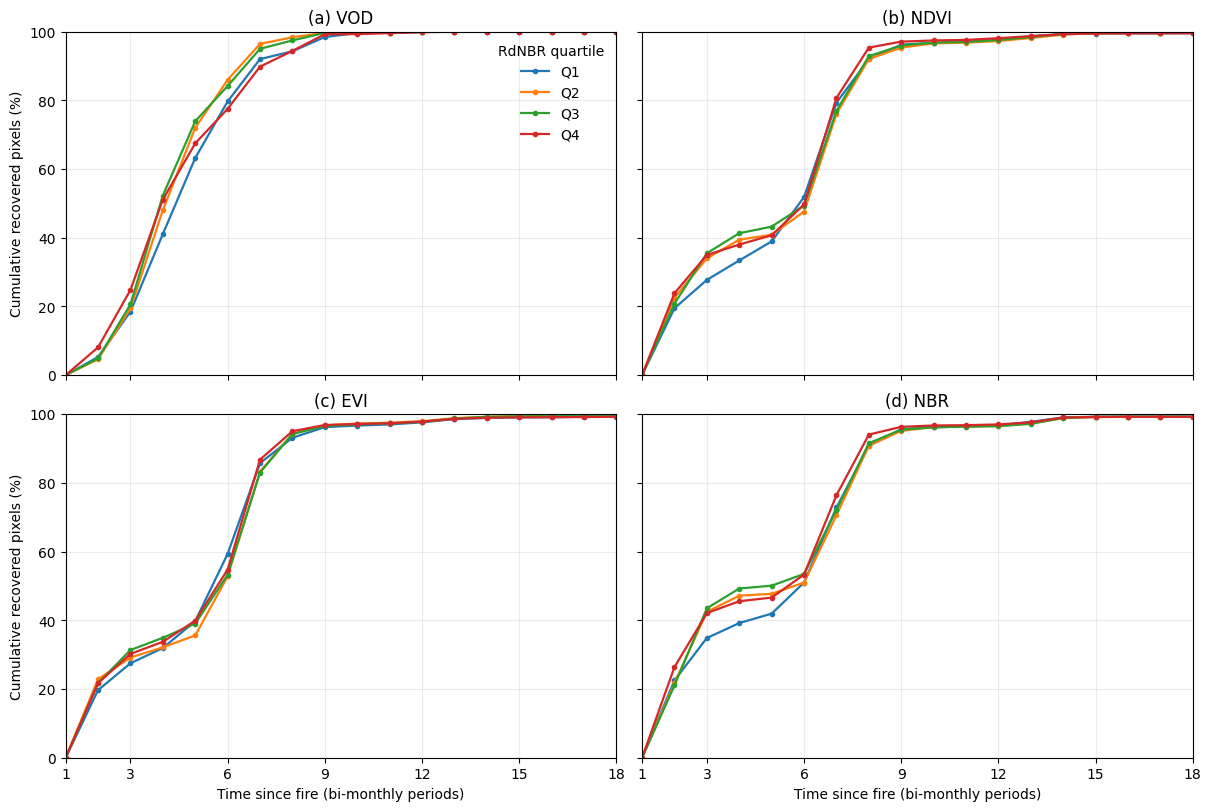


SEVERITY × TTR CORRIGIDO FINALIZADO
✔ RdNBR quartiles: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/compare_ttr_corrected/severity/tables/RdNBR_full_followup_quartiles.csv
✔ Curves: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/compare_ttr_corrected/severity/tables/severity_TTR_cumulative_curves_corrected.csv
✔ Summary: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/compare_ttr_corrected/severity/tables/severity_TTR_summary_corrected.csv
✔ Figure: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/compare_ttr_corrected/severity/figures/severity_TTR_cumulative_corrected.png
✔ RdNBR first-fire raster: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/compare_ttr_corrected/severity/rasters/RdNBR_first_fire_corrected.tif


In [ ]:
# @title TTR-SEVERITY — Severidade RdNBR × TTR corrigido

from pathlib import Path

import gc
import numpy as np
import pandas as pd
import rasterio as rio
import matplotlib.pyplot as plt

from rasterio.warp import reproject, Resampling

# =========================================================
# CAMINHOS
# =========================================================

ROOT = Path(
    "/content/drive/MyDrive/Pantanal_TippingPoints"
).resolve()

OUT_DIR = (
    ROOT /
    "index" /
    "outputs"
)

REC_DIR = (
    OUT_DIR /
    "recovery_nb3_corrected"
)

# RdNBR contínuo por período
RDNBR_DIR = (
    OUT_DIR /
    "fase1_events_300m"
)

RESULT_DIR = (
    OUT_DIR /
    "compare_ttr_corrected" /
    "severity"
)

TABLE_DIR = (
    RESULT_DIR /
    "tables"
)

FIG_DIR = (
    RESULT_DIR /
    "figures"
)

RASTER_DIR = (
    RESULT_DIR /
    "rasters"
)

for d in [
    RESULT_DIR,
    TABLE_DIR,
    FIG_DIR,
    RASTER_DIR
]:
    d.mkdir(
        parents=True,
        exist_ok=True
    )

# =========================================================
# CONFIGURAÇÃO
# =========================================================

METRICS = [
    "VOD",
    "NDVI",
    "EVI",
    "NBR"
]

# Para acompanhar 18 períodos completos:
# 2018-11 + 18 bimestres = 2021-11
LAST_FULL_FOLLOWUP_FIRE = 201811

MAX_TTR = 18

# status corrigidos
STATUS_RECOVERED = 1
STATUS_NOT_REACHED = 2
STATUS_INSUFFICIENT = 3
STATUS_NO_IMPACT = 4

# =========================================================
# ARQUIVOS DE REFERÊNCIA
# =========================================================

FIRST_FIRE_FP = (
    REC_DIR /
    "first_fire_yyyymm.tif"
)

assert FIRST_FIRE_FP.exists(), (
    f"Não encontrei: {FIRST_FIRE_FP}"
)

assert RDNBR_DIR.exists(), (
    f"Não encontrei a pasta de RdNBR: {RDNBR_DIR}"
)

# =========================================================
# GRADE DE REFERÊNCIA
# =========================================================

with rio.open(
    FIRST_FIRE_FP
) as ds:

    fire_ym = ds.read(
        1
    ).astype(
        "int32"
    )

    FIRE_NODATA = ds.nodata

    H = ds.height
    W = ds.width

    REF_TF = ds.transform
    REF_CRS = ds.crs

    REF_PROFILE = ds.profile.copy()

if FIRE_NODATA is not None:

    fire_ym[
        fire_ym ==
        FIRE_NODATA
    ] = -9999

burned = (
    fire_ym > 0
)

full_followup = (
    burned
    &
    (
        fire_ym <=
        LAST_FULL_FOLLOWUP_FIRE
    )
)

print(
    "✔ Grade:",
    H,
    "×",
    W,
    "|",
    REF_CRS
)

print(
    "✔ Pixels queimados:",
    f"{burned.sum():,}"
)

print(
    "✔ Pixels com 18 períodos completos de acompanhamento:",
    f"{full_followup.sum():,}"
)

# =========================================================
# LEITURA DE RASTER ALINHADO
# =========================================================

def read_aligned_float(fp):

    assert fp.exists(), (
        f"Arquivo ausente: {fp}"
    )

    with rio.open(fp) as src:

        a = src.read(
            1
        ).astype(
            "float32"
        )

        nod = src.nodata

        if nod is not None:

            try:

                if np.isfinite(nod):
                    a[a == nod] = np.nan

            except Exception:
                pass

        same_grid = (
            src.height == H
            and
            src.width == W
            and
            str(src.crs) == str(REF_CRS)
            and
            np.allclose(
                np.array(src.transform)[:6],
                np.array(REF_TF)[:6],
                atol=1e-6
            )
        )

        if same_grid:

            a[
                ~np.isfinite(a)
            ] = np.nan

            return a

        dst = np.full(
            (H, W),
            np.nan,
            dtype="float32"
        )

        reproject(
            source=a,
            destination=dst,

            src_transform=
                src.transform,

            src_crs=
                src.crs,

            dst_transform=
                REF_TF,

            dst_crs=
                REF_CRS,

            src_nodata=
                nod,

            dst_nodata=
                np.nan,

            # RdNBR é contínuo
            resampling=
                Resampling.bilinear
        )

        return dst


def read_status(fp):

    assert fp.exists()

    with rio.open(fp) as ds:

        assert ds.height == H
        assert ds.width == W

        return ds.read(
            1
        ).astype(
            "uint8"
        )


# =========================================================
# 1. RdNBR NO PRIMEIRO EVENTO CORRIGIDO
#
# Não precisamos reconstruir o evento com MapBiomas:
# first_fire_yyyymm já contém o primeiro evento confirmado.
# =========================================================

R_evt = np.full(
    (H, W),
    np.nan,
    dtype="float32"
)

event_yms = np.unique(
    fire_ym[
        fire_ym > 0
    ]
)

missing_rdnbr = []

for ym_int in event_yms:

    ym = str(
        int(ym_int)
    )

    fp = (
        RDNBR_DIR /
        f"rdnbr_{ym}.tif"
    )

    if not fp.exists():

        missing_rdnbr.append(
            ym
        )

        continue

    rdn = read_aligned_float(
        fp
    )

    m = (
        fire_ym ==
        int(ym)
    )

    R_evt[
        m
    ] = rdn[
        m
    ]

    del rdn
    gc.collect()

print(
    "\n✔ Eventos com RdNBR:",
    f"{np.isfinite(R_evt).sum():,}"
)

print(
    "⚠ Datas sem raster RdNBR:",
    len(missing_rdnbr)
)

if missing_rdnbr:

    print(
        missing_rdnbr[:20]
    )

# =========================================================
# SALVAR RdNBR DO PRIMEIRO EVENTO
# =========================================================

RDNBR_EVENT_FP = (
    RASTER_DIR /
    "RdNBR_first_fire_corrected.tif"
)

prof = REF_PROFILE.copy()

prof.update(
    dtype="float32",
    count=1,
    nodata=np.nan,
    compress="deflate"
)

with rio.open(
    RDNBR_EVENT_FP,
    "w",
    **prof
) as ds:

    ds.write(
        R_evt,
        1
    )

# =========================================================
# 2. QUARTIS DE SEVERIDADE NA POPULAÇÃO ANALÍTICA
#
# Universo usado para definir Q1–Q4:
#
# - primeiro fogo confirmado
# - RdNBR válido no evento
# - 18 períodos bimestrais completos de acompanhamento
#
# Assim, os quartis são definidos exatamente sobre a
# população utilizada nas curvas de recuperação.
# =========================================================

severity_base = (
    full_followup
    &
    np.isfinite(
        R_evt
    )
)

sev_values = R_evt[
    severity_base
]

assert sev_values.size > 0

# =========================================================
# QUARTIS
# =========================================================

q25, q50, q75 = np.percentile(
    sev_values,
    [25, 50, 75]
)

print(
    "\n=== RdNBR QUARTILES — FULL FOLLOW-UP SAMPLE ==="
)

print(
    "Pixels elegíveis para os quartis:",
    f"{sev_values.size:,}"
)

print(
    f"Q25 = {q25:.4f}"
)

print(
    f"Q50 = {q50:.4f}"
)

print(
    f"Q75 = {q75:.4f}"
)

# =========================================================
# CLASSES DE SEVERIDADE
#
# 1 = Q1  ≤ Q25
# 2 = Q2  >Q25 e ≤Q50
# 3 = Q3  >Q50 e ≤Q75
# 4 = Q4  >Q75
#
# Pixels fora da população analítica permanecem 0.
# =========================================================

sev_class = np.zeros(
    (H, W),
    dtype="uint8"
)

sev_class[
    severity_base
    &
    (
        R_evt <= q25
    )
] = 1

sev_class[
    severity_base
    &
    (
        R_evt > q25
    )
    &
    (
        R_evt <= q50
    )
] = 2

sev_class[
    severity_base
    &
    (
        R_evt > q50
    )
    &
    (
        R_evt <= q75
    )
] = 3

sev_class[
    severity_base
    &
    (
        R_evt > q75
    )
] = 4

# =========================================================
# QC — TAMANHO DAS QUATRO CLASSES
# =========================================================

quartile_counts = []

for q in [1, 2, 3, 4]:

    n_q = int(
        (
            sev_class == q
        ).sum()
    )

    quartile_counts.append(
        {
            "severity_quartile":
                q,

            "n_pixels":
                n_q,

            "pct_sample":
                (
                    100.0 *
                    n_q /
                    sev_values.size
                )
        }
    )

quartile_counts_df = pd.DataFrame(
    quartile_counts
)

print(
    "\n=== TAMANHO DAS CLASSES ==="
)

display(
    quartile_counts_df
)

# =========================================================
# SALVAR LIMITES + QC
# =========================================================

QUARTILE_FP = (
    TABLE_DIR /
    "RdNBR_full_followup_quartiles.csv"
)

pd.DataFrame([{

    "n_valid_first_fire_RdNBR_full_followup":
        int(
            sev_values.size
        ),

    "Q25":
        float(q25),

    "Q50":
        float(q50),

    "Q75":
        float(q75)

}]).to_csv(
    QUARTILE_FP,
    index=False
)

QUARTILE_COUNTS_FP = (
    TABLE_DIR /
    "RdNBR_full_followup_quartile_counts.csv"
)

quartile_counts_df.to_csv(
    QUARTILE_COUNTS_FP,
    index=False
)

# =========================================================
# 3. CURVAS DE RECUPERAÇÃO
#
# Denominador:
# status 1 + status 2
#
# somente:
# - RdNBR válido
# - 18 períodos completos de follow-up
#
# Isso evita tratar censura temporal como não recuperação.
# =========================================================

curve_rows = []
summary_rows = []

for metric in METRICS:

    print(
        "\n" +
        "="*68
    )

    print(
        metric
    )

    print(
        "="*68
    )

    TTR_FP = (
        REC_DIR /
        f"ttr_time_{metric}_bimestres.tif"
    )

    STATUS_FP = (
        REC_DIR /
        f"ttr_status_{metric}.tif"
    )

    assert TTR_FP.exists(), (
        TTR_FP
    )

    assert STATUS_FP.exists(), (
        STATUS_FP
    )

    ttr = read_aligned_float(
        TTR_FP
    )

    status = read_status(
        STATUS_FP
    )

    # universo para QC:
    # fogo + severidade + follow-up completo
    base_metric = (
        full_followup
        &
        (
            sev_class > 0
        )
    )

    for q in [
        1,
        2,
        3,
        4
    ]:

        m_q = (
            base_metric
            &
            (
                sev_class == q
            )
        )

        n_all = int(
            m_q.sum()
        )

        n_recovered = int(
            (
                m_q
                &
                (
                    status ==
                    STATUS_RECOVERED
                )
            ).sum()
        )

        n_not_reached = int(
            (
                m_q
                &
                (
                    status ==
                    STATUS_NOT_REACHED
                )
            ).sum()
        )

        n_insufficient = int(
            (
                m_q
                &
                (
                    status ==
                    STATUS_INSUFFICIENT
                )
            ).sum()
        )

        n_no_impact = int(
            (
                m_q
                &
                (
                    status ==
                    STATUS_NO_IMPACT
                )
            ).sum()
        )

        # ---------------------------------------------
        # Curva é condicional a IMPACTO DETECTÁVEL
        # ---------------------------------------------

        eligible = (
            m_q
            &
            (
                (
                    status ==
                    STATUS_RECOVERED
                )
                |
                (
                    status ==
                    STATUS_NOT_REACHED
                )
            )
        )

        denom = int(
            eligible.sum()
        )

        ttr_recovered = ttr[
            eligible
            &
            (
                status ==
                STATUS_RECOVERED
            )
            &
            np.isfinite(
                ttr
            )
        ]

        # ---------------------------------------------
        # CUMULATIVE RECOVERY
        # ---------------------------------------------

        for tt in range(
            1,
            MAX_TTR + 1
        ):

            if denom > 0:

                recovered_by_t = int(
                    (
                        eligible
                        &
                        (
                            status ==
                            STATUS_RECOVERED
                        )
                        &
                        np.isfinite(
                            ttr
                        )
                        &
                        (
                            ttr <= tt
                        )
                    ).sum()
                )

                pct = (
                    100.0 *
                    recovered_by_t /
                    denom
                )

            else:

                recovered_by_t = 0
                pct = np.nan

            curve_rows.append({

                "index":
                    metric,

                "severity_quartile":
                    q,

                "t_bimonths":
                    tt,

                "n_detectable_impact":
                    denom,

                "recovered_by_t":
                    recovered_by_t,

                "recovered_pct":
                    pct
            })

        # ---------------------------------------------
        # RESUMO POR CLASSE
        # ---------------------------------------------

       # ---------------------------------------------
        # RESUMO POR CLASSE
        # ---------------------------------------------

        # Impacto detectável:
        # status 1 = recuperado após impacto
        # status 2 = limiar não atingido
        # status 3 = dados insuficientes após impacto detectável
        n_detectable_impact_all = (
            n_recovered
            +
            n_not_reached
            +
            n_insufficient
        )

        # População efetivamente avaliável quanto à presença
        # ou ausência de impacto detectável.
        # Status 0 fica fora deste denominador.
        n_evaluated = (
            n_detectable_impact_all
            +
            n_no_impact
        )

        n_not_evaluable = (
            n_all
            -
            n_evaluated
        )

        summary_rows.append({

            "index":
                metric,

            "severity_quartile":
                q,

            "n_fire_full_followup":
                n_all,

            "n_evaluated":
                n_evaluated,

            "n_not_evaluable":
                n_not_evaluable,

            "n_recovered":
                n_recovered,

            "n_not_reached":
                n_not_reached,

            "n_insufficient":
                n_insufficient,

            "n_no_detectable_impact":
                n_no_impact,

            # Todos os pixels nos quais foi detectado impacto:
            # status 1 + 2 + 3
            "n_detectable_impact":
                n_detectable_impact_all,

            "detectable_impact_pct":
                (
                    100.0 *
                    n_detectable_impact_all /
                    n_evaluated
                    if n_evaluated
                    else np.nan
                ),

            # Para recuperação, o denominador continua sendo
            # status 1 + status 2 (= denom), pois status 3
            # não permite avaliar se houve recuperação.
            "n_recovery_evaluable_after_impact":
                denom,

            "recovered_by_18_pct":
                (
                    100.0 *
                    n_recovered /
                    denom
                    if denom
                    else np.nan
                ),

            "median_TTR_recovered":
                (
                    float(
                        np.median(
                            ttr_recovered
                        )
                    )
                    if ttr_recovered.size
                    else np.nan
                )
        })
# =========================================================
# TABELAS
# =========================================================

curves = pd.DataFrame(
    curve_rows
)

summary = pd.DataFrame(
    summary_rows
)

CURVE_FP = (
    TABLE_DIR /
    "severity_TTR_cumulative_curves_corrected.csv"
)

SUMMARY_FP = (
    TABLE_DIR /
    "severity_TTR_summary_corrected.csv"
)

curves.to_csv(
    CURVE_FP,
    index=False
)

summary.to_csv(
    SUMMARY_FP,
    index=False
)

print(
    "\n=== SUMMARY ==="
)

display(
    summary
)

# =========================================================
# 4. FIGURA 2×2
# =========================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(
        12,
        8
    ),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

axes = axes.ravel()

panel_letters = {
    "VOD": "(a)",
    "NDVI": "(b)",
    "EVI": "(c)",
    "NBR": "(d)"
}

for ax, metric in zip(
    axes,
    METRICS
):

    sub = curves[
        curves[
            "index"
        ] == metric
    ]

    for q in [
        1,
        2,
        3,
        4
    ]:

        sq = (
            sub[
                sub[
                    "severity_quartile"
                ] == q
            ]
            .sort_values(
                "t_bimonths"
            )
        )

        ax.plot(
            sq[
                "t_bimonths"
            ],
            sq[
                "recovered_pct"
            ],
            marker="o",
            markersize=3,
            linewidth=1.6,
            label=f"Q{q}"
        )

    ax.set_title(
        f"{panel_letters[metric]} {metric}"
    )

    ax.set_xlim(
        1,
        18
    )

    ax.set_ylim(
        0,
        100
    )

    ax.set_xticks(
        [
            1,
            3,
            6,
            9,
            12,
            15,
            18
        ]
    )

    ax.grid(
        alpha=0.25
    )

axes[0].set_ylabel(
    "Cumulative recovered pixels (%)"
)

axes[2].set_ylabel(
    "Cumulative recovered pixels (%)"
)

axes[2].set_xlabel(
    "Time since fire (bi-monthly periods)"
)

axes[3].set_xlabel(
    "Time since fire (bi-monthly periods)"
)

axes[0].legend(
    title="RdNBR quartile",
    frameon=False
)

FIG_FP = (
    FIG_DIR /
    "severity_TTR_cumulative_corrected.png"
)

fig.savefig(
    FIG_FP,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =========================================================
# FINAL
# =========================================================

print(
    "\n" +
    "="*72
)

print(
    "SEVERITY × TTR CORRIGIDO FINALIZADO"
)

print(
    "="*72
)

print(
    "✔ RdNBR quartiles:",
    QUARTILE_FP
)

print(
    "✔ Curves:",
    CURVE_FP
)

print(
    "✔ Summary:",
    SUMMARY_FP
)

print(
    "✔ Figure:",
    FIG_FP
)

print(
    "✔ RdNBR first-fire raster:",
    RDNBR_EVENT_FP
)